# Publication v4.2: reproducible comparative genomics of three focal lactobacilli

This GitHub-ready notebook regenerates the comparative-genomics tables and
publication figures for Vahe (*L. rhamnosus*), IAHAHI
(*L. delbrueckii* subsp. *bulgaricus*), and ZPZ (*L. plantarum*).

Only the three focal FASTA files are local biological inputs. By default the
notebook expects them in a `genomes/` directory beside the notebook. Set the
environment variable `PAPER1_PROJECT_ROOT` when launching Jupyter if the
notebook is opened from a different working directory.

The pipeline:

1. downloads the fixed, versioned cohort of 30 RefSeq assemblies per species;
2. applies one uniform Prokka annotation path to all 93 genomes;
3. records SHA-256 provenance and performs assembly/CheckM2 QC;
4. computes focal-vs-reference ANI and IAHAHI subspecies ANI;
5. builds cohort-bound Panaroo pangenomes and permutation rarefaction;
6. evaluates evidence-aware oxidative-defence and DNA-repair modules;
7. runs resumable all-genome dN/dS and compositional screens;
8. exports manuscript tables and editable PDF/SVG plus 600-dpi PNG figures;
9. finishes with an automated output and publication audit.

Expensive stages are input-bound and checkpointed. After an interruption,
restart the kernel and choose **Restart & Run All**; compatible completed work
is reused. Never run two copies against the same output directory.

> Genomic detection is not experimental proof of phenotype. `NE` means
> unresolved/not evaluable and is never converted into absence.

Publication v4.2 adds strict codon-alignment validation, restricts the primary dN/dS interpretation to DNA-repair genes, restores a reproducible IAHAHI Rex split-locus analysis, reports dS diagnostics for the curated families, and keeps the supplementary index non-blocking so the final audit remains visible, and adds a separate within-species oxidative-defence dN/dS analysis without forcing absent genes into the three-species comparison.


In [1]:
# ========================= USER CONFIGURATION =========================
# Put this notebook in the project root with the three FASTA files under
# project_root/genomes/. Alternatively, export PAPER1_PROJECT_ROOT first.

import os
from pathlib import Path
import matplotlib as mpl

PROJECT_ROOT = Path(
    os.environ.get("PAPER1_PROJECT_ROOT", Path.cwd())
).expanduser().resolve()
GENOMES_DIR = PROJECT_ROOT / "genomes"

FOCAL_FASTA = {
    "L. rhamnosus": GENOMES_DIR / "Vahe_VRTQ01.fasta",
    "L. delbrueckii": GENOMES_DIR / "IAHAHI_VRTP01.fasta",
    "L. plantarum": GENOMES_DIR / "ZPZ_VRTR01.fasta",
}

# Outputs are written beside the notebook, under paper1_results/.
PROJECT_DIR = PROJECT_ROOT / "paper1_results"

THREADS = 8
PROKKA_THREADS = 2
PANAROO_THREADS = 4

SHOW_DIAGNOSTICS = False

mpl.rcParams.update({
    "savefig.dpi": 600,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})



## Execution contract

- Required command-line tools: NCBI `datasets`, Prokka, Panaroo, CheckM2,
  fastANI, BLAST+, MAFFT, and FastTree.
- Tools are resolved from the active `PATH` first. Compatible micromamba
  environments are an optional fallback, not a requirement.
- The repository's Docker configuration is the recommended reproducible route
  on macOS (including Apple Silicon) and Linux.
- Native execution requires a configured CheckM2 database; the supplied Docker
  startup downloads and persists it automatically on first use.
- Internet is needed only for the first download of pinned NCBI assemblies and
  reviewed UniProt query proteins.
- Never run two copies against the same `PROJECT_DIR` simultaneously.

The first clean run can take several hours. Prokka, CheckM2, Panaroo, panel
searches, ANI, and dN/dS all leave reusable checkpoints.


In [2]:

import csv
import glob
import hashlib
import os
import re
import shutil
import subprocess
import tempfile
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

RANDOM_SEED = 20260723
N_PERMUTATIONS = 200
N_BOOTSTRAPS = 2000
FORCE_DOWNLOAD = False
FORCE_PROKKA = False
FORCE_PANEL = False
FORCE_ANI = False
FORCE_DNDS = False
FORCE_PANAROO = False
FORCE_CHECKM2 = False

TAG = {
    "L. rhamnosus": "L_rhamnosus",
    "L. delbrueckii": "L_delbrueckii",
    "L. plantarum": "L_plantarum",
}
FOCAL = {
    "L. rhamnosus": "Vahe",
    "L. delbrueckii": "IAHAHI",
    "L. plantarum": "ZPZ",
}
SPECIES_COLOUR = {
    "L. rhamnosus": "#BC3C29",
    "L. delbrueckii": "#0072B5",
    "L. plantarum": "#E18727",
}
STRAIN_COLOUR = {
    FOCAL[species]: colour
    for species, colour in SPECIES_COLOUR.items()
}

# Immutable 30-reference cohorts recovered from the validated 93-genome run.
REFERENCE_ACCESSIONS = {
    "L. rhamnosus": [
        "GCF_000743075.1", "GCF_000801045.1", "GCF_000814485.1",
        "GCF_000932035.1", "GCF_001005625.1", "GCF_001044025.1",
        "GCF_001044415.1", "GCF_001062885.1", "GCF_001062955.1",
        "GCF_001063655.1", "GCF_001064515.1", "GCF_001064785.1",
        "GCF_001065365.1", "GCF_001066715.1", "GCF_001066975.1",
        "GCF_001067025.1", "GCF_001067215.1", "GCF_001067335.1",
        "GCF_001067625.1", "GCF_001067885.1", "GCF_001068015.1",
        "GCF_001068045.1", "GCF_001068195.1", "GCF_001068215.1",
        "GCF_001368735.1", "GCF_001590655.1", "GCF_001645615.1",
        "GCF_001656535.1", "GCF_001656545.1", "GCF_900636965.1",
    ],
    "L. delbrueckii": [
        "GCF_000056065.1", "GCF_002847905.1", "GCF_003545935.1",
        "GCF_004211505.1", "GCF_004211735.1", "GCF_009362855.1",
        "GCF_009734125.1", "GCF_014830125.1", "GCF_015377785.1",
        "GCF_019583415.1", "GCF_021600185.1", "GCF_021600205.1",
        "GCF_021600245.1", "GCF_021600265.1", "GCF_021600345.1",
        "GCF_021600365.1", "GCF_021600385.1", "GCF_021600405.1",
        "GCF_021600425.1", "GCF_021600445.1", "GCF_021600465.1",
        "GCF_021600485.1", "GCF_021600505.1", "GCF_021600525.1",
        "GCF_021600545.1", "GCF_021600565.1", "GCF_021600585.1",
        "GCF_021600605.1", "GCF_021600625.1", "GCF_021600645.1",
    ],
    "L. plantarum": [
        "GCF_000687495.1", "GCF_000731855.1", "GCF_000743895.1",
        "GCF_000764285.1", "GCF_000931425.2", "GCF_000956195.1",
        "GCF_000966475.1", "GCF_001005695.1", "GCF_001005805.1",
        "GCF_001010175.1", "GCF_001267905.1", "GCF_001278015.1",
        "GCF_001296095.1", "GCF_001302645.1", "GCF_001308305.1",
        "GCF_001331925.2", "GCF_001368775.1", "GCF_001436855.1",
        "GCF_001444495.1", "GCF_001484005.1", "GCF_001540925.1",
        "GCF_001540965.1", "GCF_001581895.1", "GCF_001595615.1",
        "GCF_001596095.1", "GCF_001596195.1", "GCF_001597605.1",
        "GCF_001617525.2", "GCF_001619265.1", "GCF_009913655.1",
    ],
}
SUBSPECIES_ACCESSIONS = ["GCF_002285775.1", "GCF_006740305.1"]

if set(FOCAL_FASTA) != set(TAG):
    raise ValueError("FOCAL_FASTA must contain exactly the three configured species.")
FOCAL_FASTA = {
    species: Path(path).expanduser().resolve()
    for species, path in FOCAL_FASTA.items()
}
missing_focal = [
    f"{species}: {path}"
    for species, path in FOCAL_FASTA.items()
    if not path.is_file() or path.stat().st_size == 0
]
if missing_focal:
    raise FileNotFoundError(
        "Set the three focal FASTA paths in the first code cell:\n"
        + "\n".join(missing_focal)
    )
if any(len(values) != 30 or len(set(values)) != 30
       for values in REFERENCE_ACCESSIONS.values()):
    raise RuntimeError("The embedded fixed cohort is not 30 unique references per species.")

BASE = Path(PROJECT_DIR).expanduser().resolve()
WORK = BASE / "background_work"
OUT = BASE / "paper1_publication_final"
FIGDIR = OUT / "figures"
RAW_ROOT = WORK / "raw_genomes"
SUBSPECIES_REFERENCE_DIR = WORK / "subspecies_references"
for directory in (BASE, WORK, OUT, FIGDIR, RAW_ROOT, SUBSPECIES_REFERENCE_DIR):
    directory.mkdir(parents=True, exist_ok=True)
os.environ["PAPER1_BASE"] = str(BASE)
os.environ["PAPER1_OUTPUT_DIRNAME"] = OUT.name
os.environ["PAPER1_SUBSPECIES_DIR"] = str(SUBSPECIES_REFERENCE_DIR)

def cache(name):
    return OUT / name

CACHE = cache

def sha256_file_local(path, block_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(block_size), b""):
            digest.update(block)
    return digest.hexdigest()

def executable(variable, command, default=None):
    configured = os.environ.get(variable)
    candidates = [configured, shutil.which(command), default]
    for candidate in candidates:
        if candidate and Path(candidate).expanduser().exists():
            return Path(candidate).expanduser().resolve()
    return None

mm_default = Path("~/bin/micromamba").expanduser()
MM = executable("MICROMAMBA_EXE", "micromamba", mm_default)

def env_with(tool):
    roots = [
        Path("~/micromamba/envs").expanduser(),
        Path("~/.local/share/mamba/envs").expanduser(),
    ]
    for root in roots:
        preferred = ("paper1", "panenv", "panaroo", "roaryenv", "checkm2")
        discovered = (
            sorted(path.name for path in root.iterdir() if path.is_dir())
            if root.exists() else []
        )
        for env_name in dict.fromkeys((*preferred, *discovered)):
            if (root / env_name / "bin" / tool).exists():
                return env_name
    return None

def tool_prefix(tool, environment=None):
    """Prefer a discovered env; otherwise resolve the tool from active PATH."""
    if MM is not None and environment:
        return [str(MM), "run", "-n", str(environment), tool]
    direct = shutil.which(tool)
    if direct:
        return [str(Path(direct).resolve())]
    return None

def tool_command(tool, environment=None, *arguments):
    prefix = tool_prefix(tool, environment)
    if prefix is None:
        raise RuntimeError(
            f"Required command '{tool}' was not found in PATH"
            + (
                f" or micromamba environment '{environment}'."
                if environment else "."
            )
        )
    return prefix + [str(argument) for argument in arguments]

def configured_executable(variable, default_path, command_name):
    found = executable(variable, command_name, Path(default_path).expanduser())
    return found if found is not None else Path(default_path).expanduser()

PROKKA_BIN = configured_executable(
    "PROKKA_EXE", "~/micromamba/envs/panenv/bin/prokka", "prokka"
)
DATASETS_BIN = executable(
    "NCBI_DATASETS_EXE", "datasets", Path("~/bin/datasets").expanduser()
)
PROKKA_ENV = env_with("prokka")
BL_ENV = env_with("tblastn")
MAFFT_ENV = env_with("mafft")
FASTANI_ENV = env_with("fastANI")
PANAROO_ENV = env_with("panaroo")
CHECKM2_ENV = os.environ.get("CHECKM2_ENV") or env_with("checkm2")

missing_tools = []
if DATASETS_BIN is None:
    missing_tools.append("NCBI datasets CLI (`datasets`)")
for label, environment in {
    "Prokka": PROKKA_ENV,
    "BLAST+": BL_ENV,
    "MAFFT": MAFFT_ENV,
    "fastANI": FASTANI_ENV,
    "Panaroo": PANAROO_ENV,
    "CheckM2": CHECKM2_ENV,
}.items():
    tool = {
        "Prokka": "prokka",
        "BLAST+": "tblastn",
        "MAFFT": "mafft",
        "fastANI": "fastANI",
        "Panaroo": "panaroo",
        "CheckM2": "checkm2",
    }[label]
    if tool_prefix(tool, environment) is None:
        missing_tools.append(f"{label} (PATH or a micromamba environment)")
if missing_tools:
    raise RuntimeError(
        "Required tools are not available:\n- " + "\n- ".join(missing_tools)
        + "\nInstall the supplied environment before running the analysis."
    )

def raw_fasta_path(species, accession):
    return RAW_ROOT / TAG[species] / f"{accession}.fna"

def valid_fasta(path):
    if not Path(path).is_file() or Path(path).stat().st_size < 100_000:
        return False
    with open(path, errors="replace") as handle:
        return handle.read(1) == ">"

def download_accessions(accessions, destination, label):
    destination = Path(destination)
    destination.mkdir(parents=True, exist_ok=True)
    missing = [
        accession for accession in accessions
        if FORCE_DOWNLOAD or not valid_fasta(destination / f"{accession}.fna")
    ]
    if not missing:
        print(f"{label}: all {len(accessions)} assemblies cached")
        return
    print(f"{label}: downloading {len(missing)} pinned assemblies")
    with tempfile.TemporaryDirectory(prefix="paper1_ncbi_") as temporary:
        temporary = Path(temporary)
        archive = temporary / "ncbi_dataset.zip"
        command = [
            str(DATASETS_BIN), "download", "genome", "accession", *missing,
            "--include", "genome", "--filename", str(archive),
        ]
        result = subprocess.run(command, capture_output=True, text=True)
        if result.returncode != 0 or not archive.exists():
            raise RuntimeError(
                f"NCBI datasets download failed for {label}:\n"
                + (result.stderr or result.stdout)[-3000:]
            )
        extracted = temporary / "extracted"
        with zipfile.ZipFile(archive) as handle:
            handle.extractall(extracted)
        for accession in missing:
            candidates = sorted(
                extracted.glob(f"ncbi_dataset/data/{accession}/*_genomic.fna")
            )
            if not candidates:
                candidates = sorted(extracted.glob(f"**/{accession}/**/*.fna"))
            if len(candidates) != 1 or not valid_fasta(candidates[0]):
                raise RuntimeError(
                    f"Expected one valid genomic FASTA for {accession}; found {candidates}"
                )
            final_path = destination / f"{accession}.fna"
            temporary_path = final_path.with_suffix(".fna.tmp")
            shutil.copy2(candidates[0], temporary_path)
            os.replace(temporary_path, final_path)
            print("  downloaded", accession, flush=True)

for species, accessions in REFERENCE_ACCESSIONS.items():
    download_accessions(accessions, RAW_ROOT / TAG[species], species)
download_accessions(
    SUBSPECIES_ACCESSIONS, SUBSPECIES_REFERENCE_DIR, "IAHAHI subspecies references"
)

PROKKA_REQUIRED = [
    "PROKKA.fna", "PROKKA.faa", "PROKKA.ffn", "PROKKA.gff", "PROKKA.tsv"
]

def prokka_valid(directory, source_hash):
    directory = Path(directory)
    marker = directory / ".input_sha256"
    return (
        marker.exists()
        and marker.read_text().strip() == source_hash
        and all(
            (directory / name).exists() and (directory / name).stat().st_size
            for name in PROKKA_REQUIRED
        )
    )

def annotate_one(species, accession, source_fasta):
    source_fasta = Path(source_fasta)
    source_hash = sha256_file_local(source_fasta)
    output = WORK / "prokka" / TAG[species] / accession
    if not FORCE_PROKKA and prokka_valid(output, source_hash):
        return output
    output.parent.mkdir(parents=True, exist_ok=True)
    incoming = output.parent / f".incoming_{accession}"
    if incoming.exists():
        shutil.rmtree(incoming)
    locus_tag = "P1" + hashlib.sha1(f"{species}:{accession}".encode()).hexdigest()[:8].upper()
    command = tool_command(
        "prokka", PROKKA_ENV,
        "--quiet", "--force", "--cpus", str(PROKKA_THREADS),
        "--kingdom", "Bacteria", "--prefix", "PROKKA",
        "--locustag", locus_tag, "--outdir", str(incoming), str(source_fasta),
    )
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            f"Prokka failed for {species} {accession}:\n{result.stderr[-3000:]}"
        )
    (incoming / ".input_sha256").write_text(source_hash + "\n")
    if not prokka_valid(incoming, source_hash):
        raise RuntimeError(f"Incomplete Prokka output for {species} {accession}")
    if output.exists():
        archive = (
            output.parent / "_archive"
            / f"{accession}_{pd.Timestamp.utcnow().strftime('%Y%m%d_%H%M%S')}"
        )
        archive.parent.mkdir(parents=True, exist_ok=True)
        shutil.move(output, archive)
    os.replace(incoming, output)
    print("  annotated", species, accession, flush=True)
    return output

for species, accessions in REFERENCE_ACCESSIONS.items():
    for accession in accessions:
        annotate_one(species, accession, raw_fasta_path(species, accession))
    annotate_one(species, FOCAL[species], FOCAL_FASTA[species])

def genome_dirs(tag):
    root = WORK / "prokka" / tag
    return sorted(
        str(path) for path in root.iterdir()
        if path.is_dir() and not path.name.startswith((".", "_"))
    ) if root.exists() else []

def refresh_inventory():
    global ALLDIRS, inventory, directory_lookup
    ALLDIRS = [
        (species, Path(directory).name, directory)
        for species, tag in TAG.items()
        for directory in genome_dirs(tag)
    ]
    inventory = {
        species: sum(current_species == species for current_species, _, _ in ALLDIRS)
        for species in TAG
    }
    directory_lookup = {
        (species, accession): directory
        for species, accession, directory in ALLDIRS
    }

refresh_inventory()
expected_accessions = {
    species: set(accessions) | {FOCAL[species]}
    for species, accessions in REFERENCE_ACCESSIONS.items()
}
observed_accessions = {
    species: {
        accession for current_species, accession, _ in ALLDIRS
        if current_species == species
    }
    for species in TAG
}
if observed_accessions != expected_accessions:
    detail = {
        species: {
            "missing": sorted(expected_accessions[species] - observed_accessions[species]),
            "unexpected": sorted(observed_accessions[species] - expected_accessions[species]),
        }
        for species in TAG
    }
    raise RuntimeError(f"Fixed cohort inventory mismatch: {detail}")

previous_manifest_path = OUT / "input_manifest_all93.csv"
PREVIOUS_INPUT_MANIFEST = (
    pd.read_csv(previous_manifest_path)
    if previous_manifest_path.exists()
    else pd.DataFrame()
)

print("BASE:", BASE)
print("Fixed cohort:", inventory, "total", len(ALLDIRS))
print(
    "tools:",
    "datasets=", DATASETS_BIN,
    "| Prokka env=", PROKKA_ENV,
    "| BLAST env=", BL_ENV,
    "| MAFFT env=", MAFFT_ENV,
    "| fastANI env=", FASTANI_ENV,
    "| Panaroo env=", PANAROO_ENV,
)


L. rhamnosus: all 30 assemblies cached
L. delbrueckii: all 30 assemblies cached
L. plantarum: all 30 assemblies cached
IAHAHI subspecies references: all 2 assemblies cached
BASE: /home/jovyan/bacterial_genome_article/paper1_results
Fixed cohort: {'L. rhamnosus': 31, 'L. delbrueckii': 31, 'L. plantarum': 31} total 93
tools: datasets= /home/jovyan/bin/datasets | Prokka env= panenv | BLAST env= panenv | MAFFT env= panenv | fastANI env= panenv | Panaroo env= panaroo


In [3]:
# shared Prokka readers
def read_faa(d):
    seqs={};name=None;buf=[]
    p=os.path.join(d,"PROKKA.faa")
    if not os.path.exists(p): return seqs
    for line in open(p):
        if line.startswith(">"):
            if name: seqs[name]="".join(buf)
            name=line[1:].split()[0];buf=[]
        else: buf.append(line.strip())
    if name: seqs[name]="".join(buf)
    return seqs
def read_tsv(d):
    p=os.path.join(d,"PROKKA.tsv")
    return list(csv.DictReader(open(p),delimiter="\t")) if os.path.exists(p) else []
def genome_fasta(d):
    p=os.path.join(d,"PROKKA.fna")
    return p if os.path.exists(p) else None
def read_fna_contigs(d):
    p=genome_fasta(d); lens=[]; cur=0; gc=0; at=0
    if not p: return lens,0,0
    for line in open(p):
        if line.startswith(">"):
            if cur: lens.append(cur); cur=0
        else:
            s=line.strip().upper(); cur+=len(s)
            gc+=s.count("G")+s.count("C"); at+=s.count("A")+s.count("T")
    if cur: lens.append(cur)
    gcpct=100*gc/(gc+at) if (gc+at) else 0
    return lens,sum(lens),gcpct
print("readers ready")

def normalized_column(frame, candidates):
    """Return the original DataFrame column matching a normalized name."""
    lookup = {
        re.sub(r"[^a-z0-9]+", "", str(column).lower()): column
        for column in frame.columns
    }
    for candidate in candidates:
        key = re.sub(r"[^a-z0-9]+", "", str(candidate).lower())
        if key in lookup:
            return lookup[key]
    return None


readers ready


## M0a — Fixed cohort input contract

The exact 30 versioned RefSeq accessions per species are embedded above and
downloaded only when absent. All 90 references and the three focal assemblies
then pass through the same Prokka command. File sizes, source SHA-256 hashes,
and cohort membership are recorded before any comparative analysis.

The final accession set is treated as immutable: unexpected or missing
accessions stop the run.


## M0b — Reproducibility and immutable input manifest

The manifest records the exact 93 Prokka inputs used by the run, including file sizes and
SHA-256 checksums. Software versions are saved separately. These files should accompany the
archived analysis outputs.

In [4]:

# Recover the inventory after an interrupted bootstrap or an out-of-order cell run.
# This does not hide incomplete preparation: all 93 uniform Prokka directories are
# still required before the manifest can be created.
if "ALLDIRS" not in globals():
    required_bootstrap_names = {
        "WORK", "TAG", "FOCAL", "REFERENCE_ACCESSIONS", "PROKKA_REQUIRED"
    }
    missing_bootstrap_names = sorted(
        name for name in required_bootstrap_names if name not in globals()
    )
    if missing_bootstrap_names:
        raise RuntimeError(
            "The bootstrap cell has not been run in this kernel. Restart the "
            "kernel and use Run All. Missing setup names: "
            + ", ".join(missing_bootstrap_names)
        )

    recovered_dirs = []
    recovery_problems = {}
    for recovery_species, recovery_tag in TAG.items():
        recovery_root = WORK / "prokka" / recovery_tag
        recovery_expected = (
            set(REFERENCE_ACCESSIONS[recovery_species])
            | {FOCAL[recovery_species]}
        )
        recovery_observed = set()
        if recovery_root.exists():
            for recovery_directory in sorted(recovery_root.iterdir()):
                if (
                    not recovery_directory.is_dir()
                    or recovery_directory.name.startswith((".", "_"))
                ):
                    continue
                recovery_accession = recovery_directory.name
                if all(
                    (recovery_directory / filename).exists()
                    and (recovery_directory / filename).stat().st_size
                    for filename in PROKKA_REQUIRED
                ):
                    recovery_observed.add(recovery_accession)
                    recovered_dirs.append(
                        (
                            recovery_species,
                            recovery_accession,
                            str(recovery_directory),
                        )
                    )
        if recovery_observed != recovery_expected:
            recovery_problems[recovery_species] = {
                "missing": sorted(recovery_expected - recovery_observed),
                "unexpected": sorted(recovery_observed - recovery_expected),
            }

    if recovery_problems:
        raise RuntimeError(
            "The input bootstrap/Prokka stage is incomplete. Restart the "
            "kernel and use Run All; it will reuse completed annotations. "
            f"Inventory differences: {recovery_problems}"
        )

    ALLDIRS = recovered_dirs
    inventory = {
        recovery_species: sum(
            current_species == recovery_species
            for current_species, _, _ in ALLDIRS
        )
        for recovery_species in TAG
    }
    directory_lookup = {
        (recovery_species, recovery_accession): recovery_directory
        for recovery_species, recovery_accession, recovery_directory in ALLDIRS
    }
    print("Recovered complete Prokka inventory:", inventory)

import hashlib
import importlib.metadata
import platform
import sys

def sha256_file(path, block_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(block_size), b""):
            digest.update(block)
    return digest.hexdigest()

manifest_records = []
for species, accession, directory in ALLDIRS:
    record = {
        "species": species,
        "accession": accession,
        "is_focal": accession == FOCAL[species],
        "prokka_directory": str(Path(directory).resolve()),
    }
    for filename in (
        "PROKKA.fna", "PROKKA.tsv", "PROKKA.faa",
        "PROKKA.ffn", "PROKKA.gff",
    ):
        path = Path(directory) / filename
        key = filename.lower().replace(".", "_")
        record[f"{key}_exists"] = path.exists()
        record[f"{key}_bytes"] = (
            path.stat().st_size if path.exists() else np.nan
        )
        if filename in ("PROKKA.fna", "PROKKA.tsv", "PROKKA.gff"):
            record[f"{key}_sha256"] = (
                sha256_file(path) if path.exists() else ""
            )
    manifest_records.append(record)

input_manifest = pd.DataFrame(manifest_records).sort_values(
    ["species", "accession"]
)

def species_manifest_hash(frame, species):
    if frame is None or frame.empty or "species" not in frame.columns:
        return ""
    selected = frame[frame["species"] == species].copy()
    required = [
        "accession", "prokka_fna_sha256",
        "prokka_tsv_sha256", "prokka_gff_sha256",
    ]
    if selected.empty or not set(required).issubset(selected.columns):
        return ""
    payload = "\n".join(
        "|".join(str(row[column]) for column in required)
        for _, row in selected.sort_values("accession").iterrows()
    )
    return hashlib.sha256(payload.encode()).hexdigest()

SPECIES_INPUT_SHA256 = {
    species: species_manifest_hash(input_manifest, species)
    for species in TAG
}
PREVIOUS_SPECIES_INPUT_SHA256 = {
    species: species_manifest_hash(
        PREVIOUS_INPUT_MANIFEST, species
    )
    for species in TAG
}
CHANGED_SPECIES = {
    species
    for species in TAG
    if (
        not PREVIOUS_SPECIES_INPUT_SHA256.get(species)
        or PREVIOUS_SPECIES_INPUT_SHA256[species]
        != SPECIES_INPUT_SHA256[species]
    )
}
COHORT_SHA256 = hashlib.sha256(
    "|".join(
        f"{species}:{SPECIES_INPUT_SHA256[species]}"
        for species in sorted(TAG)
    ).encode()
).hexdigest()

input_manifest["cohort_sha256"] = COHORT_SHA256
input_manifest.to_csv(
    cache("input_manifest_all93.csv"), index=False
)
pd.DataFrame(
    [
        {
            "species": species,
            "species_input_sha256": SPECIES_INPUT_SHA256[species],
            "changed_since_previous_manifest": species in CHANGED_SPECIES,
        }
        for species in TAG
    ]
).to_csv(cache("species_input_fingerprints.csv"), index=False)

def python_package_version(package):
    try:
        return importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        return "not installed"

def external_tool_version(tool, environment, arguments):
    try:
        command = tool_command(tool, environment, *arguments)
    except RuntimeError:
        return "not found"
    result = subprocess.run(
        command, capture_output=True, text=True
    )
    output = (result.stdout + "\n" + result.stderr).strip()
    return (
        output.splitlines()[0][:300]
        if output else f"returncode={result.returncode}"
    )

version_records = [
    {"component": "Python", "version": sys.version.split()[0]},
    {"component": "platform", "version": platform.platform()},
]
for package in ("numpy", "pandas", "matplotlib", "biopython"):
    version_records.append(
        {
            "component": package,
            "version": python_package_version(package),
        }
    )
version_records.extend(
    [
        {
            "component": "Prokka",
            "version": external_tool_version(
                "prokka", PROKKA_ENV, ["--version"]
            ),
        },
        {
            "component": "Panaroo",
            "version": external_tool_version(
                "panaroo", PANAROO_ENV, ["--version"]
            ),
        },
        {
            "component": "CheckM2",
            "version": external_tool_version(
                "checkm2", CHECKM2_ENV, ["--version"]
            ),
        },
        {
            "component": "fastANI",
            "version": external_tool_version(
                "fastANI", FASTANI_ENV, ["--version"]
            ),
        },
        {
            "component": "MAFFT",
            "version": external_tool_version(
                "mafft", MAFFT_ENV, ["--version"]
            ),
        },
        {
            "component": "tblastn",
            "version": external_tool_version(
                "tblastn", BL_ENV, ["-version"]
            ),
        },
        {
            "component": "FastTree",
            "version": external_tool_version(
                "FastTree", env_with("FastTree"), ["-help"]
            ),
        },
    ]
)
software_versions = pd.DataFrame(version_records)
software_versions.to_csv(
    cache("software_versions.csv"), index=False
)

missing_primary = input_manifest[
    ~input_manifest["prokka_fna_exists"]
    | ~input_manifest["prokka_tsv_exists"]
    | ~input_manifest["prokka_gff_exists"]
]
print("Input manifest saved:", len(input_manifest), "genomes")
print("Cohort SHA-256:", COHORT_SHA256)
print("Species changed since previous manifest:", sorted(CHANGED_SPECIES))
display(software_versions)
if len(missing_primary):
    raise RuntimeError(
        f"{len(missing_primary)} genomes lack required Prokka files."
    )





Input manifest saved: 93 genomes
Cohort SHA-256: 9eb1c430adbf703e84b2370e066388b60b70d72b65d14e853d82a6246d4719a4
Species changed since previous manifest: []


,component,version
0,Python,3.11.15
1,platform,Linux-6.12.100-125.179.amzn2023.x86_64-x86_64-...
2,numpy,1.23.5
3,pandas,1.5.3
4,matplotlib,3.5.2
5,biopython,1.79
6,Prokka,prokka 1.14.6
7,Panaroo,panaroo 1.7.0
8,CheckM2,1.1.0
9,fastANI,version 1.34


### M0c — Cohort-bound Panaroo rebuild

Panaroo outputs are accepted only when a sidecar marker matches the exact
species-specific Prokka SHA-256 fingerprint and the matrix contains exactly the
31 current accessions. A missing or incompatible result is rebuilt with
`--clean-mode moderate`, core alignment and MAFFT. Previous live outputs are
moved to a recoverable archive; cohort inputs are never modified.


In [5]:
import time

PANAROO_METHOD_VERSION = "panaroo_moderate_core_mafft_v2"
PANAROO_ROOT = WORK / "roary"
PANAROO_ROOT.mkdir(parents=True, exist_ok=True)

def panaroo_presence_path(directory):
    directory = Path(directory)
    for name in (
        "gene_presence_absence_roary.csv",
        "gene_presence_absence.csv",
    ):
        candidate = directory / name
        if candidate.exists() and candidate.stat().st_size:
            return candidate
    return None

def panaroo_isolates(directory):
    path = panaroo_presence_path(directory)
    if path is None:
        return []
    with open(path, newline="") as handle:
        header = next(csv.reader(handle))
    return header[14:]

def resolve_isolate_set(isolates, expected):
    resolved = set()
    for isolate in isolates:
        matches = [
            accession for accession in expected
            if (
                isolate == accession
                or str(isolate).endswith(accession)
                or accession.endswith(str(isolate))
            )
        ]
        resolved.add(matches[0] if len(matches) == 1 else str(isolate))
    return resolved

def panaroo_output_valid(species, directory):
    directory = Path(directory)
    expected = {
        accession
        for current_species, accession, _ in ALLDIRS
        if current_species == species
    }
    marker = directory / "paper1_panaroo_input.tsv"
    required = [
        panaroo_presence_path(directory),
        directory / "gene_data.csv",
        directory / "core_gene_alignment.aln",
    ]
    if not marker.exists() or any(path is None or not path.exists() for path in required):
        return False
    try:
        metadata = pd.read_csv(marker, sep="\t").iloc[0].to_dict()
    except Exception:
        return False
    return bool(
        metadata.get("species_input_sha256") == SPECIES_INPUT_SHA256[species]
        and metadata.get("method_version") == PANAROO_METHOD_VERSION
        and int(metadata.get("n_genomes", -1)) == 31
        and len(panaroo_isolates(directory)) == 31
        and resolve_isolate_set(panaroo_isolates(directory), expected) == expected
    )

def build_panaroo(species):
    if PANAROO_ENV is None or MAFFT_ENV is None:
        raise RuntimeError(
            "Panaroo and MAFFT environments are required to rebuild pangenomes."
        )
    tag = TAG[species]
    fingerprint = SPECIES_INPUT_SHA256[species]
    safe_root = (
        Path.home()
        / ".cache"
        / "paper1_panaroo_work"
        / f"{tag}_{fingerprint[:12]}"
    )
    stage = safe_root / "gff"
    result_directory = safe_root / "result"

    if not panaroo_output_valid(species, result_directory):
        if safe_root.exists():
            archived = safe_root.with_name(
                safe_root.name
                + "__incomplete_"
                + pd.Timestamp.utcnow().strftime("%Y%m%d_%H%M%S")
            )
            shutil.move(safe_root, archived)
        stage.mkdir(parents=True)
        staged_gffs = []
        for current_species, accession, directory in ALLDIRS:
            if current_species != species:
                continue
            source = Path(directory) / "PROKKA.gff"
            destination = stage / f"{accession}.gff"
            shutil.copy2(source, destination)
            staged_gffs.append(destination)
        if len(staged_gffs) != 31:
            raise RuntimeError(
                f"{species}: expected 31 GFF inputs, found {len(staged_gffs)}."
            )
        print(f"Rebuilding Panaroo for {species}...", flush=True)
        panaroo_command = [
            *tool_command("panaroo", PANAROO_ENV),
            "-i", *map(str, staged_gffs),
            "-o", str(result_directory),
            "--clean-mode", "moderate",
            "-a", "core",
            "--aligner", "mafft",
            "--core_threshold", "0.95",
            "-t", str(PANAROO_THREADS),
        ]
        log_path = safe_root / "panaroo.log"
        started = pd.Timestamp.utcnow()
        with open(log_path, "w") as log_handle:
            process = subprocess.Popen(
                panaroo_command,
                stdout=log_handle,
                stderr=subprocess.STDOUT,
                text=True,
            )
            while process.poll() is None:
                elapsed = (
                    pd.Timestamp.utcnow() - started
                ).total_seconds() / 60
                print(
                    f"{species}: Panaroo running "
                    f"({elapsed:.0f} min elapsed)",
                    flush=True,
                )
                time.sleep(60)
        roary_path = result_directory / "gene_presence_absence_roary.csv"
        if process.returncode != 0 or not roary_path.exists():
            log_tail = (
                log_path.read_text(errors="replace")[-5000:]
                if log_path.exists() else "Panaroo log not found"
            )
            raise RuntimeError(
                f"Panaroo failed for {species}:\n{log_tail}"
            )
        alias = result_directory / "gene_presence_absence.csv"
        if not alias.exists():
            shutil.copy2(roary_path, alias)
        pd.DataFrame(
            [{
                "species": species,
                "tag": tag,
                "n_genomes": 31,
                "species_input_sha256": fingerprint,
                "method_version": PANAROO_METHOD_VERSION,
            }]
        ).to_csv(
            result_directory / "paper1_panaroo_input.tsv",
            sep="\t", index=False,
        )
    if not panaroo_output_valid(species, result_directory):
        raise RuntimeError(f"New Panaroo output failed validation for {species}.")
    return result_directory

panaroo_validation_records = []
for species, tag in TAG.items():
    live_directory = PANAROO_ROOT / tag
    if FORCE_PANAROO or not panaroo_output_valid(species, live_directory):
        built_directory = build_panaroo(species)
        incoming = PANAROO_ROOT / f".incoming_{tag}"
        if incoming.exists():
            archived_incoming = incoming.with_name(
                incoming.name
                + "__stale_"
                + pd.Timestamp.utcnow().strftime("%Y%m%d_%H%M%S")
            )
            shutil.move(incoming, archived_incoming)
        shutil.copytree(built_directory, incoming)
        if live_directory.exists():
            archive_root = WORK / "roary_archive"
            archive_root.mkdir(parents=True, exist_ok=True)
            archived_live = archive_root / (
                f"{tag}__"
                + pd.Timestamp.utcnow().strftime("%Y%m%d_%H%M%S")
            )
            shutil.move(live_directory, archived_live)
        os.replace(incoming, live_directory)
    valid = panaroo_output_valid(species, live_directory)
    panaroo_validation_records.append(
        {
            "species": species,
            "tag": tag,
            "n_isolates": len(panaroo_isolates(live_directory)),
            "species_input_sha256": SPECIES_INPUT_SHA256[species],
            "method_version": PANAROO_METHOD_VERSION,
            "validated": valid,
        }
    )
    print(species, "Panaroo cohort-bound:", valid)

panaroo_validation = pd.DataFrame(panaroo_validation_records)
panaroo_validation.to_csv(cache("panaroo_input_validation.csv"), index=False)
display(panaroo_validation)
if not panaroo_validation["validated"].all():
    raise RuntimeError("At least one Panaroo output is not bound to the fixed cohort.")


L. rhamnosus Panaroo cohort-bound: True
L. delbrueckii Panaroo cohort-bound: True
L. plantarum Panaroo cohort-bound: True


,species,tag,n_isolates,species_input_sha256,method_version,validated
0,L. rhamnosus,L_rhamnosus,31,3de4529df5220291b27aa956a3a76efca5e56a23be173a...,panaroo_moderate_core_mafft_v2,True
1,L. delbrueckii,L_delbrueckii,31,b1210d126c40790bfe1b4f63f347d707533e58266d92f6...,panaroo_moderate_core_mafft_v2,True
2,L. plantarum,L_plantarum,31,451d45719f0b5542bad7e9c9487b1adacc75e3cb880a0b...,panaroo_moderate_core_mafft_v2,True


## M1 — Assembly QC of all 93 genomes
Contigs, N50, size, GC, CDS count. Inclusion criteria: contigs ≤ 300, N50 ≥ 20 kb, size within ±30% of species median. Genomes failing QC are flagged (not silently used).

In [6]:
def n50(lengths):
    ordered = sorted(lengths, reverse=True)
    total = sum(ordered)
    cumulative = 0
    for length in ordered:
        cumulative += length
        if cumulative >= total / 2:
            return length
    return 0

qc_records = []
for species, accession, directory in ALLDIRS:
    lengths, size_bp, gc_pct = read_fna_contigs(directory)
    cds = sum(row.get("ftype") == "CDS" for row in read_tsv(directory))
    qc_records.append(
        {
            "species": species,
            "accession": accession,
            "is_focal": accession == FOCAL[species],
            "contigs": len(lengths),
            "size_bp": size_bp,
            "N50": n50(lengths),
            "GC_pct": round(gc_pct, 2),
            "CDS": cds,
        }
    )

qc_df = pd.DataFrame(qc_records)
if qc_df.empty:
    raise RuntimeError("No Prokka genome directories were found. Check PAPER1_BASE.")

species_median_size = qc_df.groupby("species")["size_bp"].median().to_dict()

def qc_reasons(row):
    reasons = []
    if row["contigs"] > 300:
        reasons.append("contigs>300")
    if row["N50"] < 20_000:
        reasons.append("N50<20kb")
    median = species_median_size[row["species"]]
    if abs(row["size_bp"] - median) > 0.30 * median:
        reasons.append("size_outside_±30%")
    return ";".join(reasons)

qc_df["qc_reason"] = qc_df.apply(qc_reasons, axis=1)
qc_df["qc_pass"] = qc_df["qc_reason"].eq("")
qc_df.to_csv(cache("QC_all93.csv"), index=False)

fail = qc_df.loc[~qc_df["qc_pass"] & ~qc_df["is_focal"]].copy()
print("QC complete; background genomes flagged:", len(fail))
if len(fail):
    display(fail[["species", "accession", "contigs", "N50", "size_bp", "qc_reason"]])
print("QC flags are reported but genomes are not silently removed from the 31-genome design.")


QC complete; background genomes flagged: 5


,species,accession,contigs,N50,size_bp,qc_reason
8,L. rhamnosus,GCF_001062955.1,268,19377,2962195,N50<20kb
11,L. rhamnosus,GCF_001064785.1,391,15067,2966799,contigs>300;N50<20kb
20,L. rhamnosus,GCF_001068015.1,319,23331,3014883,contigs>300
49,L. delbrueckii,GCF_021600425.1,337,17144,2008721,contigs>300;N50<20kb
57,L. delbrueckii,GCF_021600585.1,369,16448,2061265,contigs>300;N50<20kb


QC flags are reported but genomes are not silently removed from the 31-genome design.


### M1a — Uniform CheckM2 completeness/contamination QC

CheckM2 is run on the Prokka protein files for every accession. Work is staged
under a space-free path to avoid DIAMOND failures caused by spaces in project
paths. Assemblies below 90% completeness or above 5% contamination are hard
failures. Assemblies with 90–95% completeness, or with local contiguity flags,
are retained transparently and tested in a prespecified sensitivity analysis.


In [7]:
MIN_COMPLETENESS = 90.0
PREFERRED_COMPLETENESS = 95.0
MAX_CONTAMINATION = 5.0
CHECKM2_THREADS = THREADS
CHECKM2_METHOD_VERSION = "CheckM2_on_uniform_Prokka_proteins_v1"
checkm2_cache_path = cache("checkm2_quality_all93.csv")
current_accessions = {
    accession for _, accession, _ in ALLDIRS
}

checkm2_quality = pd.DataFrame()
if checkm2_cache_path.exists() and not FORCE_CHECKM2:
    candidate = pd.read_csv(checkm2_cache_path)
    required = {"accession", "completeness", "contamination"}
    if required.issubset(candidate.columns):
        if "method_version" not in candidate.columns:
            legacy_uniform = bool(
                "qc_source" in candidate.columns
                and candidate["qc_source"].eq(
                    "uniform CheckM2 on Prokka proteins"
                ).all()
            )
            candidate["method_version"] = (
                CHECKM2_METHOD_VERSION if legacy_uniform else ""
            )
        candidate = candidate[
            candidate["accession"].isin(current_accessions)
            & candidate["method_version"].eq(
                CHECKM2_METHOD_VERSION
            )
        ].drop_duplicates("accession", keep="last")
        checkm2_quality = candidate.copy()

completed_qc = set(checkm2_quality.get("accession", []))
missing_qc = [
    (species, accession, directory)
    for species, accession, directory in ALLDIRS
    if accession not in completed_qc
]
print(
    "Validated uniform CheckM2 cache:",
    f"{len(completed_qc)}/93;",
    "missing:", len(missing_qc),
)

if missing_qc:
    safe_root = (
        Path.home()
        / ".cache"
        / "paper1_checkm2_work"
        / hashlib.sha256(
            "|".join(
                sorted(accession for _, accession, _ in missing_qc)
            ).encode()
        ).hexdigest()[:12]
    )
    proteins = safe_root / "proteins"
    result_directory = safe_root / "results"
    report = result_directory / "quality_report.tsv"
    proteins.mkdir(parents=True, exist_ok=True)
    protein_paths = []
    for _, accession, directory in missing_qc:
        source = Path(directory) / "PROKKA.faa"
        if not source.exists():
            raise FileNotFoundError(source)
        destination = proteins / f"{accession}.faa"
        shutil.copy2(source, destination)
        protein_paths.append(destination)

    if not report.exists():
        if result_directory.exists():
            archived = result_directory.with_name(
                result_directory.name
                + "__incomplete_"
                + pd.Timestamp.utcnow().strftime("%Y%m%d_%H%M%S")
            )
            shutil.move(result_directory, archived)
        print(
            f"Starting CheckM2 for {len(protein_paths)} missing genomes..."
        )
        result = subprocess.run(
            [
                *tool_command("checkm2", CHECKM2_ENV), "predict",
                "--threads", str(CHECKM2_THREADS),
                "--input", *map(str, protein_paths),
                "--output-directory", str(result_directory),
                "--genes",
            ],
            capture_output=True,
            text=True,
        )
        print(result.stdout)
        if result.returncode != 0 or not report.exists():
            raise RuntimeError(
                "CheckM2 failed:\n" + result.stderr[-3000:]
            )

    raw = pd.read_csv(report, sep="\t")
    name_column = normalized_column(raw, ["name"])
    completeness_column = normalized_column(
        raw, ["completeness"]
    )
    contamination_column = normalized_column(
        raw, ["contamination"]
    )
    if not all(
        [name_column, completeness_column, contamination_column]
    ):
        raise RuntimeError(
            "CheckM2 quality_report.tsv lacks required columns."
        )
    new_quality = pd.DataFrame(
        {
            "accession": (
                raw[name_column].astype(str).str.replace(
                    r"\.(faa|fa|fasta)(\.gz)?$", "", regex=True
                )
            ),
            "completeness": pd.to_numeric(
                raw[completeness_column], errors="coerce"
            ),
            "contamination": pd.to_numeric(
                raw[contamination_column], errors="coerce"
            ),
            "qc_source": "uniform CheckM2 on Prokka proteins",
            "method_version": CHECKM2_METHOD_VERSION,
        }
    )
    checkm2_quality = pd.concat(
        [checkm2_quality, new_quality], ignore_index=True
    ).drop_duplicates("accession", keep="last")

checkm2_quality = checkm2_quality[
    checkm2_quality["accession"].isin(current_accessions)
].copy()
if (
    len(checkm2_quality) != 93
    or set(checkm2_quality["accession"]) != current_accessions
    or checkm2_quality[
        ["completeness", "contamination"]
    ].isna().any().any()
):
    raise RuntimeError(
        "Uniform CheckM2 inventory is incomplete or inconsistent."
    )
temporary_qc = checkm2_cache_path.with_suffix(".csv.tmp")
checkm2_quality.to_csv(temporary_qc, index=False)
os.replace(temporary_qc, checkm2_cache_path)

analysis_qc = qc_df.merge(
    checkm2_quality[
        [
            "accession", "completeness",
            "contamination", "qc_source",
        ]
    ],
    on="accession",
    how="left",
)
analysis_qc["external_qc_available"] = (
    analysis_qc["completeness"].notna()
    & analysis_qc["contamination"].notna()
)
analysis_qc["external_qc_pass"] = (
    analysis_qc["external_qc_available"]
    & (analysis_qc["completeness"] >= MIN_COMPLETENESS)
    & (analysis_qc["contamination"] <= MAX_CONTAMINATION)
)

def uniform_qc_action(row):
    if not row["external_qc_available"]:
        return "external_QC_missing"
    if not row["external_qc_pass"]:
        return "hard_qc_failure"
    if (
        row["completeness"] < PREFERRED_COMPLETENESS
        or not row["qc_pass"]
    ):
        return "retain_with_sensitivity"
    return "retain"

analysis_qc["qc_action"] = analysis_qc.apply(
    uniform_qc_action, axis=1
)
analysis_qc.to_csv(
    cache("analysis_cohort_qc.csv"), index=False
)
hard_qc_failures = analysis_qc[
    analysis_qc["qc_action"] == "hard_qc_failure"
].copy()
hard_qc_failures.to_csv(
    cache("hard_qc_failures.csv"), index=False
)
fragile_qc = analysis_qc[
    analysis_qc["qc_action"].eq("retain_with_sensitivity")
    & ~analysis_qc["is_focal"]
].copy()
public_accessions = sorted(
    accession
    for accession in current_accessions
    if re.fullmatch(r"GC[AF]_\d+\.\d+", accession)
)
public_quality_available = bool(
    analysis_qc.loc[
        analysis_qc["accession"].isin(public_accessions),
        "external_qc_available",
    ].all()
)
focal_quality_available = bool(
    analysis_qc.loc[
        analysis_qc["is_focal"], "external_qc_available"
    ].all()
)
external_quality_available = bool(
    analysis_qc["external_qc_available"].all()
)
fragile_external_pass = bool(
    fragile_qc["external_qc_pass"].all()
) if len(fragile_qc) else True

print("Uniform CheckM2 genomes:", len(checkm2_quality))
print(
    "Hard QC failures (<90% completeness or >5% contamination):",
    len(hard_qc_failures),
)
print(
    "Retained with sensitivity analysis:",
    int(analysis_qc["qc_action"].eq("retain_with_sensitivity").sum()),
)
display(
    analysis_qc.loc[
        analysis_qc["qc_action"] != "retain",
        [
            "species", "accession", "is_focal",
            "contigs", "N50", "completeness",
            "contamination", "qc_reason", "qc_action",
        ],
    ].sort_values(["qc_action", "species", "accession"])
)
if len(hard_qc_failures):
    raise RuntimeError(
        "At least one supplied genome fails uniform CheckM2. "
        "Inspect hard_qc_failures.csv and curate the input cohort "
        "before rerunning the public analysis."
    )


Validated uniform CheckM2 cache: 93/93; missing: 0
Uniform CheckM2 genomes: 93
Hard QC failures (<90% completeness or >5% contamination): 0
Retained with sensitivity analysis: 5


,species,accession,is_focal,contigs,N50,completeness,contamination,qc_reason,qc_action
49,L. delbrueckii,GCF_021600425.1,False,337,17144,97.65,0.11,contigs>300;N50<20kb,retain_with_sensitivity
57,L. delbrueckii,GCF_021600585.1,False,369,16448,96.64,0.45,contigs>300;N50<20kb,retain_with_sensitivity
8,L. rhamnosus,GCF_001062955.1,False,268,19377,99.97,0.09,N50<20kb,retain_with_sensitivity
11,L. rhamnosus,GCF_001064785.1,False,391,15067,99.86,0.10,contigs>300;N50<20kb,retain_with_sensitivity
20,L. rhamnosus,GCF_001068015.1,False,319,23331,99.96,0.39,contigs>300,retain_with_sensitivity


## M1b — ANI of each focal strain against 30 conspecific references

The focal genome is excluded from the prevalence denominator and from the ANI reference set.
Every raw fastANI result is retained in `ani_focal_vs_reference.csv`.


In [8]:
def run_fastani(query_fna, reference_fna):
    if FASTANI_ENV is None:
        raise RuntimeError(
            "fastANI was not found in the configured environments."
        )
    with tempfile.TemporaryDirectory() as directory:
        output_path = Path(directory) / "fastani.tsv"
        result = subprocess.run(
            [
                *tool_command("fastANI", FASTANI_ENV),
                "-q", str(query_fna),
                "-r", str(reference_fna),
                "-o", str(output_path),
            ],
            capture_output=True,
            text=True,
        )
        if (
            result.returncode != 0
            or not output_path.exists()
            or not output_path.read_text().strip()
        ):
            raise RuntimeError(
                "fastANI failed or returned no alignment for "
                f"query={query_fna}, reference={reference_fna}: "
                + result.stderr[-1000:]
            )
        fields = (
            output_path.read_text().splitlines()[0].split("\t")
        )
        if len(fields) < 5:
            raise RuntimeError(
                f"Unexpected fastANI output: {fields}"
            )
        return float(fields[2]), int(fields[3]), int(fields[4])

ani_path = cache("ani_focal_vs_reference.csv")
expected_pairs = {
    (species, FOCAL[species], accession)
    for species, accession, _ in ALLDIRS
    if accession != FOCAL[species]
}
ani_records = []
if ani_path.exists() and not FORCE_ANI:
    candidate = pd.read_csv(ani_path)
    required = {
        "species", "strain", "reference", "ANI",
        "matched_fragments", "total_fragments",
    }
    if required.issubset(candidate.columns):
        candidate = candidate[
            candidate.apply(
                lambda row: (
                    row["species"],
                    row["strain"],
                    row["reference"],
                ) in expected_pairs,
                axis=1,
            )
            & candidate["ANI"].notna()
        ].drop_duplicates(
            ["species", "strain", "reference"], keep="last"
        )
        ani_records = candidate.to_dict("records")

completed_pairs = {
    (row["species"], row["strain"], row["reference"])
    for row in ani_records
}
print(
    "Validated ANI checkpoint:",
    f"{len(completed_pairs)}/90 comparisons",
)
for species in TAG:
    focal_matches = [
        directory
        for sp, accession, directory in ALLDIRS
        if sp == species and accession == FOCAL[species]
    ]
    if len(focal_matches) != 1:
        raise RuntimeError(
            f"Expected one focal genome for {species}."
        )
    focal_fna = genome_fasta(focal_matches[0])
    for sp, accession, directory in ALLDIRS:
        key = (species, FOCAL[species], accession)
        if (
            sp != species
            or accession == FOCAL[species]
            or key in completed_pairs
        ):
            continue
        ani, matched_fragments, total_fragments = run_fastani(
            focal_fna, genome_fasta(directory)
        )
        ani_records.append(
            {
                "species": species,
                "strain": FOCAL[species],
                "reference": accession,
                "ANI": ani,
                "matched_fragments": matched_fragments,
                "total_fragments": total_fragments,
            }
        )
        completed_pairs.add(key)
        checkpoint = pd.DataFrame(ani_records)
        temporary = ani_path.with_suffix(".csv.tmp")
        checkpoint.to_csv(temporary, index=False)
        os.replace(temporary, ani_path)
        print("  ANI complete:", species, accession, flush=True)

ani_df = pd.DataFrame(ani_records)
observed_pairs = set(
    ani_df[
        ["species", "strain", "reference"]
    ].itertuples(index=False, name=None)
)
if observed_pairs != expected_pairs or len(ani_df) != 90:
    raise RuntimeError(
        "ANI checkpoint does not match the exact current cohort."
    )
ani_df = ani_df.sort_values(
    ["species", "reference"]
).reset_index(drop=True)
ani_df.to_csv(ani_path, index=False)
ani_summary = (
    ani_df.groupby(["species", "strain"])["ANI"]
    .agg(
        n="count", median="median",
        minimum="min", maximum="max",
    )
    .reset_index()
)
display(ani_summary)
if not (ani_summary["n"] == 30).all():
    raise RuntimeError(
        "ANI summary does not contain 30 references per focal strain."
    )


Validated ANI checkpoint: 90/90 comparisons


,species,strain,n,median,minimum,maximum
0,L. delbrueckii,IAHAHI,30,97.18880,96.9223,99.0844
1,L. plantarum,ZPZ,30,98.79990,98.3455,98.9567
2,L. rhamnosus,Vahe,30,97.58125,96.8103,99.9390


### M1c — IAHAHI subspecies placement

IAHAHI is compared against three prespecified subspecies reference assemblies.
The *subsp. bulgaricus* assembly `GCF_000056065.1` is already in the fixed
cohort; the *subsp. lactis* and *subsp. delbrueckii* references are downloaded
by accession during the input-bootstrap stage and cached locally.


In [9]:
TYPE_STRAINS = {
    "subsp. bulgaricus (ATCC 11842, type)": "GCF_000056065.1",
    "subsp. lactis (DSM 20072 lineage)": "GCF_002285775.1",
    "subsp. delbrueckii (DSM 20074 lineage)": "GCF_006740305.1",
}
SUBSPECIES_REFERENCE_DIR = Path(
    os.environ.get(
        "PAPER1_SUBSPECIES_DIR",
        str(WORK / "subspecies_references"),
    )
).expanduser()
subspecies_path = cache("IAHAHI_subspecies_ANI.csv")
SUBSPECIES_METHOD_VERSION = "fastani_fixed_three_references_v2"

def fixed_reference_fna(accession):
    # The bulgaricus type strain is now a validated member of the fixed cohort.
    if accession == "GCF_000056065.1":
        cohort_matches = [
            Path(genome_fasta(directory))
            for species, current_accession, directory in ALLDIRS
            if (
                species == "L. delbrueckii"
                and current_accession == accession
                and genome_fasta(directory)
            )
        ]
        if len(cohort_matches) == 1:
            return cohort_matches[0]

    roots = [
        SUBSPECIES_REFERENCE_DIR,
        OUT / "subspecies_references",
    ]
    candidates = []
    for root in roots:
        if not root.exists():
            continue
        candidates.extend(root.glob(f"{accession}/**/*.fna"))
        candidates.extend(root.glob(f"**/*{accession}*.fna"))
    candidates = sorted({
        path.resolve() for path in candidates
        if path.exists() and path.stat().st_size
    })
    if not candidates:
        raise FileNotFoundError(
            f"Fixed reference FASTA missing for {accession}. "
            "Set PAPER1_SUBSPECIES_DIR to a directory containing the "
            "three prespecified reference assemblies."
        )
    return candidates[0]

iahahi_directory = next(
    directory
    for species, accession, directory in ALLDIRS
    if species == "L. delbrueckii" and accession == "IAHAHI"
)
iahahi_fna = Path(genome_fasta(iahahi_directory))
reference_fastas = {
    accession: fixed_reference_fna(accession)
    for accession in TYPE_STRAINS.values()
}
focal_hash = sha256_file(iahahi_fna)
reference_hashes = {
    accession: sha256_file(path)
    for accession, path in reference_fastas.items()
}

use_subspecies_cache = False
if subspecies_path.exists() and not FORCE_ANI:
    cached_subspecies = pd.read_csv(subspecies_path)
    required = {
        "accession", "ANI", "focal_fna_sha256",
        "reference_fna_sha256", "method_version",
    }
    use_subspecies_cache = bool(
        required.issubset(cached_subspecies.columns)
        and len(cached_subspecies) == 3
        and set(cached_subspecies["accession"]) == set(TYPE_STRAINS.values())
        and cached_subspecies["ANI"].notna().all()
        and cached_subspecies["focal_fna_sha256"].eq(focal_hash).all()
        and cached_subspecies.apply(
            lambda row: row["reference_fna_sha256"]
            == reference_hashes[row["accession"]],
            axis=1,
        ).all()
        and cached_subspecies["method_version"].eq(
            SUBSPECIES_METHOD_VERSION
        ).all()
    )

if use_subspecies_cache:
    subspecies_df = cached_subspecies
    print("Validated cohort-bound IAHAHI subspecies ANI cache loaded.")
else:
    records = []
    for subspecies, accession in TYPE_STRAINS.items():
        reference_fna = reference_fastas[accession]
        ani, matched_fragments, total_fragments = run_fastani(
            iahahi_fna, reference_fna
        )
        records.append(
            {
                "strain": "IAHAHI",
                "subspecies_reference": subspecies,
                "accession": accession,
                "ANI": ani,
                "matched_fragments": matched_fragments,
                "total_fragments": total_fragments,
                "focal_fna_sha256": focal_hash,
                "reference_fna_sha256": reference_hashes[accession],
                "method_version": SUBSPECIES_METHOD_VERSION,
            }
        )
    subspecies_df = pd.DataFrame(records).sort_values("ANI", ascending=False)
    subspecies_df.to_csv(subspecies_path, index=False)

subspecies_ani_complete = bool(
    len(subspecies_df) == 3
    and subspecies_df["ANI"].notna().all()
    and set(subspecies_df["accession"]) == set(TYPE_STRAINS.values())
)
display(subspecies_df)
if not subspecies_ani_complete:
    raise RuntimeError("IAHAHI subspecies ANI comparison is incomplete.")

ranked_subspecies = subspecies_df.sort_values(
    "ANI", ascending=False
).reset_index(drop=True)
best_subspecies = ranked_subspecies.iloc[0]
second_subspecies = ranked_subspecies.iloc[1]
iahahi_bulgaricus_supported = bool(
    best_subspecies["accession"] == "GCF_000056065.1"
    and float(best_subspecies["ANI"]) >= 95.0
)
subspecies_assignment = pd.DataFrame(
    [
        {
            "strain": "IAHAHI",
            "supported_assignment": (
                "Lactobacillus delbrueckii subsp. bulgaricus"
                if iahahi_bulgaricus_supported else "unresolved"
            ),
            "best_reference": best_subspecies["subspecies_reference"],
            "best_accession": best_subspecies["accession"],
            "best_ANI": float(best_subspecies["ANI"]),
            "second_reference": second_subspecies["subspecies_reference"],
            "second_ANI": float(second_subspecies["ANI"]),
            "ANI_margin_percentage_points": (
                float(best_subspecies["ANI"])
                - float(second_subspecies["ANI"])
            ),
            "interpretation": (
                "supports subsp. bulgaricus among the three fixed references"
                if iahahi_bulgaricus_supported
                else "does not support an unambiguous assignment"
            ),
        }
    ]
)
subspecies_assignment.to_csv(
    cache("IAHAHI_subspecies_assignment.csv"), index=False
)
display(subspecies_assignment)


Validated cohort-bound IAHAHI subspecies ANI cache loaded.


,strain,subspecies_reference,accession,ANI,matched_fragments,total_fragments,focal_fna_sha256,reference_fna_sha256,method_version
0,IAHAHI,"subsp. bulgaricus (ATCC 11842, type)",GCF_000056065.1,98.9455,542,569,9f959c0e8e7825f5a7f8b306c49dbf0651be276b2290b6...,88925b0f6139c40e25c41df8846a63e5f1d0fa11de2ecc...,fastani_fixed_three_references_v2
1,IAHAHI,subsp. delbrueckii (DSM 20074 lineage),GCF_006740305.1,96.9635,501,569,9f959c0e8e7825f5a7f8b306c49dbf0651be276b2290b6...,c9b4f87768ad9cb9b0fddf36552d8629c09e8c912d4454...,fastani_fixed_three_references_v2
2,IAHAHI,subsp. lactis (DSM 20072 lineage),GCF_002285775.1,96.7684,517,569,9f959c0e8e7825f5a7f8b306c49dbf0651be276b2290b6...,f1ff36c7a23be1620d88a9309dd4255d26c62569b1d5a5...,fastani_fixed_three_references_v2


,strain,supported_assignment,best_reference,best_accession,best_ANI,second_reference,second_ANI,ANI_margin_percentage_points,interpretation
0,IAHAHI,Lactobacillus delbrueckii subsp. bulgaricus,"subsp. bulgaricus (ATCC 11842, type)",GCF_000056065.1,98.9455,subsp. delbrueckii (DSM 20074 lineage),96.9635,1.982,supports subsp. bulgaricus among the three fix...


## M2 — Evidence-aware oxidative-defence and DNA-repair panels

The all-93 sequence screen is retained, then combined with exact, target-specific Prokka
rules. The compatibility `strict13` and recommended `module14` outputs are generated from
the same component-evidence table.

In [10]:
SINGLE={
 "PerR":(r"^perR$",r"peroxide.*regulator|PerR"),
 "OhrR":(r"^ohrR$",r"organic hydroperoxide.*regulator|OhrR"),
 "Catalase":(r"^kat[AEG]$",r"\bcatalase\b"),
 "Fur":(r"^fur$",r"ferric uptake regulat|\bFur\b"),
 "Rex":(r"^rex$",r"redox-sensing.*Rex|\bRex\b"),
 "RecA":(r"^recA$",r"protein RecA|recombinase RecA"),
 "Mn_transport":(r"^mntH$|^mntA$|^mntB$",r"manganese.*transport|MntH"),
}
SPX=(r"^spx$",r"regulatory protein Spx|\bSpx\b")
MGSR=(r"^mgsR$",r"\bMgsR\b|regulator MgsR")
NOX=(r"^nox$",r"NADH oxidase(?!.*dehydrogenase)")
UVR={"uvrA":(r"^uvrA$",r"excinuclease ABC subunit A|UvrA"),
     "uvrB":(r"^uvrB$",r"excinuclease ABC subunit B|UvrB"),
     "uvrC":(r"^uvrC$",r"excinuclease ABC subunit C|UvrC")}
def harvest(gene_re,prod_re,min_len=60):
    out=[]
    for sp,acc,d in ALLDIRS:
        faa=read_faa(d)
        for r in read_tsv(d):
            g=r.get("gene") or "";p=r.get("product") or "";lt=r.get("locus_tag") or ""
            if (g and re.search(gene_re,g,re.I)) or (p and re.search(prod_re,p,re.I)):
                s=faa.get(lt,"")
                if len(s)>=min_len: out.append((len(s),s))
    return out
def rep(h):
    if not h: return None
    hs=sorted(h); return hs[len(hs)//2][1]
REF={k:rep(harvest(*v)) for k,v in SINGLE.items()}
for u,v in UVR.items(): REF[u]=rep(harvest(*v))
REF["Spx"]=rep(harvest(*SPX)); REF["MgsR"]=rep(harvest(*MGSR)); REF["Nox"]=rep(harvest(*NOX))
REF["SOD"]=("SYTLPSLPYAYDALEPHFDKQTMEIHHTKHHQTYVNNANAALESLPEFANLPVEELITKLDQLP"
            "ADKKTVLRNNAGGHANHSLFWKGLKKGTTLQGDLKAAIERDFGSVDNFKAEFEKAAASRFGSGW"
            "AWLVLKGDKLAVVSTANQDSPLMGEAISGASGFPIMGLDVWEHAYYLKFQNRRPDYIKEFWNVVNWDEAAARFAAKK")
for k,v in REF.items(): print(f"{k:13s} ref: {'len '+str(len(v)) if v else 'MISSING'}")

PerR          ref: len 146
OhrR          ref: len 146
Catalase      ref: len 484
Fur           ref: MISSING
Rex           ref: len 221
RecA          ref: len 369
Mn_transport  ref: len 307
uvrA          ref: len 755
uvrB          ref: len 671
uvrC          ref: len 602
Spx           ref: len 134
MgsR          ref: len 118
Nox           ref: len 453
SOD           ref: len 205


In [11]:
query_fasta_path = cache("panel_queries.faa")
query_manifest_records = []
with open(query_fasta_path, "w") as query_handle:
    for target, sequence in REF.items():
        if not sequence:
            query_manifest_records.append(
                {
                    "target": target,
                    "available": False,
                    "length_aa": np.nan,
                    "sha256": "",
                    "source": "missing",
                }
            )
            continue
        query_handle.write(f">{target}\n{sequence}\n")
        query_manifest_records.append(
            {
                "target": target,
                "available": True,
                "length_aa": len(sequence),
                "sha256": hashlib.sha256(sequence.encode()).hexdigest(),
                "source": (
                    "E. coli SodA sequence stated in notebook"
                    if target == "SOD"
                    else "median-length study-derived annotated representative"
                ),
            }
        )
query_manifest = pd.DataFrame(query_manifest_records)
query_manifest.to_csv(cache("panel_query_manifest.csv"), index=False)
display(query_manifest)

,target,available,length_aa,sha256,source
0,PerR,True,146.0,8b73744d28b23856a888a836fd88bb6452ffb6a653a9aa...,median-length study-derived annotated represen...
1,OhrR,True,146.0,a8c02a2a7527017769dfb24fc5e536ef983c8fa5fc340c...,median-length study-derived annotated represen...
2,Catalase,True,484.0,00de8f6e7f0bdd780f17ea79cfa1eaaf60798fe947a807...,median-length study-derived annotated represen...
3,Fur,False,NaN,,missing
4,Rex,True,221.0,b7b8248dc4b68951cd31396901a7201544fe9d4a7c82b6...,median-length study-derived annotated represen...
5,RecA,True,369.0,38695d4d1e9418e3bf4ace59f20c27f83ddbd49933aabb...,median-length study-derived annotated represen...
6,Mn_transport,True,307.0,ff5ae59a98c602b54710295c1571710f5c0c1334f7cd81...,median-length study-derived annotated represen...
7,uvrA,True,755.0,b0bcfe00dfb0394c9234e3dcf06b31ecf3af510d8088a7...,median-length study-derived annotated represen...
8,uvrB,True,671.0,cd8ce439e5e0773e71067145054051d9edbb607ab99279...,median-length study-derived annotated represen...
9,uvrC,True,602.0,49100507bfe018392aeabafe6aa1bad5f4d9331d8f4177...,median-length study-derived annotated represen...


In [12]:
PANEL_SEQUENCE_TARGETS = [
    "PerR", "OhrR", "Catalase", "Fur", "Rex", "RecA", "Mn_transport",
    "Nox", "uvrA", "uvrB", "uvrC", "Spx", "MgsR", "SOD",
]
PANEL_BLAST_METHOD_VERSION = "multiquery_tblastn_querybound_v2"
panel_blast_path = cache("panel_tblastn_all93_querybound.csv")

def is_present(best_hit, min_id=35, min_cov=70):
    return bool(
        best_hit
        and best_hit["pid"] >= min_id
        and best_hit["cov"] >= min_cov
        and best_hit["ev"] <= 1e-5
    )

current_panel_hashes = {
    target: hashlib.sha256(REF[target].encode()).hexdigest()
    if REF.get(target) else ""
    for target in PANEL_SEQUENCE_TARGETS
}
PANEL_BLAST_COLUMNS = [
    "species", "accession", "is_focal", "target", "query_sha256",
    "pident", "coverage", "evalue", "bitscore", "present",
    "method_version",
]

current_panel_genomes = {
    (species, accession)
    for species, accession, _ in ALLDIRS
}
panel_records = []
if panel_blast_path.exists() and not FORCE_PANEL:
    # Empty query hashes are meaningful for unavailable queries; do not coerce
    # them to NaN when resuming the checkpoint.
    candidate = pd.read_csv(panel_blast_path, keep_default_na=False)
    if set(PANEL_BLAST_COLUMNS).issubset(candidate.columns):
        candidate = candidate[PANEL_BLAST_COLUMNS].copy()
        candidate = candidate[
            candidate.apply(
                lambda row: (
                    row["species"], row["accession"]
                ) in current_panel_genomes,
                axis=1,
            )
        ]
        valid_rows = (
            candidate["method_version"].eq(PANEL_BLAST_METHOD_VERSION)
            & candidate.apply(
                lambda row: str(row["query_sha256"])
                == current_panel_hashes.get(row["target"], ""),
                axis=1,
            )
        )
        panel_records = candidate[valid_rows].to_dict("records")

def completed_panel_genomes(records):
    if not records:
        return set()
    frame = pd.DataFrame(records)
    completed = set()
    for (species, accession), group in frame.groupby(["species", "accession"]):
        if (
            len(group) == len(PANEL_SEQUENCE_TARGETS)
            and set(group["target"]) == set(PANEL_SEQUENCE_TARGETS)
        ):
            completed.add((species, accession))
    return completed

completed_panel = completed_panel_genomes(panel_records)

def multiquery_tblastn_for_genome(species, accession, directory):
    if BL_ENV is None:
        raise RuntimeError("BLAST+ was not found in the configured environments.")
    genome = genome_fasta(directory)
    if not genome:
        raise FileNotFoundError(f"Genome FASTA missing for {species} {accession}")
    best_by_target = {}
    with tempfile.TemporaryDirectory() as temporary_directory:
        database = Path(temporary_directory) / "genome.fna"
        shutil.copyfile(genome, database)
        make_result = subprocess.run(
            [
                *tool_command("makeblastdb", BL_ENV),
                "-in", str(database), "-dbtype", "nucl",
            ],
            capture_output=True,
            text=True,
        )
        if make_result.returncode != 0:
            raise RuntimeError(f"makeblastdb failed: {make_result.stderr.strip()}")
        blast_result = subprocess.run(
            [
                *tool_command("tblastn", BL_ENV),
                "-query", str(query_fasta_path),
                "-db", str(database),
                "-outfmt", "6 qseqid pident length qlen evalue bitscore",
                "-evalue", "1e-5",
                "-max_target_seqs", "5",
                "-max_hsps", "1",
            ],
            capture_output=True,
            text=True,
        )
        if blast_result.returncode != 0:
            raise RuntimeError(f"tblastn failed: {blast_result.stderr.strip()}")
        for line in blast_result.stdout.splitlines():
            fields = line.split("\t")
            if len(fields) != 6:
                continue
            target = fields[0]
            identity = float(fields[1])
            coverage = 100 * int(fields[2]) / int(fields[3])
            evalue = float(fields[4])
            bitscore = float(fields[5])
            current = best_by_target.get(target)
            if current is None or bitscore > current["bs"]:
                best_by_target[target] = {
                    "pid": identity,
                    "cov": coverage,
                    "ev": evalue,
                    "bs": bitscore,
                }

    rows = []
    for target in PANEL_SEQUENCE_TARGETS:
        best = best_by_target.get(target)
        rows.append(
            {
                "species": species,
                "accession": accession,
                "is_focal": int(accession == FOCAL[species]),
                "target": target,
                "query_sha256": current_panel_hashes[target],
                "pident": round(best["pid"], 1) if best else np.nan,
                "coverage": round(best["cov"], 1) if best else np.nan,
                "evalue": best["ev"] if best else np.nan,
                "bitscore": round(best["bs"], 1) if best else np.nan,
                "present": int(is_present(best)),
                "method_version": PANEL_BLAST_METHOD_VERSION,
            }
        )
    return rows

for species, accession, directory in ALLDIRS:
    if (species, accession) in completed_panel:
        continue
    # Remove an incomplete checkpoint for this genome before recomputing it.
    panel_records = [
        row for row in panel_records
        if not (row["species"] == species and row["accession"] == accession)
    ]
    panel_records.extend(
        multiquery_tblastn_for_genome(species, accession, directory)
    )
    checkpoint = pd.DataFrame(panel_records, columns=PANEL_BLAST_COLUMNS)
    temporary_path = panel_blast_path.with_suffix(".csv.tmp")
    checkpoint.to_csv(temporary_path, index=False)
    os.replace(temporary_path, panel_blast_path)
    print("  query-bound panel BLAST complete:", species, accession, flush=True)

df = pd.DataFrame(panel_records, columns=PANEL_BLAST_COLUMNS)
panel_cache_valid = bool(
    len(df) == len(current_panel_genomes) * len(PANEL_SEQUENCE_TARGETS)
    and set(df["target"]) == set(PANEL_SEQUENCE_TARGETS)
    and df.groupby(["species", "accession"])["target"]
    .nunique().eq(len(PANEL_SEQUENCE_TARGETS)).all()
)
panel_cache_query_bound = bool(
    panel_cache_valid
    and df["method_version"].eq(PANEL_BLAST_METHOD_VERSION).all()
    and df.apply(
        lambda row: str(row["query_sha256"])
        == current_panel_hashes.get(row["target"], ""),
        axis=1,
    ).all()
)
if not panel_cache_query_bound:
    raise RuntimeError("Query-bound panel BLAST cache is incomplete or inconsistent.")
df["present"] = df["present"].fillna(0).astype(int)
print("Panel BLAST rows:", len(df), "| query-bound:", panel_cache_query_bound)


Panel BLAST rows: 1302 | query-bound: True


In [13]:
# Provisional Spx-vs-MgsR competitive classification.
# This is not reciprocal BLAST: best-hit bitscores are normalized by query length.
def bs_of(species, accession, target):
    selected = df[
        (df["species"] == species)
        & (df["accession"] == accession)
        & (df["target"] == target)
    ]
    value = selected["bitscore"].iloc[0] if len(selected) else 0
    return float(value) if str(value) not in ("", "nan") else 0.0

spx_records = []
for species, accession, _ in ALLDIRS:
    spx_bs = bs_of(species, accession, "Spx")
    mgsr_bs = bs_of(species, accession, "MgsR")
    spx_normalized = spx_bs / len(REF["Spx"]) if REF.get("Spx") else 0.0
    mgsr_normalized = mgsr_bs / len(REF["MgsR"]) if REF.get("MgsR") else 0.0
    true_spx = int(
        spx_normalized > 0
        and (mgsr_normalized == 0 or spx_normalized >= 1.05 * mgsr_normalized)
    )
    spx_records.append(
        {
            "species": species,
            "accession": accession,
            "is_focal": accession == FOCAL[species],
            "spx_bitscore": spx_bs,
            "mgsr_bitscore": mgsr_bs,
            "spx_score_per_aa": spx_normalized,
            "mgsr_score_per_aa": mgsr_normalized,
            "true_spx": true_spx,
            "method": "provisional normalized competitive hit",
        }
    )

spxdf = pd.DataFrame(spx_records)
spxdf.to_csv(cache("spx_resolution.csv"), index=False)

if SHOW_DIAGNOSTICS:
    print("Provisional Spx focal calls (reciprocal/domain validation still recommended):")
    display(
        spxdf.loc[
            spxdf["is_focal"],
            [
                "species", "accession", "spx_bitscore", "mgsr_bitscore",
                "spx_score_per_aa", "mgsr_score_per_aa", "true_spx",
            ],
        ]
    )


In [14]:
# Evidence-aware component calls. Exact Prokka annotations are used consistently for all
# 93 genomes. Where a curated sequence query exists, a sequence hit can rescue a missed
# annotation. Annotation-only negatives are retained but explicitly labelled.
COMPONENTS = {
    "perR": (r"^perR(?:_\d+)?$", r"\bperoxide resistance regulator PerR\b|\bPerR family"),
    "ohrR": (r"^ohrR(?:_\d+)?$", r"\borganic hydroperoxide resistance regulator OhrR\b"),
    "catalase": (r"^kat[AEG](?:_\d+)?$", r"\bcatalase\b"),
    "fur": (r"^fur(?:_\d+)?$", r"\bferric uptake regulation protein Fur\b"),
    "rex": (r"^rex(?:_\d+)?$", r"\bredox-sensing transcriptional repressor Rex\b"),
    "spx": (r"^spx(?:_\d+)?$", r"\bregulatory protein Spx\b"),
    "sod": (r"^sod[AB](?:_\d+)?$", r"\b(?:manganese|iron|Mn/Fe)[ -].*superoxide dismutase\b"),
    "noxE": (r"^noxE?(?:_\d+)?$", r"\bNADH oxidase\b"),
    "gshA": (r"^gshA(?:_\d+)?$", r"\bglutamate--cysteine ligase\b|\bgamma-glutamylcysteine synthetase\b"),
    "gshB": (r"^gshB(?:_\d+)?$", r"\bglutathione synthetase\b"),
    "gshF": (r"^gshF(?:_\d+)?$", r"\bbifunctional glutamate--cysteine ligase/glutathione synthetase\b"),
    "trxA": (r"^trxA(?:_\d+)?$", r"^thioredoxin(?:\s+\d+)?$|\bthioredoxin TrxA\b"),
    "trxB": (r"^trxB(?:_\d+)?$", r"\bthioredoxin reductase\b"),
    "recA": (r"^recA(?:_\d+)?$", r"\bprotein RecA\b|\brecombinase RecA\b"),
    "uvrA": (r"^uvrA(?:_\d+)?$", r"\bexcinuclease ABC subunit A\b"),
    "uvrB": (r"^uvrB(?:_\d+)?$", r"\bexcinuclease ABC subunit B\b"),
    "uvrC": (r"^uvrC(?:_\d+)?$", r"\bexcinuclease ABC subunit C\b"),
    "mntH": (r"^mntH(?:_\d+)?$", r"\bmanganese transporter MntH\b"),
    "mntA": (r"^mntA(?:_\d+)?$", r"\bmanganese ABC transporter.*(?:ATP-binding|subunit A)\b"),
    "mntB": (r"^mntB(?:_\d+)?$", r"\bmanganese ABC transporter.*(?:permease|subunit B)\b"),
    "mntC": (r"^mntC(?:_\d+)?$", r"\bmanganese ABC transporter.*(?:substrate-binding|subunit C)\b"),
    "mutS": (r"^mutS(?:_\d+)?$", r"\bDNA mismatch repair protein MutS\b"),
    "mutL": (r"^mutL(?:_\d+)?$", r"\bDNA mismatch repair protein MutL\b"),
    "mutM": (r"^mutM(?:_\d+)?$", r"\bformamidopyrimidine-DNA glycosylase\b"),
    "nth": (r"^nth(?:_\d+)?$", r"\bendonuclease III\b"),
}

SEQUENCE_COMPONENT = {
    "perR": "PerR",
    "ohrR": "OhrR",
    "catalase": "Catalase",
    "fur": "Fur",
    "rex": "Rex",
    "sod": "SOD",
    "noxE": "Nox",
    "recA": "RecA",
    "uvrA": "uvrA",
    "uvrB": "uvrB",
    "uvrC": "uvrC",
}

directory_lookup = {
    (species, accession): directory for species, accession, directory in ALLDIRS
}

def annotation_component_present(species, accession, component):
    gene_pattern, product_pattern = COMPONENTS[component]
    directory = directory_lookup[(species, accession)]
    for row in read_tsv(directory):
        gene = (row.get("gene") or "").strip()
        product = (row.get("product") or "").strip()
        if (gene and re.search(gene_pattern, gene, re.I)) or (
            product and re.search(product_pattern, product, re.I)
        ):
            return 1
    return 0

def spx_call(species, accession):
    selected = spxdf[
        (spxdf["species"] == species)
        & (spxdf["accession"] == accession)
    ]
    return int(selected["true_spx"].iloc[0]) if len(selected) else 0

def sequence_component_present(species, accession, component):
    if component == "spx":
        return spx_call(species, accession), "provisional_Spx_competitive_sequence"
    sequence_target = SEQUENCE_COMPONENT.get(component)
    if not sequence_target or not REF.get(sequence_target):
        return None, "no_sequence_query"
    selected = df[
        (df["species"] == species)
        & (df["accession"] == accession)
        & (df["target"] == sequence_target)
    ]
    if selected.empty:
        return None, "sequence_result_missing"
    return int(selected["present"].iloc[0]), "curated_sequence_query"

component_records = []
for species, accession, _ in ALLDIRS:
    for component in COMPONENTS:
        annotation_call = annotation_component_present(species, accession, component)
        sequence_call, sequence_method = sequence_component_present(
            species, accession, component
        )
        if sequence_call is None:
            final_call = float(annotation_call)
            evidence = "annotation_only"
        elif annotation_call == sequence_call:
            final_call = float(annotation_call)
            evidence = "annotation_and_sequence_agree"
        else:
            # A disagreement is evidence requiring review, not permission to force '+'.
            final_call = np.nan
            evidence = "unresolved_annotation_sequence_discordance"
        component_records.append(
            {
                "species": species,
                "accession": accession,
                "is_focal": accession == FOCAL[species],
                "component": component,
                "annotation_call": annotation_call,
                "sequence_call": sequence_call,
                "call": final_call,
                "evidence": evidence,
                "sequence_method": sequence_method,
            }
        )

component_df = pd.DataFrame(component_records)
component_df.to_csv(cache("panel_component_evidence_all93.csv"), index=False)

def component_call(species, accession, component):
    selected = component_df[
        (component_df["species"] == species)
        & (component_df["accession"] == accession)
        & (component_df["component"] == component)
    ]
    return float(selected["call"].iloc[0]) if len(selected) else np.nan

def tri_all(values):
    values = list(values)
    if any(value == 0 for value in values if not pd.isna(value)):
        return 0.0
    if values and all(value == 1 for value in values):
        return 1.0
    return np.nan

def tri_any(values):
    values = list(values)
    if any(value == 1 for value in values if not pd.isna(value)):
        return 1.0
    if values and all(value == 0 for value in values):
        return 0.0
    return np.nan

def evaluate_rule(species, accession, components, logic):
    values = {
        component: component_call(species, accession, component)
        for component in components
    }
    if logic == "single":
        result = values[components[0]]
    elif logic == "all":
        result = tri_all(values.values())
    elif logic == "any":
        result = tri_any(values.values())
    elif logic == "gsh":
        result = tri_any(
            [values["gshF"], tri_all([values["gshA"], values["gshB"]])]
        )
    elif logic == "mn":
        result = tri_any(
            [
                values["mntH"],
                tri_all([values["mntA"], values["mntB"], values["mntC"]]),
            ]
        )
    else:
        raise ValueError(f"Unknown logic: {logic}")
    encoded = ";".join(
        f"{name}={'NE' if pd.isna(values[name]) else int(values[name])}"
        for name in components
    )
    evidence_rows = component_df[
        (component_df["species"] == species)
        & (component_df["accession"] == accession)
        & (component_df["component"].isin(components))
    ]
    if pd.isna(result):
        evidence = "unresolved_component_evidence"
    elif evidence_rows["evidence"].eq("annotation_only").any():
        evidence = "contains_annotation_only"
    else:
        evidence = "annotation_sequence_concordant"
    return result, encoded, evidence

STRICT13_RULES = {
    "PerR": (["perR"], "single", "Peroxide-stress regulator"),
    "OhrR": (["ohrR"], "single", "Organic-hydroperoxide regulator"),
    "Catalase": (["catalase"], "single", "Catalase"),
    "Fur": (["fur"], "single", "Strict Fur, excluding Zur-like generic calls"),
    "Rex": (["rex"], "single", "NADH/NAD+ redox regulator"),
    "Spx": (["spx"], "single", "Spx; competitive sequence call remains provisional"),
    "SOD": (["sod"], "single", "Canonical Mn/Fe superoxide dismutase"),
    "Nox": (["noxE"], "single", "Water-forming NADH oxidase; generic ndh excluded"),
    "Glutathione_system": (["gshF", "gshA", "gshB"], "gsh", "Glutathione biosynthesis markers: gshF OR (gshA AND gshB)"),
    "Thioredoxin_system": (["trxA", "trxB"], "all", "trxA AND trxB"),
    "RecA": (["recA"], "single", "RecA"),
    "UvrABC": (["uvrA", "uvrB", "uvrC"], "all", "uvrA AND uvrB AND uvrC"),
    "Mn_transport": (["mntH", "mntA", "mntB", "mntC"], "mn", "mntH OR (mntA AND mntB AND mntC)"),
}
PATHWAY_TARGETS = ["Glutathione_system", "Thioredoxin_system"]

# Recommended primary panel: Fur is removed, while two explicit DNA-repair modules are
# added. The result is a 14-function module panel, not a phenotype score.
MODULE14_RULES = {
    key: value for key, value in STRICT13_RULES.items() if key != "Fur"
}
MODULE14_RULES.update(
    {
        "Mismatch_repair": (["mutS", "mutL"], "all", "mutS AND mutL"),
        "Base_excision_repair": (["mutM", "nth"], "any", "mutM OR nth"),
    }
)

def build_panel_calls(panel_name, rules):
    records = []
    for species, accession, _ in ALLDIRS:
        for target, (components, logic, rationale) in rules.items():
            call, component_calls, evidence = evaluate_rule(
                species, accession, components, logic
            )
            records.append(
                {
                    "panel": panel_name,
                    "species": species,
                    "accession": accession,
                    "is_focal": accession == FOCAL[species],
                    "target": target,
                    "call": call,
                    "component_calls": component_calls,
                    "evidence": evidence,
                    "rule": rationale,
                }
            )
    return pd.DataFrame(records)

def summarize_panel(panel_calls):
    records = []
    for target in panel_calls["target"].drop_duplicates():
        for species in TAG:
            selected = panel_calls[
                (panel_calls["target"] == target)
                & (panel_calls["species"] == species)
            ]
            focal = selected[selected["is_focal"]]
            references = selected[~selected["is_focal"]]
            evaluated = references["call"].notna()
            n_evaluated = int(evaluated.sum())
            n_present = int(references.loc[evaluated, "call"].sum())
            records.append(
                {
                    "panel": selected["panel"].iloc[0],
                    "target": target,
                    "species": species,
                    "strain": FOCAL[species],
                    "focal_present": (
                        float(focal["call"].iloc[0]) if len(focal) else np.nan
                    ),
                    "reference_present": n_present,
                    "reference_evaluated": n_evaluated,
                    "reference_total": 30,
                    "reference_unresolved": 30 - n_evaluated,
                    "reference_prevalence_pct": (
                        100 * n_present / n_evaluated if n_evaluated else np.nan
                    ),
                    "annotation_only_genomes": int(
                        references["evidence"].str.contains("annotation_only").sum()
                    ),
                    "unresolved_genomes": int(references["call"].isna().sum()),
                }
            )
    return pd.DataFrame(records)

strict13_calls = build_panel_calls("strict13", STRICT13_RULES)
module14_calls = build_panel_calls("module14_recommended", MODULE14_RULES)
strict13_summary = summarize_panel(strict13_calls)
module14_summary = summarize_panel(module14_calls)

strict13_calls.to_csv(cache("strict13_genome_calls_long.csv"), index=False)
module14_calls.to_csv(cache("module14_genome_calls_long.csv"), index=False)
strict13_summary.to_csv(cache("Table3_panel_strict13_long.csv"), index=False)
module14_summary.to_csv(cache("recommended_module14_summary.csv"), index=False)

def table_cell_label(row):
    focal_symbol = (
        "?" if pd.isna(row["focal_present"])
        else ("+" if int(row["focal_present"]) == 1 else "−")
    )
    return (
        f"{int(row['reference_present'])}/{int(row['reference_evaluated'])}; "
        f"{row['strain']} {focal_symbol}"
    )

for summary, filename in (
    (strict13_summary, "Table3_panel_strict13_wide.csv"),
    (module14_summary, "recommended_module14_wide.csv"),
):
    formatted = summary.copy()
    formatted["display"] = formatted.apply(table_cell_label, axis=1)
    wide = formatted.pivot(index="target", columns="species", values="display")
    wide = wide.reindex(
        list(STRICT13_RULES) if summary is strict13_summary else list(MODULE14_RULES)
    )
    wide.to_csv(cache(filename))

definition_records = []
for panel_name, rules in (
    ("strict13", STRICT13_RULES),
    ("module14_recommended", MODULE14_RULES),
):
    for target, (components, logic, rationale) in rules.items():
        definition_records.append(
            {
                "panel": panel_name,
                "target": target,
                "components": ";".join(components),
                "logic": logic,
                "operational_definition": rationale,
            }
        )
panel_definition = pd.DataFrame(definition_records)
panel_definition.to_csv(cache("panel_definition.csv"), index=False)

strict13_focal_totals = (
    strict13_calls[strict13_calls["is_focal"]]
    .groupby(["species", "accession"])["call"]
    .agg(["sum", "count"])
    .reset_index()
    .rename(columns={"sum": "detected", "count": "evaluated"})
)
module14_focal_by_module = (
    module14_calls[module14_calls["is_focal"]]
    [["species", "accession", "target", "call", "component_calls", "evidence"]]
    .sort_values(["species", "target"])
)

if SHOW_DIAGNOSTICS:
    display(strict13_summary)
    print("Compatibility totals (strict13 only; do not use as phenotype score):")
    display(strict13_focal_totals)
    print("Recommended module14 focal calls:")
    display(module14_focal_by_module)


### M2a — Curated regulator orthology resolution

Reviewed references:

- Fur P54574, Zur P54479, PerR P71086;
- Spx O31602, MgsR P54503;
- OhrR O34777.

The six queries are searched together against each Prokka proteome. Candidate proteins are
classified by query-normalized bitscore, coverage, identity, score margin, exact annotation,
and local gene neighbourhood. Discordant or weak cases remain `NE`.

In [15]:
import urllib.request

REGULATOR_REFERENCES = {
    "Fur": "P54574",
    "Zur": "P54479",
    "PerR": "P71086",
    "Spx": "O31602",
    "MgsR": "P54503",
    "OhrR": "O34777",
    "Rex": "O05521",
}
REGULATOR_METHOD_VERSION = "reviewed_refs_competitive_blastp_context_v2"
REGULATOR_MIN_IDENTITY = 25.0
REGULATOR_MIN_COVERAGE = 65.0
REGULATOR_MIN_MARGIN = 1.10

regulator_reference_dir = OUT / "curated_regulator_references"
regulator_reference_dir.mkdir(parents=True, exist_ok=True)

def read_single_fasta(path):
    sequence = "".join(
        line.strip() for line in Path(path).read_text().splitlines()
        if line and not line.startswith(">")
    )
    if not sequence or not set(sequence.upper()) <= set("ABCDEFGHIKLMNPQRSTVWXYZOU"):
        raise ValueError(f"Invalid protein FASTA: {path}")
    return sequence.upper()

def fetch_reviewed_reference(label, accession):
    path = regulator_reference_dir / f"{label}__{accession}.faa"
    if not path.exists() or not path.stat().st_size:
        url = f"https://rest.uniprot.org/uniprotkb/{accession}.fasta"
        try:
            with urllib.request.urlopen(url, timeout=60) as response:
                payload = response.read().decode()
        except Exception as error:
            raise RuntimeError(
                f"Could not download reviewed {label} reference {accession}: {error}"
            )
        if not payload.startswith(">"):
            raise RuntimeError(f"Unexpected UniProt response for {accession}")
        path.write_text(payload)
    return read_single_fasta(path)

regulator_sequences = {
    label: fetch_reviewed_reference(label, accession)
    for label, accession in REGULATOR_REFERENCES.items()
}
regulator_query_hashes = {
    label: hashlib.sha256(sequence.encode()).hexdigest()
    for label, sequence in regulator_sequences.items()
}
regulator_query_set_hash = hashlib.sha256(
    "".join(
        f"{label}:{REGULATOR_REFERENCES[label]}:{regulator_query_hashes[label]}"
        for label in sorted(regulator_sequences)
    ).encode()
).hexdigest()

regulator_query_fasta = cache("curated_regulator_queries.faa")
with open(regulator_query_fasta, "w") as handle:
    for label, sequence in regulator_sequences.items():
        handle.write(f">{label}__{REGULATOR_REFERENCES[label]}\n{sequence}\n")

pd.DataFrame(
    [
        {
            "class": label,
            "uniprot_accession": REGULATOR_REFERENCES[label],
            "length_aa": len(sequence),
            "sha256": regulator_query_hashes[label],
            "review_status": "UniProtKB/Swiss-Prot reviewed",
        }
        for label, sequence in regulator_sequences.items()
    ]
).to_csv(cache("curated_regulator_query_manifest.csv"), index=False)

regulator_cache_path = cache("regulator_competitive_blastp_all93.csv")
REGULATOR_COLUMNS = [
    "record_type", "species", "accession", "query_class", "query_accession",
    "subject_locus", "pident", "alignment_length", "query_length",
    "subject_length", "coverage", "evalue", "bitscore", "normalized_bitscore",
    "query_set_hash", "method_version",
]

regulator_records = []
if regulator_cache_path.exists():
    candidate = pd.read_csv(regulator_cache_path)
    if (
        set(REGULATOR_COLUMNS).issubset(candidate.columns)
        and candidate["method_version"].eq(REGULATOR_METHOD_VERSION).all()
        and candidate["query_set_hash"].eq(regulator_query_set_hash).all()
    ):
        current_regulator_genomes = {
            (species, accession)
            for species, accession, _ in ALLDIRS
        }
        candidate = candidate[
            candidate.apply(
                lambda row: (
                    row["species"], row["accession"]
                ) in current_regulator_genomes,
                axis=1,
            )
        ]
        regulator_records = candidate[
            REGULATOR_COLUMNS
        ].to_dict("records")

completed_regulator_genomes = {
    (row["species"], row["accession"])
    for row in regulator_records
    if row["record_type"] == "status"
}

def regulator_blastp_for_genome(species, accession, directory):
    if BL_ENV is None:
        raise RuntimeError("BLAST+ environment is required for regulator resolution.")
    proteome = Path(directory) / "PROKKA.faa"
    if not proteome.exists():
        raise FileNotFoundError(proteome)
    rows = []
    with tempfile.TemporaryDirectory() as temporary_directory:
        database = Path(temporary_directory) / "proteome.faa"
        shutil.copyfile(proteome, database)
        make_result = subprocess.run(
            [
                *tool_command("makeblastdb", BL_ENV),
                "-in", str(database), "-dbtype", "prot",
            ],
            capture_output=True, text=True,
        )
        if make_result.returncode != 0:
            raise RuntimeError(f"makeblastdb protein failed: {make_result.stderr.strip()}")
        blast_result = subprocess.run(
            [
                *tool_command("blastp", BL_ENV),
                "-query", str(regulator_query_fasta),
                "-db", str(database),
                "-outfmt", "6 qseqid sseqid pident length qlen slen evalue bitscore",
                "-evalue", "1e-5",
                "-max_target_seqs", "20",
                "-max_hsps", "1",
            ],
            capture_output=True, text=True,
        )
        if blast_result.returncode != 0:
            raise RuntimeError(f"blastp failed: {blast_result.stderr.strip()}")
        for line in blast_result.stdout.splitlines():
            fields = line.split("\t")
            if len(fields) != 8:
                continue
            query_identifier, subject_locus = fields[:2]
            query_class, query_accession = query_identifier.split("__", 1)
            identity = float(fields[2])
            alignment_length = int(fields[3])
            query_length = int(fields[4])
            subject_length = int(fields[5])
            evalue = float(fields[6])
            bitscore = float(fields[7])
            rows.append(
                {
                    "record_type": "hit",
                    "species": species,
                    "accession": accession,
                    "query_class": query_class,
                    "query_accession": query_accession,
                    "subject_locus": subject_locus,
                    "pident": identity,
                    "alignment_length": alignment_length,
                    "query_length": query_length,
                    "subject_length": subject_length,
                    "coverage": 100 * alignment_length / query_length,
                    "evalue": evalue,
                    "bitscore": bitscore,
                    "normalized_bitscore": bitscore / query_length,
                    "query_set_hash": regulator_query_set_hash,
                    "method_version": REGULATOR_METHOD_VERSION,
                }
            )
    rows.append(
        {
            "record_type": "status",
            "species": species,
            "accession": accession,
            "query_class": "",
            "query_accession": "",
            "subject_locus": "",
            "pident": np.nan,
            "alignment_length": np.nan,
            "query_length": np.nan,
            "subject_length": np.nan,
            "coverage": np.nan,
            "evalue": np.nan,
            "bitscore": np.nan,
            "normalized_bitscore": np.nan,
            "query_set_hash": regulator_query_set_hash,
            "method_version": REGULATOR_METHOD_VERSION,
        }
    )
    return rows

for species, accession, directory in ALLDIRS:
    if (species, accession) in completed_regulator_genomes:
        continue
    regulator_records.extend(
        regulator_blastp_for_genome(species, accession, directory)
    )
    checkpoint = pd.DataFrame(regulator_records, columns=REGULATOR_COLUMNS)
    temporary_path = regulator_cache_path.with_suffix(".csv.tmp")
    checkpoint.to_csv(temporary_path, index=False)
    os.replace(temporary_path, regulator_cache_path)
    print("  regulator BLASTP complete:", species, accession, flush=True)

regulator_blast = pd.DataFrame(regulator_records, columns=REGULATOR_COLUMNS)
regulator_hits = regulator_blast[regulator_blast["record_type"] == "hit"].copy()

def annotation_context(species, accession, locus_tag, radius=3):
    directory = directory_lookup[(species, accession)]
    rows = read_tsv(directory)
    indices = {
        (row.get("locus_tag") or ""): index for index, row in enumerate(rows)
    }
    index = indices.get(str(locus_tag), None)
    if index is None:
        return "", "", ""
    row = rows[index]
    start = max(0, index - radius)
    stop = min(len(rows), index + radius + 1)
    neighbourhood = " | ".join(
        f"{item.get('gene') or ''}:{item.get('product') or ''}"
        for item in rows[start:stop]
    )
    return row.get("gene") or "", row.get("product") or "", neighbourhood

def exact_annotation_exists(species, accession, component):
    return bool(annotation_component_present(species, accession, component))

def competitive_candidates(species, accession, query_classes):
    selected = regulator_hits[
        (regulator_hits["species"] == species)
        & (regulator_hits["accession"] == accession)
        & (regulator_hits["query_class"].isin(query_classes))
    ].copy()
    candidates = []
    for subject_locus, subject_hits in selected.groupby("subject_locus"):
        best_by_class = (
            subject_hits.sort_values("normalized_bitscore", ascending=False)
            .drop_duplicates("query_class")
        )
        ranked = best_by_class.sort_values("normalized_bitscore", ascending=False)
        if ranked.empty:
            continue
        top = ranked.iloc[0]
        second_score = (
            float(ranked.iloc[1]["normalized_bitscore"])
            if len(ranked) > 1 else 0.0
        )
        margin = (
            float(top["normalized_bitscore"]) / second_score
            if second_score > 0 else np.inf
        )
        confident = bool(
            float(top["pident"]) >= REGULATOR_MIN_IDENTITY
            and float(top["coverage"]) >= REGULATOR_MIN_COVERAGE
            and float(top["evalue"]) <= 1e-5
            and margin >= REGULATOR_MIN_MARGIN
        )
        gene, product, neighbourhood = annotation_context(
            species, accession, subject_locus
        )
        candidates.append(
            {
                "subject_locus": subject_locus,
                "best_class": top["query_class"],
                "pident": float(top["pident"]),
                "coverage": float(top["coverage"]),
                "evalue": float(top["evalue"]),
                "normalized_bitscore": float(top["normalized_bitscore"]),
                "score_margin": margin,
                "confident": confident,
                "gene": gene,
                "product": product,
                "neighbourhood": neighbourhood,
            }
        )
    return candidates

def resolve_competitive_presence(species, accession, positive_class, alternatives, component):
    candidates = competitive_candidates(
        species, accession, [positive_class, *alternatives]
    )
    positive = [
        candidate for candidate in candidates
        if candidate["confident"] and candidate["best_class"] == positive_class
    ]
    alternative = [
        candidate for candidate in candidates
        if candidate["confident"] and candidate["best_class"] in alternatives
    ]
    if positive:
        best = max(positive, key=lambda item: item["normalized_bitscore"])
        return 1.0, best, "resolved_positive_competitive_blastp"
    if alternative:
        best = max(alternative, key=lambda item: item["normalized_bitscore"])
        return 0.0, best, f"resolved_as_{best['best_class']}"
    if exact_annotation_exists(species, accession, component):
        best = (
            max(candidates, key=lambda item: item["normalized_bitscore"])
            if candidates else {}
        )
        return np.nan, best, "unresolved_exact_annotation_without_confident_orthology"
    return 0.0, {}, "not_detected"

def resolve_ohrr(species, accession):
    candidates = competitive_candidates(species, accession, ["OhrR"])
    strong = [
        candidate for candidate in candidates
        if (
            candidate["pident"] >= REGULATOR_MIN_IDENTITY
            and candidate["coverage"] >= REGULATOR_MIN_COVERAGE
            and candidate["evalue"] <= 1e-5
        )
    ]
    exact = exact_annotation_exists(species, accession, "ohrR")
    for candidate in strong:
        neighbourhood_support = bool(
            re.search(
                r"\bohrA?\b|organic hydroperoxide resistance protein",
                candidate["neighbourhood"], re.I,
            )
        )
        subject_support = bool(
            re.search(r"^ohrR$", candidate["gene"], re.I)
            or re.search(
                r"organic hydroperoxide resistance regulator OhrR",
                candidate["product"], re.I,
            )
        )
        if neighbourhood_support or subject_support:
            return 1.0, candidate, "resolved_OhrR_sequence_and_context"
    if exact or strong:
        best = (
            max(strong or candidates, key=lambda item: item["normalized_bitscore"])
            if (strong or candidates) else {}
        )
        return np.nan, best, "unresolved_OhrR_without_context"
    return 0.0, {}, "not_detected"

regulator_resolution_records = []
for species, accession, _ in ALLDIRS:
    rex_call, rex_best, rex_evidence = resolve_competitive_presence(
        species, accession, "Rex", [], "rex"
    )
    fur_call, fur_best, fur_evidence = resolve_competitive_presence(
        species, accession, "Fur", ["Zur", "PerR"], "fur"
    )
    spx_call, spx_best, spx_evidence = resolve_competitive_presence(
        species, accession, "Spx", ["MgsR"], "spx"
    )
    ohrr_call, ohrr_best, ohrr_evidence = resolve_ohrr(species, accession)
    regulator_resolution_records.append(
        {
            "species": species,
            "accession": accession,
            "is_focal": accession == FOCAL[species],
            "rex_call": rex_call,
            "rex_locus": rex_best.get("subject_locus", ""),
            "rex_identity": rex_best.get("pident", np.nan),
            "rex_coverage": rex_best.get("coverage", np.nan),
            "rex_evidence": rex_evidence,
            "fur_call": fur_call,
            "fur_best_class": fur_best.get("best_class", ""),
            "fur_locus": fur_best.get("subject_locus", ""),
            "fur_identity": fur_best.get("pident", np.nan),
            "fur_coverage": fur_best.get("coverage", np.nan),
            "fur_margin": fur_best.get("score_margin", np.nan),
            "fur_evidence": fur_evidence,
            "spx_call": spx_call,
            "spx_best_class": spx_best.get("best_class", ""),
            "spx_locus": spx_best.get("subject_locus", ""),
            "spx_identity": spx_best.get("pident", np.nan),
            "spx_coverage": spx_best.get("coverage", np.nan),
            "spx_margin": spx_best.get("score_margin", np.nan),
            "spx_evidence": spx_evidence,
            "ohrr_call": ohrr_call,
            "ohrr_locus": ohrr_best.get("subject_locus", ""),
            "ohrr_identity": ohrr_best.get("pident", np.nan),
            "ohrr_coverage": ohrr_best.get("coverage", np.nan),
            "ohrr_neighbourhood": ohrr_best.get("neighbourhood", ""),
            "ohrr_evidence": ohrr_evidence,
        }
    )

regulator_resolution = pd.DataFrame(regulator_resolution_records)
regulator_resolution.to_csv(cache("regulator_resolution_all93.csv"), index=False)
regulator_resolution[
    regulator_resolution["is_focal"]
].to_csv(cache("regulator_resolution_focal.csv"), index=False)

# Override only the three components addressed by this curated module.
resolution_columns = {"rex": "rex_call", "fur": "fur_call", "spx": "spx_call", "ohrR": "ohrr_call"}
evidence_columns = {
    "rex": "rex_evidence", "fur": "fur_evidence",
    "spx": "spx_evidence", "ohrR": "ohrr_evidence"
}
for component, call_column in resolution_columns.items():
    for _, result_row in regulator_resolution.iterrows():
        mask = (
            (component_df["species"] == result_row["species"])
            & (component_df["accession"] == result_row["accession"])
            & (component_df["component"] == component)
        )
        component_df.loc[mask, "call"] = result_row[call_column]
        component_df.loc[mask, "evidence"] = result_row[evidence_columns[component]]
        component_df.loc[mask, "sequence_method"] = REGULATOR_METHOD_VERSION

component_df.to_csv(cache("panel_component_evidence_all93.csv"), index=False)

# Rebuild all downstream panel files from the resolved component evidence.
strict13_calls = build_panel_calls("strict13", STRICT13_RULES)
module14_calls = build_panel_calls("module14_recommended", MODULE14_RULES)
strict13_summary = summarize_panel(strict13_calls)
module14_summary = summarize_panel(module14_calls)
strict13_calls.to_csv(cache("strict13_genome_calls_long.csv"), index=False)
module14_calls.to_csv(cache("module14_genome_calls_long.csv"), index=False)
strict13_summary.to_csv(cache("Table3_panel_strict13_long.csv"), index=False)
module14_summary.to_csv(cache("recommended_module14_summary.csv"), index=False)

for summary, filename, order in (
    (strict13_summary, "Table3_panel_strict13_wide.csv", list(STRICT13_RULES)),
    (module14_summary, "recommended_module14_wide.csv", list(MODULE14_RULES)),
):
    formatted = summary.copy()
    formatted["display"] = formatted.apply(table_cell_label, axis=1)
    formatted.pivot(
        index="target", columns="species", values="display"
    ).reindex(order).to_csv(cache(filename))

strict13_focal_totals = (
    strict13_calls[strict13_calls["is_focal"]]
    .groupby(["species", "accession"])["call"]
    .agg(["sum", "count"])
    .reset_index()
    .rename(columns={"sum": "detected", "count": "evaluated"})
)
module14_focal_by_module = (
    module14_calls[module14_calls["is_focal"]]
    [["species", "accession", "target", "call", "component_calls", "evidence"]]
    .sort_values(["species", "target"])
)

focal_regulator_resolution = regulator_resolution[
    regulator_resolution["is_focal"]
].copy()
fur_resolution_fraction = regulator_resolution["fur_call"].notna().mean()
spx_resolution_fraction = regulator_resolution["spx_call"].notna().mean()
ohrr_resolution_fraction = regulator_resolution["ohrr_call"].notna().mean()

print("Focal regulator resolution:")
display(focal_regulator_resolution)
print(
    "Resolved fractions — Fur:", round(fur_resolution_fraction, 3),
    "Spx:", round(spx_resolution_fraction, 3),
    "OhrR:", round(ohrr_resolution_fraction, 3),
)
print("Updated strict13 focal totals:")
display(strict13_focal_totals)

Focal regulator resolution:


,species,accession,is_focal,rex_call,rex_locus,rex_identity,rex_coverage,rex_evidence,fur_call,fur_best_class,...,spx_identity,spx_coverage,spx_margin,spx_evidence,ohrr_call,ohrr_locus,ohrr_identity,ohrr_coverage,ohrr_neighbourhood,ohrr_evidence
30,L. rhamnosus,Vahe,True,1.0,P128F6B855_02193,60.680,95.813953,resolved_positive_competitive_blastp,0.0,PerR,...,64.602,86.259542,1.729136,resolved_positive_competitive_blastp,1.0,P128F6B855_00226,39.706,92.517007,yvcJ:Nucleotide-binding protein YvcJ | :Putati...,resolved_OhrR_sequence_and_context
61,L. delbrueckii,IAHAHI,True,NaN,P1AC7D15BF_00870,65.546,55.348837,unresolved_exact_annotation_without_confident_...,0.0,,...,61.832,100.000000,1.471521,resolved_positive_competitive_blastp,0.0,,NaN,NaN,,not_detected
92,L. plantarum,ZPZ,True,1.0,P1C1F7B07C_00454,59.223,95.813953,resolved_positive_competitive_blastp,0.0,PerR,...,67.176,100.000000,1.554962,resolved_positive_competitive_blastp,1.0,P1C1F7B07C_00594,40.299,91.156463,bglF_3:PTS system beta-glucoside-specific EIIB...,resolved_OhrR_sequence_and_context


Resolved fractions — Fur: 1.0 Spx: 1.0 OhrR: 0.968
Updated strict13 focal totals:


,species,accession,detected,evaluated
0,L. delbrueckii,IAHAHI,4.0,12
1,L. plantarum,ZPZ,10.0,13
2,L. rhamnosus,Vahe,9.0,13


### M2b — SOD search execution control

This synthetic control verifies that the `makeblastdb → tblastn → threshold` path can
recover the exact SodA query. It is a computational execution control, not an independent
biological positive-control genome.

In [16]:
def tblastn_best(query_seq, genome_fna):
    """Run a single protein query against one nucleotide FASTA."""
    if not query_seq or not genome_fna:
        return None

    if BL_ENV is None:
        raise RuntimeError("BLAST+ environment was not found.")

    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)
        query_path = tmpdir / "query.faa"
        database_path = tmpdir / "database.fna"

        query_path.write_text(f">query\n{query_seq}\n")
        shutil.copyfile(genome_fna, database_path)

        make_result = subprocess.run(
            [
                *tool_command("makeblastdb", BL_ENV),
                "-in", str(database_path),
                "-dbtype", "nucl",
            ],
            capture_output=True,
            text=True,
        )

        if make_result.returncode != 0:
            raise RuntimeError(
                f"makeblastdb failed: {make_result.stderr.strip()}"
            )

        blast_result = subprocess.run(
            [
                *tool_command("tblastn", BL_ENV),
                "-query", str(query_path),
                "-db", str(database_path),
                "-outfmt", "6 pident length qlen evalue bitscore",
                "-evalue", "1e-5",
                "-max_target_seqs", "5",
                "-max_hsps", "1",
            ],
            capture_output=True,
            text=True,
        )

        if blast_result.returncode != 0:
            raise RuntimeError(
                f"tblastn failed: {blast_result.stderr.strip()}"
            )

        best = None

        for line in blast_result.stdout.splitlines():
            fields = line.split("\t")
            if len(fields) != 5:
                continue

            hit = {
                "pid": float(fields[0]),
                "cov": 100 * int(fields[1]) / int(fields[2]),
                "ev": float(fields[3]),
                "bs": float(fields[4]),
            }

            if best is None or hit["bs"] > best["bs"]:
                best = hit

        return best
SOD_CODONS = {
    "A": "GCT", "C": "TGT", "D": "GAT", "E": "GAA", "F": "TTT",
    "G": "GGT", "H": "CAT", "I": "ATT", "K": "AAA", "L": "CTG",
    "M": "ATG", "N": "AAT", "P": "CCT", "Q": "CAA", "R": "CGT",
    "S": "TCT", "T": "ACT", "V": "GTT", "W": "TGG", "Y": "TAT",
}
sod_control_fna = cache("sod_synthetic_execution_control.fna")
sod_control_fna.write_text(
    ">synthetic_exact_SodA_execution_control\n"
    + "".join(SOD_CODONS[aa] for aa in REF["SOD"])
    + "\n"
)
sod_control_hit = tblastn_best(REF["SOD"], sod_control_fna)
sod_control_pass = is_present(sod_control_hit)
sod_control_df = pd.DataFrame(
    [
        {
            "control_type": "synthetic computational execution control",
            "query": "E. coli SodA protein sequence used by this notebook",
            "pident": sod_control_hit["pid"] if sod_control_hit else np.nan,
            "coverage": sod_control_hit["cov"] if sod_control_hit else np.nan,
            "evalue": sod_control_hit["ev"] if sod_control_hit else np.nan,
            "bitscore": sod_control_hit["bs"] if sod_control_hit else np.nan,
            "passed_threshold": sod_control_pass,
            "independent_biological_control": False,
        }
    ]
)
sod_control_df.to_csv(cache("sod_positive_control.csv"), index=False)
display(sod_control_df)
if not sod_control_pass:
    raise RuntimeError("The synthetic SOD tblastn execution control failed.")

,control_type,query,pident,coverage,evalue,bitscore,passed_threshold,independent_biological_control
0,synthetic computational execution control,E. coli SodA protein sequence used by this not...,100.0,100.0,1.200000e-158,424.0,True,False


## M3 — Pangenome architecture and accumulation

Panaroo presence/absence matrices are summarized as core (≥99%), soft-core (95–<99%),
shell (15–<95%), and cloud (<15%). Pangenome accumulation is evaluated over 200 random
genome orders. For each permutation, \(P(n)=\kappa n^\gamma\) is fitted on cumulative
family count; the plotted band is the 2.5–97.5% empirical permutation interval.


In [17]:
def load_pan(tag):
    path = panaroo_presence_path(WORK / "roary" / tag)
    rows = list(csv.reader(open(path)))
    isolates = rows[0][14:]
    n_genomes = len(isolates)
    matrix = np.array(
        [[int(bool(value.strip())) for value in row[14:14 + n_genomes]] for row in rows[1:]],
        dtype=np.uint8,
    )
    expected = {
        accession
        for species, accession, _ in ALLDIRS
        if TAG[species] == tag
    }
    resolved = {
        next(
            (
                accession for accession in expected
                if isolate == accession
                or isolate.endswith(accession)
                or accession.endswith(isolate)
            ),
            isolate,
        )
        for isolate in isolates
    }
    if n_genomes != 31 or resolved != expected:
        raise RuntimeError(
            f"Panaroo cohort mismatch for {tag}: "
            f"{n_genomes} isolates; missing={sorted(expected - resolved)}; "
            f"unexpected={sorted(resolved - expected)}"
        )
    return isolates, n_genomes, matrix

def fit_gamma(n_values, pan_sizes):
    valid = (n_values >= 2) & (pan_sizes > 0)
    slope, intercept = np.polyfit(
        np.log(n_values[valid]), np.log(pan_sizes[valid]), 1
    )
    return float(slope), float(np.exp(intercept))

rng = np.random.default_rng(RANDOM_SEED)
pan_summary_records = []
rarefaction_records = []
PAN = {}

for species, tag in TAG.items():
    isolates, n_genomes, matrix = load_pan(tag)
    frequency = matrix.sum(axis=1)
    category_counts = {
        "core": int((frequency >= 0.99 * n_genomes).sum()),
        "soft_core": int(
            ((frequency >= 0.95 * n_genomes) & (frequency < 0.99 * n_genomes)).sum()
        ),
        "shell": int(
            ((frequency >= 0.15 * n_genomes) & (frequency < 0.95 * n_genomes)).sum()
        ),
        "cloud": int((frequency < 0.15 * n_genomes).sum()),
    }

    curves = np.zeros((N_PERMUTATIONS, n_genomes), dtype=float)
    gammas = []
    n_values = np.arange(1, n_genomes + 1)
    for permutation_index in range(N_PERMUTATIONS):
        order = rng.permutation(n_genomes)
        seen = np.zeros(matrix.shape[0], dtype=bool)
        for position, genome_index in enumerate(order):
            seen |= matrix[:, genome_index].astype(bool)
            curves[permutation_index, position] = seen.sum()
        gamma, _ = fit_gamma(n_values, curves[permutation_index])
        gammas.append(gamma)

    median_curve = np.median(curves, axis=0)
    low_curve = np.percentile(curves, 2.5, axis=0)
    high_curve = np.percentile(curves, 97.5, axis=0)
    gamma_median = float(np.median(gammas))
    gamma_low, gamma_high = np.percentile(gammas, [2.5, 97.5])

    for n, median, low, high in zip(n_values, median_curve, low_curve, high_curve):
        rarefaction_records.append(
            {
                "species": species,
                "n_genomes": int(n),
                "pangenome_median": median,
                "pangenome_low": low,
                "pangenome_high": high,
            }
        )

    pan_summary_records.append(
        {
            "species": species,
            "genomes": n_genomes,
            "pangenome": matrix.shape[0],
            **category_counts,
            "gamma_median": gamma_median,
            "gamma_low": gamma_low,
            "gamma_high": gamma_high,
            "accumulation_status": (
                "continuing increase" if gamma_low > 0 else "uncertain"
            ),
        }
    )
    PAN[species] = {
        "isolates": isolates,
        "N": n_genomes,
        "M": matrix,
        "gamma_values": np.asarray(gammas),
    }

pan_summary_df = pd.DataFrame(pan_summary_records)
rarefaction_df = pd.DataFrame(rarefaction_records)
pan_summary_df.to_csv(cache("pangenome_summary.csv"), index=False)
rarefaction_df.to_csv(cache("pangenome_rarefaction.csv"), index=False)
display(pan_summary_df.round(3))


,species,genomes,pangenome,core,soft_core,shell,cloud,gamma_median,gamma_low,gamma_high,accumulation_status
0,L. rhamnosus,31,4440,2000,135,1204,1101,0.132,0.109,0.166,continuing increase
1,L. delbrueckii,31,3492,1152,114,978,1248,0.187,0.162,0.212,continuing increase
2,L. plantarum,31,6048,2324,89,1150,2485,0.221,0.172,0.250,continuing increase


### M3a — Sensitivity to comparatively fragmented assemblies

This analysis removes the locally flagged assemblies from the already clustered
presence/absence matrix and recomputes summary counts. It is a sensitivity analysis, not
a substitute for reclustering if an assembly fails the hard CheckM2 criteria.

In [18]:
def isolate_index_for_accession(isolates, accession):
    matches = [
        index for index, isolate in enumerate(isolates)
        if (
            isolate == accession
            or str(isolate).endswith(accession)
            or accession.endswith(str(isolate))
        )
    ]
    return matches[0] if len(matches) == 1 else None

sensitivity_records = []
for species in TAG:
    isolates = PAN[species]["isolates"]
    matrix = PAN[species]["M"]
    excluded_accessions = analysis_qc.loc[
        (analysis_qc["species"] == species)
        & (analysis_qc["qc_action"] == "retain_with_sensitivity")
        & (~analysis_qc["is_focal"]),
        "accession",
    ].tolist()
    excluded_indices = {
        isolate_index_for_accession(isolates, accession)
        for accession in excluded_accessions
    }
    excluded_indices.discard(None)
    kept_indices = [
        index for index in range(len(isolates))
        if index not in excluded_indices
    ]
    subset = matrix[:, kept_indices]
    subset_frequency = subset.sum(axis=1)
    subset_n = len(kept_indices)
    subset_present = subset_frequency > 0
    subset_pangenome = int(subset_present.sum())
    subset_core = int((subset_frequency >= 0.99 * subset_n).sum())

    focal_full_index = isolate_index_for_accession(isolates, FOCAL[species])
    focal_subset_index = kept_indices.index(focal_full_index)
    subset_unique = int(
        (
            (subset_frequency == 1)
            & (subset[:, focal_subset_index] == 1)
        ).sum()
    )
    full_row = pan_summary_df[pan_summary_df["species"] == species].iloc[0]
    sensitivity_records.append(
        {
            "species": species,
            "excluded_accessions": ";".join(excluded_accessions),
            "excluded_n": len(excluded_indices),
            "full_genomes": int(full_row["genomes"]),
            "sensitivity_genomes": subset_n,
            "full_pangenome": int(full_row["pangenome"]),
            "sensitivity_pangenome": subset_pangenome,
            "pangenome_change_pct": (
                100 * (subset_pangenome - full_row["pangenome"])
                / full_row["pangenome"]
            ),
            "full_core": int(full_row["core"]),
            "sensitivity_core": subset_core,
            "core_change_pct": (
                100 * (subset_core - full_row["core"]) / full_row["core"]
            ),
            "sensitivity_focal_unique": subset_unique,
        }
    )

qc_sensitivity = pd.DataFrame(sensitivity_records)
qc_sensitivity.to_csv(cache("qc_sensitivity_pangenome.csv"), index=False)

flagged_accessions = set(
    analysis_qc.loc[
        analysis_qc["qc_action"].eq("retain_with_sensitivity")
        & ~analysis_qc["is_focal"], "accession"
    ]
)
ani_sensitivity = (
    ani_df[~ani_df["reference"].isin(flagged_accessions)]
    .groupby(["species", "strain"])["ANI"]
    .agg(n="count", median="median", minimum="min", maximum="max")
    .reset_index()
)
ani_sensitivity.to_csv(cache("qc_sensitivity_ANI.csv"), index=False)

panel_sensitivity = (
    module14_calls[
        ~module14_calls["accession"].isin(flagged_accessions)
        & ~module14_calls["is_focal"]
    ]
    .groupby(["species", "target"])["call"]
    .agg(
        reference_present=lambda values: int(values.dropna().sum()),
        reference_evaluated=lambda values: int(values.notna().sum()),
        reference_unresolved=lambda values: int(values.isna().sum()),
    )
    .reset_index()
)
panel_sensitivity["prevalence_pct"] = (
    100
    * panel_sensitivity["reference_present"]
    / panel_sensitivity["reference_evaluated"].replace(0, np.nan)
)
panel_sensitivity.to_csv(cache("qc_sensitivity_module14.csv"), index=False)

qc_sensitivity_stable = bool(
    (qc_sensitivity["pangenome_change_pct"].abs() <= 5).all()
    and (qc_sensitivity["core_change_pct"].abs() <= 5).all()
)
print("QC sensitivity within ±5% for pangenome and core counts:", qc_sensitivity_stable)
display(qc_sensitivity)
display(ani_sensitivity)


QC sensitivity within ±5% for pangenome and core counts: True


,species,excluded_accessions,excluded_n,full_genomes,sensitivity_genomes,full_pangenome,sensitivity_pangenome,pangenome_change_pct,full_core,sensitivity_core,core_change_pct,sensitivity_focal_unique
0,L. rhamnosus,GCF_001062955.1;GCF_001064785.1;GCF_001068015.1,3,31,28,4440,4409,-0.698198,2000,2023,1.150000,1
1,L. delbrueckii,GCF_021600425.1;GCF_021600585.1,2,31,29,3492,3473,-0.544101,1152,1173,1.822917,10
2,L. plantarum,,0,31,31,6048,6048,0.000000,2324,2324,0.000000,39


,species,strain,n,median,minimum,maximum
0,L. delbrueckii,IAHAHI,28,97.19485,96.9223,99.0844
1,L. plantarum,ZPZ,30,98.79990,98.3455,98.9567
2,L. rhamnosus,Vahe,27,97.59220,96.8103,99.9390


## M4 — dN/dS: all available conspecific sequences with resumable bootstrap

For every selected Panaroo family, protein sequences are aligned with MAFFT and projected back
to codons. Pairwise NG86 dN and dS values are calculated **once**. Genome bootstrap replicates
then resample the precomputed pairwise matrices, avoiding millions of repeated `cal_dn_ds`
calls. `dnds_FINAL.csv` is updated atomically after every completed family, so an interrupted
run resumes from its last checkpoint.

The estimator is \(\mathrm{mean}(dN)/\mathrm{mean}(dS)\) over finite pairs with
\(dN\geq0\), \(0<dS<3\). The output records successful, zero-dS, and retained pair counts.


In [19]:
import zlib

from Bio.Seq import Seq
from Bio.codonalign.codonseq import CodonSeq, cal_dn_ds

def load_gene_data(tag):
    path = WORK / "roary" / tag / "gene_data.csv"
    mapping = {}
    if not path.exists():
        return mapping
    for row in csv.DictReader(open(path)):
        annotation_id = row.get("annotation_id") or row.get("clustering_id")
        dna = (row.get("dna_sequence") or "").upper()
        if annotation_id and dna and set(dna) <= set("ACGTN"):
            mapping[annotation_id] = dna
    return mapping

def family_map(tag):
    path = panaroo_presence_path(WORK / "roary" / tag)
    rows = list(csv.reader(open(path)))
    isolates = rows[0][14:]
    n_isolates = len(isolates)
    families = {}
    for row in rows[1:]:
        annotation = row[2]
        identifiers_by_isolate = []
        for value in row[14:14 + n_isolates]:
            identifiers = [
                item.strip()
                for item in value.replace("	", ";").split(";")
                if item.strip()
            ]
            identifiers_by_isolate.append(list(dict.fromkeys(identifiers)))
        families[row[0]] = {
            "annotation": annotation,
            "isolates": isolates,
            "identifiers_by_isolate": identifiers_by_isolate,
        }
    return families

def mafft_codon(sequences):
    sequences = [
        sequence[: len(sequence) // 3 * 3]
        for sequence in sequences
        if len(sequence) >= 90
    ]
    if len(sequences) < 4:
        return []

    proteins = {
        f"s{index}": str(Seq(sequence).translate())
        for index, sequence in enumerate(sequences)
    }
    with tempfile.TemporaryDirectory() as directory:
        fasta = Path(directory) / "proteins.faa"
        fasta.write_text(
            "".join(f">{identifier}\n{protein}\n" for identifier, protein in proteins.items())
        )
        command = tool_command("mafft", MAFFT_ENV, "--quiet", "--auto", str(fasta))
        result = subprocess.run(command, capture_output=True, text=True)
        if result.returncode != 0:
            raise RuntimeError(f"MAFFT failed: {result.stderr.strip()}")

    aligned_proteins = {}
    name = None
    for line in result.stdout.splitlines():
        if line.startswith(">"):
            name = line[1:].strip()
            aligned_proteins[name] = ""
        elif name:
            aligned_proteins[name] += line.strip()

    codon_alignment = []
    for index, sequence in enumerate(sequences):
        protein_alignment = aligned_proteins.get(f"s{index}", "")
        if not protein_alignment:
            continue
        codons = []
        nucleotide_index = 0
        for amino_acid in protein_alignment:
            if amino_acid == "-":
                codons.append("---")
            else:
                codons.append(sequence[nucleotide_index:nucleotide_index + 3])
                nucleotide_index += 3
        codon_alignment.append("".join(codons))
    return codon_alignment

def precompute_pairwise_ng86(codon_alignment):
    n_sequences = len(codon_alignment)
    alignment_lengths = {len(sequence) for sequence in codon_alignment}
    if len(alignment_lengths) != 1:
        raise ValueError(
            f"Unequal codon-alignment lengths: {sorted(alignment_lengths)}"
        )
    alignment_length = alignment_lengths.pop()
    if alignment_length % 3 != 0:
        raise ValueError(
            f"Codon-alignment length is not divisible by three: {alignment_length}"
        )
    dn_matrix = np.full((n_sequences, n_sequences), np.nan, dtype=float)
    ds_matrix = np.full((n_sequences, n_sequences), np.nan, dtype=float)
    n_successful = 0
    n_ds_zero = 0

    for first in range(n_sequences):
        for second in range(first + 1, n_sequences):
            try:
                d_n, d_s = cal_dn_ds(
                    CodonSeq(codon_alignment[first]),
                    CodonSeq(codon_alignment[second]),
                    method="NG86",
                )
                d_n, d_s = float(d_n), float(d_s)
                n_successful += 1
                if d_s == 0:
                    n_ds_zero += 1
                dn_matrix[first, second] = dn_matrix[second, first] = d_n
                ds_matrix[first, second] = ds_matrix[second, first] = d_s
            except Exception:
                continue

    upper = np.triu_indices(n_sequences, 1)
    pair_dn = dn_matrix[upper]
    pair_ds = ds_matrix[upper]
    valid = (
        np.isfinite(pair_dn)
        & np.isfinite(pair_ds)
        & (pair_dn >= 0)
        & (pair_ds > 0)
        & (pair_ds < 3)
    )
    omega = (
        float(pair_dn[valid].mean() / pair_ds[valid].mean())
        if valid.any()
        else np.nan
    )
    return omega, n_successful, n_ds_zero, int(valid.sum()), dn_matrix, ds_matrix

def bootstrap_from_pairwise(
    dn_matrix,
    ds_matrix,
    n_bootstraps=N_BOOTSTRAPS,
    seed=RANDOM_SEED,
):
    rng = np.random.default_rng(seed)
    n_sequences = dn_matrix.shape[0]
    upper = np.triu_indices(n_sequences, 1)
    omega_values = []

    for _ in range(n_bootstraps):
        sampled = rng.integers(0, n_sequences, size=n_sequences)
        sampled_dn = dn_matrix[np.ix_(sampled, sampled)][upper]
        sampled_ds = ds_matrix[np.ix_(sampled, sampled)][upper]
        valid = (
            np.isfinite(sampled_dn)
            & np.isfinite(sampled_ds)
            & (sampled_dn >= 0)
            & (sampled_ds > 0)
            & (sampled_ds < 3)
        )
        if valid.any():
            omega_values.append(
                sampled_dn[valid].mean() / sampled_ds[valid].mean()
            )

    if not omega_values:
        return np.nan, np.nan, np.nan
    return tuple(np.percentile(omega_values, [50, 2.5, 97.5]))

TARGET_GENE_SYMBOLS = {
    "reca", "uvra", "uvrb", "uvrc", "muts", "mutl", "mutm",
    "pola", "liga", "ssb", "rada", "recn", "reco", "recr",
    "ruva", "ruvb", "nth", "dnak", "groel", "trxa", "trxb",
    "kata", "kate", "katg", "soda", "sodb", "nox",
}
TARGET_PRODUCT_PATTERNS = [
    r"\bprotein\s+recA\b",
    r"\bexcinuclease\s+ABC\s+subunit\s+[ABC]\b",
    r"\bDNA\s+mismatch\s+repair\s+protein\s+Mut[SL]\b",
    r"\bformamidopyrimidine-DNA\s+glycosylase\b",
    r"\bDNA\s+polymerase\s+I\b",
    r"\bDNA\s+ligase\b",
    r"\bsingle-stranded\s+DNA-binding\s+protein\b",
    r"\bDNA\s+repair\s+protein\s+RadA\b",
    r"\bDNA\s+repair\s+protein\s+Rec[NOR]\b",
    r"\bHolliday\s+junction\s+ATP-dependent\s+DNA\s+helicase\s+Ruv[AB]\b",
    r"\bendonuclease\s+III\b",
    r"\bchaperone\s+protein\s+DnaK\b",
    r"\bchaperonin\s+GroEL\b",
    r"\bthioredoxin(?:\s+reductase)?\b",
    r"\bcatalase\b",
    r"\bsuperoxide\s+dismutase\b",
    r"\bNADH\s+oxidase\b",
]

def normalized_gene_tokens(family_name):
    tokens = re.split(r"~~~|[;,/\s]+", family_name or "")
    return {
        re.sub(r"_\d+$", "", token.strip()).lower()
        for token in tokens
        if token.strip()
    }

def is_target_family(family_name, annotation=""):
    if normalized_gene_tokens(family_name) & TARGET_GENE_SYMBOLS:
        return True
    return any(
        re.search(pattern, annotation or "", re.I)
        for pattern in TARGET_PRODUCT_PATTERNS
    )

DND_METHOD_VERSION = "ng86_singlecopy_genomebootstrap_v3_cohortbound"
DND_COLUMNS = [
    "species", "gene_family", "n_sequences", "omega", "boot_median",
    "ci_lo", "ci_hi", "n_pairs", "n_dS0", "n_valid",
    "n_genomes_present", "n_multicopy_genomes",
    "species_input_sha256", "method_version",
]


/home/jovyan/izanami/clinical_venv3.11/lib/python3.11/site-packages/Bio/codonalign/__init__.py:23: BiopythonExperimentalWarning: Bio.codonalign is an experimental module which may undergo significant changes prior to its future official release.
  warnings.warn(


In [20]:
dnds_path = Path(cache("dnds_FINAL.csv"))
dnds_records = []

if dnds_path.exists() and not FORCE_DNDS:
    existing = pd.read_csv(dnds_path)
    if (
        "n_genomes" in existing.columns
        and "n_sequences" not in existing.columns
    ):
        existing = existing.rename(
            columns={"n_genomes": "n_sequences"}
        )
    method_compatible = bool(
        "method_version" in existing.columns
        and not existing.empty
        and existing["method_version"].eq(DND_METHOD_VERSION).all()
    )
    if method_compatible:
        if "species_input_sha256" not in existing.columns:
            existing["species_input_sha256"] = ""
        reusable = []
        for _, row in existing.iterrows():
            species = row["species"]
            row_hash = str(row["species_input_sha256"])
            if row_hash == "nan":
                row_hash = ""
            exact_hash_match = bool(
                row_hash
                and row_hash == SPECIES_INPUT_SHA256.get(species, "")
            )
            if exact_hash_match:
                record = row.to_dict()
                record["species_input_sha256"] = (
                    SPECIES_INPUT_SHA256[species]
                )
                record["method_version"] = DND_METHOD_VERSION
                reusable.append(record)
        dnds_records = pd.DataFrame(reusable).reindex(
            columns=DND_COLUMNS
        ).to_dict("records")
        print(
            f"Resuming from {len(dnds_records)} cohort-validated "
            "dN/dS families."
        )
    else:
        print(
            "Old/incompatible dN/dS checkpoint ignored; "
            "starting corrected target set."
        )

completed = {
    (record["species"], record["gene_family"])
    for record in dnds_records
}
dnds_prefilter_records = []

for species, tag in TAG.items():
    gene_data = load_gene_data(tag)
    families = family_map(tag)
    candidate_families = [
        (
            family_name,
            family_record["annotation"],
            family_record["identifiers_by_isolate"],
        )
        for family_name, family_record in families.items()
        if is_target_family(
            family_name, family_record["annotation"]
        )
    ]
    print(f"{species}: {len(candidate_families)} candidate families")

    for family_index, (
        family_name, annotation, identifiers_by_isolate
    ) in enumerate(candidate_families, start=1):
        key = (species, family_name)
        n_multicopy = sum(
            len(identifiers) > 1
            for identifiers in identifiers_by_isolate
        )
        single_copy_ids = [
            identifiers[0]
            for identifiers in identifiers_by_isolate
            if len(identifiers) == 1
        ]
        sequences = [
            gene_data[identifier]
            for identifier in single_copy_ids
            if identifier in gene_data
        ]
        dnds_prefilter_records.append(
            {
                "species": species,
                "gene_family": family_name,
                "annotation": annotation,
                "n_genomes_present": len(single_copy_ids),
                "n_sequences_recovered": len(sequences),
                "n_multicopy_genomes": n_multicopy,
                "eligible_for_ng86": (
                    n_multicopy == 0 and len(sequences) >= 4
                ),
                "species_input_sha256": SPECIES_INPUT_SHA256[species],
            }
        )
        if key in completed:
            continue
        if n_multicopy > 0 or len(sequences) < 4:
            continue
        codon_alignment = mafft_codon(sequences)
        if len(codon_alignment) < 4:
            continue

        omega, n_pairs, n_ds0, n_valid, dn_matrix, ds_matrix = (
            precompute_pairwise_ng86(codon_alignment)
        )
        if np.isnan(omega):
            continue
        family_seed = RANDOM_SEED + zlib.crc32(
            f"{species}|{family_name}".encode()
        )
        median, ci_low, ci_high = bootstrap_from_pairwise(
            dn_matrix, ds_matrix, seed=family_seed
        )
        dnds_records.append(
            {
                "species": species,
                "gene_family": family_name,
                "n_sequences": len(codon_alignment),
                "omega": round(omega, 4),
                "boot_median": round(float(median), 4),
                "ci_lo": round(float(ci_low), 4),
                "ci_hi": round(float(ci_high), 4),
                "n_pairs": n_pairs,
                "n_dS0": n_ds0,
                "n_valid": n_valid,
                "n_genomes_present": len(single_copy_ids),
                "n_multicopy_genomes": n_multicopy,
                "species_input_sha256": SPECIES_INPUT_SHA256[species],
                "method_version": DND_METHOD_VERSION,
            }
        )
        completed.add(key)
        checkpoint = pd.DataFrame(
            dnds_records, columns=DND_COLUMNS
        )
        temporary_path = dnds_path.with_suffix(".csv.tmp")
        checkpoint.to_csv(temporary_path, index=False)
        os.replace(temporary_path, dnds_path)
        print(
            f"  [{family_index}/{len(candidate_families)}] "
            f"{family_name}: ω={omega:.4f}; checkpoint saved",
            flush=True,
        )

pd.DataFrame(dnds_prefilter_records).to_csv(
    cache("dnds_prefilter_all_species.csv"), index=False
)

ddf = pd.DataFrame(dnds_records, columns=DND_COLUMNS)
if ddf.empty:
    raise RuntimeError("No dN/dS families were completed.")
if not ddf.apply(
    lambda row: row["species_input_sha256"]
    == SPECIES_INPUT_SHA256[row["species"]],
    axis=1,
).all():
    raise RuntimeError(
        "dN/dS checkpoint contains rows from a different cohort."
    )
ddf = ddf.sort_values(
    ["species", "gene_family"]
).reset_index(drop=True)
ddf.to_csv(dnds_path, index=False)
med_by_sp = (
    ddf.groupby("species")["omega"].median().round(3).to_dict()
)
print("Completed families:", len(ddf))
print("Median omega per species:", med_by_sp)


Resuming from 78 cohort-validated dN/dS families.
L. rhamnosus: 39 candidate families
L. delbrueckii: 25 candidate families
L. plantarum: 40 candidate families
Completed families: 78
Median omega per species: {'L. delbrueckii': 0.117, 'L. plantarum': 0.063, 'L. rhamnosus': 0.041}


### M4b — dN/dS family and paralogy audit

The calculation retains Panaroo families separately. This audit flags low representation,
wide intervals, multiple canonical symbols in one family, and the same canonical symbol
appearing in multiple families. It does not silently merge paralogs.

In [21]:
def canonical_symbols_for_family(family_name):
    aliases = {"ssba": "ssb", "grol": "groel"}
    tokens = {
        aliases.get(token, token)
        for token in normalized_gene_tokens(family_name)
    }
    return sorted(tokens & TARGET_GENE_SYMBOLS)

dnds_audit = ddf.copy()
dnds_audit["canonical_symbols"] = dnds_audit["gene_family"].map(
    lambda name: ";".join(canonical_symbols_for_family(name))
)
dnds_audit["canonical_symbol_count"] = dnds_audit["canonical_symbols"].map(
    lambda value: len([item for item in value.split(";") if item])
)
dnds_audit["canonical_symbol"] = dnds_audit["canonical_symbols"].map(
    lambda value: value if value and ";" not in value else ""
)
dnds_audit["CI_width"] = dnds_audit["ci_hi"] - dnds_audit["ci_lo"]
dnds_audit["possible_pairs"] = (
    dnds_audit["n_sequences"] * (dnds_audit["n_sequences"] - 1) / 2
)
dnds_audit["valid_pair_fraction"] = (
    dnds_audit["n_valid"] / dnds_audit["possible_pairs"]
)

PRIMARY_DNDS_SYMBOLS = {
    "reca", "uvra", "uvrb", "uvrc", "muts", "mutl", "mutm",
    "pola", "liga", "ssb", "rada", "recn", "reco", "recr",
    "ruva", "ruvb", "nth", "dnak", "groel", "trxa", "trxb",
    "kata", "kate", "katg", "soda", "sodb", "nox",
}

def exclusion_reasons(row):
    reasons = []
    if row["canonical_symbol_count"] != 1:
        reasons.append("canonical_symbol_not_unique")
    elif row["canonical_symbol"] not in PRIMARY_DNDS_SYMBOLS:
        reasons.append("outside_prespecified_gene_set")
    if not (28 <= row["n_sequences"] <= 31):
        reasons.append("requires_28_to_31_sequences")
    if row["n_valid"] < 100:
        reasons.append("fewer_than_100_valid_pairs")
    if row["valid_pair_fraction"] < 0.25:
        reasons.append("valid_pair_fraction_below_0.25")
    if row["CI_width"] > 0.15:
        reasons.append("CI_width_above_0.15")
    return ";".join(reasons)

dnds_audit["exclusion_reasons"] = dnds_audit.apply(exclusion_reasons, axis=1)
dnds_audit["base_eligible"] = dnds_audit["exclusion_reasons"].eq("")
dnds_audit["selection_status"] = np.where(
    dnds_audit["base_eligible"], "eligible_candidate", "excluded"
)

# If Panaroo split one canonical symbol into several eligible families, select one
# deterministically: highest sequence representation, then most valid pairs, then
# narrowest interval, then lexical family name. Alternatives remain in the audit table.
eligible = dnds_audit[dnds_audit["base_eligible"]].copy()
eligible = eligible.sort_values(
    ["species", "canonical_symbol", "n_sequences", "n_valid", "CI_width", "gene_family"],
    ascending=[True, True, False, False, True, True],
)
representatives = eligible.groupby(
    ["species", "canonical_symbol"], as_index=False, sort=False
).head(1)
representative_indices = set(representatives.index)
dnds_audit.loc[
    dnds_audit["base_eligible"] & ~dnds_audit.index.isin(representative_indices),
    "selection_status",
] = "eligible_alternative_not_selected"
dnds_audit.loc[
    dnds_audit.index.isin(representative_indices), "selection_status"
] = "species_representative"

shared_symbols = sorted(
    representatives.groupby("canonical_symbol")["species"].nunique()
    .loc[lambda series: series == len(TAG)]
    .index
)
curated_indices = set(
    representatives[
        representatives["canonical_symbol"].isin(shared_symbols)
    ].index
)
dnds_audit.loc[
    (dnds_audit["selection_status"] == "species_representative")
    & ~dnds_audit.index.isin(curated_indices),
    "selection_status",
] = "representative_not_shared_by_all_species"
dnds_audit.loc[
    dnds_audit.index.isin(curated_indices), "selection_status"
] = "curated_primary"

dnds_curated = dnds_audit[
    dnds_audit["selection_status"] == "curated_primary"
].copy()
dnds_curated = dnds_curated.sort_values(["canonical_symbol", "species"])

dnds_audit.to_csv(cache("dnds_full_family_audit.csv"), index=False)
dnds_curated.to_csv(cache("dnds_curated_high_confidence.csv"), index=False)

curated_dnds_summary = (
    dnds_curated.groupby("species")
    .agg(
        n_curated_genes=("canonical_symbol", "nunique"),
        median_omega=("omega", "median"),
        median_bootstrap_omega=("boot_median", "median"),
        q1_omega=("omega", lambda values: values.quantile(0.25)),
        q3_omega=("omega", lambda values: values.quantile(0.75)),
        total_valid_pairs=("n_valid", "sum"),
    )
    .reset_index()
)
curated_dnds_summary.to_csv(cache("dnds_curated_species_summary.csv"), index=False)

print("Complete dN/dS families:", len(dnds_audit))
print("Shared high-confidence canonical genes:", len(shared_symbols), shared_symbols)
print("Curated primary rows:", len(dnds_curated))
display(dnds_curated[
    [
        "species", "canonical_symbol", "gene_family", "n_sequences",
        "omega", "boot_median", "ci_lo", "ci_hi", "n_valid",
    ]
])
display(curated_dnds_summary)

Complete dN/dS families: 78
Shared high-confidence canonical genes: 10 ['liga', 'muts', 'recn', 'reco', 'recr', 'ruva', 'ruvb', 'ssb', 'uvra', 'uvrb']
Curated primary rows: 30


,species,canonical_symbol,gene_family,n_sequences,omega,boot_median,ci_lo,ci_hi,n_valid
1,L. delbrueckii,liga,ligA,31,0.1137,0.1138,0.1041,0.1254,449
22,L. plantarum,liga,ligA,31,0.0314,0.0308,0.0092,0.0796,278
54,L. rhamnosus,liga,ligA~~~ligA_1,31,0.0257,0.0257,0.0223,0.0294,366
4,L. delbrueckii,muts,mutS,31,0.0849,0.0848,0.0714,0.0996,457
24,L. plantarum,muts,mutS,31,0.0308,0.0308,0.0135,0.0510,414
56,L. rhamnosus,muts,mutS_2,31,0.0022,0.0022,0.0008,0.0035,405
9,L. delbrueckii,recn,recN,31,0.1636,0.1645,0.1239,0.2051,450
33,L. plantarum,recn,recN,31,0.0298,0.0297,0.0254,0.0340,412
65,L. rhamnosus,recn,recN,31,0.0289,0.0291,0.0240,0.0348,402
10,L. delbrueckii,reco,recO,31,0.1968,0.1980,0.1557,0.2431,449


,species,n_curated_genes,median_omega,median_bootstrap_omega,q1_omega,q3_omega,total_valid_pairs
0,L. delbrueckii,10,0.12835,0.12825,0.109950,0.16165,4360
1,L. plantarum,10,0.03110,0.03080,0.018325,0.05715,3694
2,L. rhamnosus,10,0.02175,0.02175,0.005900,0.03910,3655


### M4c — Within-species oxidative-defence dN/dS → Table S17

Oxidative-defence genes are evaluated separately within each species when they satisfy the same single-copy, representation, valid-pair, and interval-width criteria used by the primary curation. There is no requirement that a gene be present in all three species. Missing or non-evaluable combinations are retained as `NE`, not converted to zero, and are excluded from cross-species paired tests. NADH oxidase accepts exact `nox`/NADH-oxidase candidates only, never general `ndh`.


In [22]:
OXIDATIVE_DNDS_SYMBOLS = [
    "trxa", "trxb", "kata", "kate", "katg", "soda", "sodb", "nox",
]
OXIDATIVE_DNDS_LABELS = {
    "trxa": "trxA",
    "trxb": "trxB",
    "kata": "katA",
    "kate": "katE",
    "katg": "katG",
    "soda": "sodA",
    "sodb": "sodB",
    "nox": "nox",
}

# `representatives` contains one deterministic, quality-eligible family per
# species and canonical symbol before the all-three-species intersection.
oxidative_representatives = representatives[
    representatives["canonical_symbol"].isin(OXIDATIVE_DNDS_SYMBOLS)
].copy()

oxidative_records = []
for species in TAG:
    for symbol in OXIDATIVE_DNDS_SYMBOLS:
        candidates = dnds_audit[
            (dnds_audit["species"] == species)
            & (dnds_audit["canonical_symbol"] == symbol)
        ].copy()
        selected = oxidative_representatives[
            (oxidative_representatives["species"] == species)
            & (oxidative_representatives["canonical_symbol"] == symbol)
        ]

        record = {
            "species": species,
            "canonical_symbol": symbol,
            "display_symbol": OXIDATIVE_DNDS_LABELS[symbol],
            "estimate_status": "NE",
            "gene_family": "",
            "n_candidate_families": int(len(candidates)),
            "n_sequences": np.nan,
            "n_valid": np.nan,
            "valid_pair_fraction": np.nan,
            "omega": np.nan,
            "boot_median": np.nan,
            "ci_lo": np.nan,
            "ci_hi": np.nan,
            "reason": "",
            "comparison_scope": "within-species only; not included in paired three-species tests",
        }
        if len(selected) == 1:
            row = selected.iloc[0]
            record.update({
                "estimate_status": "evaluated",
                "gene_family": row["gene_family"],
                "n_sequences": int(row["n_sequences"]),
                "n_valid": int(row["n_valid"]),
                "valid_pair_fraction": float(row["valid_pair_fraction"]),
                "omega": float(row["omega"]),
                "boot_median": float(row["boot_median"]),
                "ci_lo": float(row["ci_lo"]),
                "ci_hi": float(row["ci_hi"]),
                "reason": "passed prespecified within-species curation",
            })
        elif candidates.empty:
            record["reason"] = (
                "no exact canonical family in the completed candidate screen; "
                "this may represent biological absence or unresolved annotation"
            )
        else:
            reasons = sorted({
                reason
                for value in candidates["exclusion_reasons"].fillna("")
                for reason in str(value).split(";")
                if reason
            })
            record["reason"] = (
                "candidate family/families failed prespecified curation: "
                + (";".join(reasons) if reasons else "no eligible representative")
            )
        oxidative_records.append(record)

dnds_oxidative_species_specific = pd.DataFrame(oxidative_records)
dnds_oxidative_species_specific.to_csv(
    cache("dnds_oxidative_species_specific.csv"), index=False
)

expected_oxidative_rows = len(TAG) * len(OXIDATIVE_DNDS_SYMBOLS)
if len(dnds_oxidative_species_specific) != expected_oxidative_rows:
    raise RuntimeError("Incomplete species-by-oxidative-gene reporting grid.")
if dnds_oxidative_species_specific.duplicated(
    ["species", "canonical_symbol"]
).any():
    raise RuntimeError("Duplicate rows in the oxidative dN/dS reporting grid.")

print(
    "Species-specific oxidative estimates:",
    int(dnds_oxidative_species_specific["estimate_status"].eq("evaluated").sum()),
    "evaluated of", expected_oxidative_rows,
)
display(dnds_oxidative_species_specific)


Species-specific oxidative estimates: 6 evaluated of 24


,species,canonical_symbol,display_symbol,estimate_status,gene_family,n_candidate_families,n_sequences,n_valid,valid_pair_fraction,omega,boot_median,ci_lo,ci_hi,reason,comparison_scope
0,L. rhamnosus,trxa,trxA,evaluated,trxA_2,2,31.0,335.0,0.720430,0.0995,0.1004,0.0747,0.1353,passed prespecified within-species curation,within-species only; not included in paired th...
1,L. rhamnosus,trxb,trxB,NE,,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no exact canonical family in the completed can...,within-species only; not included in paired th...
2,L. rhamnosus,kata,katA,NE,,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no exact canonical family in the completed can...,within-species only; not included in paired th...
3,L. rhamnosus,kate,katE,NE,,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no exact canonical family in the completed can...,within-species only; not included in paired th...
4,L. rhamnosus,katg,katG,NE,,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no exact canonical family in the completed can...,within-species only; not included in paired th...
5,L. rhamnosus,soda,sodA,NE,,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no exact canonical family in the completed can...,within-species only; not included in paired th...
6,L. rhamnosus,sodb,sodB,NE,,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no exact canonical family in the completed can...,within-species only; not included in paired th...
7,L. rhamnosus,nox,nox,evaluated,nox_3,3,31.0,355.0,0.763441,0.0418,0.0422,0.0284,0.0563,passed prespecified within-species curation,within-species only; not included in paired th...
8,L. delbrueckii,trxa,trxA,NE,,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no exact canonical family in the completed can...,within-species only; not included in paired th...
9,L. delbrueckii,trxb,trxB,evaluated,trxB,1,31.0,453.0,0.974194,0.0478,0.0469,0.0269,0.0734,passed prespecified within-species curation,within-species only; not included in paired th...


### M4d — dS sensitivity diagnostics for the curated DNA-repair families

For the deterministic curated subset only, this section recomputes the same pairwise NG86 values and records mean and median dS under the **same joint dN/dS validity mask** used for omega. Spearman association between omega and mean dS is a descriptive sensitivity diagnostic for low-dS dependence; it is not a test for pseudogenization. Results are checkpointed independently, so the complete candidate-family dN/dS screen is not repeated.


In [23]:
from scipy import stats as sps

FORCE_DS_DIAGNOSTICS = False
DS_DIAGNOSTIC_VERSION = DND_METHOD_VERSION + "__curated_ds_v1"
DS_DIAGNOSTIC_COLUMNS = [
    "species", "canonical_symbol", "gene_family", "n_sequences",
    "n_pairs_successful", "n_dS0", "n_valid", "mean_dN", "median_dN",
    "mean_dS", "median_dS", "omega_recomputed", "omega_reported",
    "omega_abs_delta", "diagnostic_status", "diagnostic_detail",
    "species_input_sha256", "method_version",
]
ds_diagnostic_path = Path(cache("dnds_dS_diagnostics.csv"))

curated_keys = {
    (str(row["species"]), str(row["gene_family"]))
    for _, row in dnds_curated.iterrows()
}
ds_records = []
if ds_diagnostic_path.exists() and not FORCE_DS_DIAGNOSTICS:
    previous_ds = pd.read_csv(ds_diagnostic_path)
    required_columns = set(DS_DIAGNOSTIC_COLUMNS)
    if required_columns.issubset(previous_ds.columns):
        reusable_ds = previous_ds[
            previous_ds["method_version"].eq(DS_DIAGNOSTIC_VERSION)
            & previous_ds["diagnostic_status"].eq("ok")
        ].copy()
        reusable_ds = reusable_ds[
            reusable_ds.apply(
                lambda row: (
                    (str(row["species"]), str(row["gene_family"])) in curated_keys
                    and str(row["species_input_sha256"])
                    == SPECIES_INPUT_SHA256.get(str(row["species"]), "")
                ),
                axis=1,
            )
        ]
        ds_records = reusable_ds.reindex(
            columns=DS_DIAGNOSTIC_COLUMNS
        ).to_dict("records")
        print(f"Reusing {len(ds_records)} cohort-bound curated dS diagnostics.")


def checkpoint_ds_diagnostics(records):
    frame = pd.DataFrame(records, columns=DS_DIAGNOSTIC_COLUMNS)
    temporary = ds_diagnostic_path.with_suffix(".csv.tmp")
    frame.to_csv(temporary, index=False)
    os.replace(temporary, ds_diagnostic_path)


completed_ds = {
    (str(record["species"]), str(record["gene_family"]))
    for record in ds_records
    if record.get("diagnostic_status") == "ok"
}

for species, tag in TAG.items():
    gene_data = load_gene_data(tag)
    families = family_map(tag)
    species_curated = dnds_curated[dnds_curated["species"] == species]
    for _, curated_row in species_curated.iterrows():
        family_name = str(curated_row["gene_family"])
        key = (species, family_name)
        if key in completed_ds:
            continue

        base_record = {
            "species": species,
            "canonical_symbol": str(curated_row["canonical_symbol"]),
            "gene_family": family_name,
            "n_sequences": 0,
            "n_pairs_successful": 0,
            "n_dS0": 0,
            "n_valid": 0,
            "mean_dN": np.nan,
            "median_dN": np.nan,
            "mean_dS": np.nan,
            "median_dS": np.nan,
            "omega_recomputed": np.nan,
            "omega_reported": float(curated_row["omega"]),
            "omega_abs_delta": np.nan,
            "diagnostic_status": "error",
            "diagnostic_detail": "",
            "species_input_sha256": SPECIES_INPUT_SHA256[species],
            "method_version": DS_DIAGNOSTIC_VERSION,
        }
        try:
            family_record = families.get(family_name)
            if family_record is None:
                raise KeyError("family absent from the cohort-bound Panaroo table")
            identifiers_by_isolate = family_record["identifiers_by_isolate"]
            if any(len(identifiers) > 1 for identifiers in identifiers_by_isolate):
                raise ValueError("curated family became multicopy")
            sequence_ids = [
                identifiers[0]
                for identifiers in identifiers_by_isolate
                if len(identifiers) == 1
            ]
            sequences = [
                gene_data[identifier]
                for identifier in sequence_ids
                if identifier in gene_data
            ]
            codon_alignment = mafft_codon(sequences)
            if len(codon_alignment) < 4:
                raise ValueError("fewer than four aligned sequences")

            (
                omega_recomputed, n_pairs_successful, n_ds0, n_valid,
                dn_matrix, ds_matrix,
            ) = precompute_pairwise_ng86(codon_alignment)
            upper = np.triu_indices(len(codon_alignment), 1)
            pair_dn = dn_matrix[upper]
            pair_ds = ds_matrix[upper]
            joint_valid = (
                np.isfinite(pair_dn)
                & np.isfinite(pair_ds)
                & (pair_dn >= 0)
                & (pair_ds > 0)
                & (pair_ds < 3)
            )
            if not joint_valid.any():
                raise ValueError("no pairs passed the joint dN/dS validity mask")

            reported_omega = float(curated_row["omega"])
            omega_delta = abs(float(omega_recomputed) - reported_omega)
            base_record.update({
                "n_sequences": len(codon_alignment),
                "n_pairs_successful": int(n_pairs_successful),
                "n_dS0": int(n_ds0),
                "n_valid": int(n_valid),
                "mean_dN": float(pair_dn[joint_valid].mean()),
                "median_dN": float(np.median(pair_dn[joint_valid])),
                "mean_dS": float(pair_ds[joint_valid].mean()),
                "median_dS": float(np.median(pair_ds[joint_valid])),
                "omega_recomputed": float(omega_recomputed),
                "omega_abs_delta": omega_delta,
                "diagnostic_status": "ok" if omega_delta <= 5e-4 else "omega_mismatch",
                "diagnostic_detail": (
                    "same joint dN/dS mask as the primary estimator"
                    if omega_delta <= 5e-4
                    else "recomputed omega differs from rounded primary-table omega"
                ),
            })
        except Exception as error:
            base_record["diagnostic_detail"] = f"{type(error).__name__}: {error}"
            warnings.warn(
                f"dS diagnostic failed for {species} {family_name}: {error}"
            )

        ds_records = [
            record for record in ds_records
            if (str(record["species"]), str(record["gene_family"])) != key
        ]
        ds_records.append(base_record)
        checkpoint_ds_diagnostics(ds_records)
        print(
            f"  dS diagnostic {species} {family_name}: "
            f"{base_record['diagnostic_status']}; checkpoint saved",
            flush=True,
        )

dnds_ds_diagnostics = pd.DataFrame(
    ds_records, columns=DS_DIAGNOSTIC_COLUMNS
).sort_values(["species", "canonical_symbol"]).reset_index(drop=True)
dnds_ds_diagnostics.to_csv(ds_diagnostic_path, index=False)

spearman_rows = []
for species in TAG:
    selected = dnds_ds_diagnostics[
        (dnds_ds_diagnostics["species"] == species)
        & dnds_ds_diagnostics["diagnostic_status"].eq("ok")
    ].dropna(subset=["omega_recomputed", "mean_dS"])
    rho, p_value = np.nan, np.nan
    status = "not_evaluable"
    if (
        len(selected) >= 4
        and selected["omega_recomputed"].nunique() > 1
        and selected["mean_dS"].nunique() > 1
    ):
        rho, p_value = sps.spearmanr(
            selected["omega_recomputed"], selected["mean_dS"]
        )
        rho, p_value = float(rho), float(p_value)
        status = "descriptive_diagnostic_completed"
    spearman_rows.append({
        "species": species,
        "n_curated_families": len(selected),
        "dS_metric": "mean_dS under joint dN/dS validity mask",
        "spearman_rho": rho,
        "p_value_unadjusted": p_value,
        "diagnostic_status": status,
        "interpretation": (
            "descriptive low-dS sensitivity diagnostic; not evidence for or against pseudogenization"
        ),
    })

dnds_ds_spearman = pd.DataFrame(spearman_rows)
dnds_ds_spearman.to_csv(cache("stats_omega_dS_spearman.csv"), index=False)

print("Curated dS diagnostics:")
display(dnds_ds_diagnostics[
    [
        "species", "canonical_symbol", "n_sequences", "n_valid",
        "mean_dS", "median_dS", "omega_recomputed", "omega_abs_delta",
        "diagnostic_status",
    ]
])
print("Omega–dS descriptive sensitivity diagnostic:")
display(dnds_ds_spearman)


Reusing 30 cohort-bound curated dS diagnostics.
Curated dS diagnostics:


,species,canonical_symbol,n_sequences,n_valid,mean_dS,median_dS,omega_recomputed,omega_abs_delta,diagnostic_status
0,L. delbrueckii,liga,31,449,0.037392,0.044082,0.113694,6.034902e-06,ok
1,L. delbrueckii,muts,31,457,0.034863,0.040420,0.084863,3.704005e-05,ok
2,L. delbrueckii,recn,31,450,0.024012,0.024762,0.163613,1.301212e-05,ok
3,L. delbrueckii,reco,31,449,0.031804,0.028877,0.196839,3.876254e-05,ok
4,L. delbrueckii,recr,31,440,0.032053,0.036239,0.083260,3.987863e-05,ok
5,L. delbrueckii,ruva,31,339,0.025906,0.029201,0.191520,1.987331e-05,ok
6,L. delbrueckii,ruvb,31,445,0.020125,0.020720,0.117090,9.622188e-06,ok
7,L. delbrueckii,ssb,31,420,0.022253,0.023624,0.139600,1.280306e-07,ok
8,L. delbrueckii,uvra,31,454,0.032871,0.033791,0.108739,3.876755e-05,ok
9,L. delbrueckii,uvrb,31,457,0.029807,0.031093,0.155826,2.607097e-05,ok


Omega–dS descriptive sensitivity diagnostic:


,species,n_curated_families,dS_metric,spearman_rho,p_value_unadjusted,diagnostic_status,interpretation
0,L. rhamnosus,10,mean_dS under joint dN/dS validity mask,-0.333333,0.346594,descriptive_diagnostic_completed,descriptive low-dS sensitivity diagnostic; not...
1,L. delbrueckii,10,mean_dS under joint dN/dS validity mask,-0.503030,0.138334,descriptive_diagnostic_completed,descriptive low-dS sensitivity diagnostic; not...
2,L. plantarum,10,mean_dS under joint dN/dS validity mask,-0.333333,0.346594,descriptive_diagnostic_completed,descriptive low-dS sensitivity diagnostic; not...


## M5 — HGT compositional screen
Strain-unique gene families with |GC z-score| > 2 relative to the strain's CDS GC distribution.

In [24]:
def gc(s): s=s.upper();n=sum(s.count(b) for b in "ACGT");return 100*(s.count("G")+s.count("C"))/n if n else 0
def read_ffn(d):
    seqs={};name=None;buf=[]
    p=os.path.join(d,"PROKKA.ffn")
    if not os.path.exists(p): return seqs
    for line in open(p):
        if line.startswith(">"):
            if name: seqs[name]="".join(buf)
            name=line[1:].split()[0];buf=[]
        else: buf.append(line.strip())
    if name: seqs[name]="".join(buf)
    return seqs
def unique_lts(sp):
    f=panaroo_presence_path(WORK / "roary" / TAG[sp])
    rows=list(csv.reader(open(f)));iso=rows[0][14:];N=len(iso)
    sc=next((j for j,h in enumerate(iso) if h==FOCAL[sp] or h.endswith(FOCAL[sp])),None)
    lts=[]
    if sc is None: return lts
    for r in rows[1:]:
        pres=r[14:14+N]
        if sum(1 for x in pres if x.strip())==1 and pres[sc].strip():
            lts+=[x.strip() for x in re.split(r"[;\t ]",pres[sc]) if x.strip()]
    return lts
hgt_rows=[["strain","locus_tag","GC","genome_mean_GC","z","flag"]]; hgt_counts={}
for sp in TAG:
    d=[x[2] for x in ALLDIRS if x[0]==sp and x[1]==FOCAL[sp]]
    if not d: continue
    ffn=read_ffn(d[0]); allgc=np.array([gc(s) for s in ffn.values() if len(s)>=90])
    mu,sd=allgc.mean(),allgc.std(); n=0
    for lt in unique_lts(sp):
        if lt in ffn and len(ffn[lt])>=90:
            g=gc(ffn[lt]); z=(g-mu)/sd; fl="outlier" if abs(z)>2 else ""
            if fl: n+=1
            hgt_rows.append([FOCAL[sp],lt,round(g,1),round(mu,1),round(z,2),fl])
    hgt_counts[FOCAL[sp]]=n
with open(CACHE("hgt_candidates.csv"),"w",newline="") as f: csv.writer(f).writerows(hgt_rows)
print("GC-outlier unique genes per strain:",hgt_counts)


GC-outlier unique genes per strain: {'Vahe': 0, 'IAHAHI': 6, 'ZPZ': 14}


## M8.0 — Environment

In [25]:
import os, glob, re, csv, itertools, subprocess, tempfile, shutil
import numpy as np, pandas as pd
from pathlib import Path
from scipy import stats as sps

if "BASE" not in globals():
    BASE = Path.cwd() / "paper1_run"
BASE = Path(BASE)
if "OUT" not in globals():
    OUT = BASE / os.environ.get("PAPER1_OUTPUT_DIRNAME", "paper1_publication_final")
OUT = Path(OUT); OUT.mkdir(parents=True, exist_ok=True)
if "cache" not in globals():
    def cache(name): return OUT / name
if "WORK" not in globals():
    WORK = BASE / "background_work"
WORK = Path(WORK)
if "TAG" not in globals():
    TAG = {"L. rhamnosus": "L_rhamnosus", "L. delbrueckii": "L_delbrueckii",
           "L. plantarum": "L_plantarum"}
if "N_PERMUTATIONS" not in globals():
    N_PERMUTATIONS = 200

for envbin in [os.path.expanduser("~/micromamba/envs/panenv/bin")]:
    if os.path.isdir(envbin):
        os.environ["PATH"] = envbin + ":" + os.environ["PATH"]

DEREP_ANI = 99.5
summary_rows = []
def note(test, scope, statistic, value, detail):
    summary_rows.append({"test": test, "scope": scope, "statistic": statistic,
                         "value": value, "detail": detail})

def prokka_dirs(tag): return sorted(glob.glob(str(WORK / "prokka" / tag / "*")))
def find_fna(d):
    for c in [os.path.join(d, "PROKKA.fna")] + glob.glob(os.path.join(d, "*.fna")):
        if os.path.exists(c): return c
    return None

print("OUT:", OUT)
print("fastANI:", shutil.which("fastANI"), "| blastp:", shutil.which("blastp"))

OUT: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final
fastANI: /home/jovyan/micromamba/envs/panenv/bin/fastANI | blastp: /home/jovyan/micromamba/envs/panenv/bin/blastp


## M8.1 — ANI clustering at 99.5% and refitted γ  → Table S8

In [26]:
FORCE_DEREP = False
lineage_path, gamma_path = cache("derep_lineages.csv"), cache("derep_gamma.csv")
FASTANI = tool_prefix("fastANI", FASTANI_ENV)

def fastani_value(q, r):
    with tempfile.NamedTemporaryFile("w", suffix=".txt", delete=False) as h: out = h.name
    subprocess.run([*FASTANI, "-q", q, "-r", r, "-o", out], capture_output=True, text=True)
    value = np.nan
    if os.path.exists(out):
        text = open(out).read().strip()
        if text:
            try: value = float(text.split()[2])
            except Exception: pass
        os.unlink(out)
    return value

if lineage_path.exists() and not FORCE_DEREP:
    lineages = pd.read_csv(lineage_path); print("reusing", lineage_path.name)
elif not FASTANI:
    lineages = None; print("fastANI not found")
else:
    records, safe_root = [], "/tmp/derep_ani"
    for species, tag in TAG.items():
        pairs = [(os.path.basename(d), find_fna(d)) for d in prokka_dirs(tag)]
        pairs = [(a, f) for a, f in pairs if f]
        if len(pairs) < 2: continue
        os.makedirs(safe_root, exist_ok=True); safe = {}
        for acc, path in pairs:
            tgt = os.path.join(safe_root, acc.replace(" ", "_") + ".fna")
            shutil.copyfile(path, tgt); safe[acc] = tgt
        accs = [a for a, _ in pairs]; adj = {a: set() for a in accs}
        for (a, _), (b, _) in itertools.combinations(pairs, 2):
            v = fastani_value(safe[a], safe[b])
            if v == v and v >= DEREP_ANI: adj[a].add(b); adj[b].add(a)
        seen, clusters = set(), []
        for a in accs:
            if a in seen: continue
            stack, comp = [a], set()
            while stack:
                x = stack.pop()
                if x in seen: continue
                seen.add(x); comp.add(x); stack += [y for y in adj[x] if y not in seen]
            clusters.append(sorted(comp))
        for idx, cl in enumerate(clusters):
            for acc in cl:
                records.append({"species": species, "cluster": idx, "accession": acc,
                                "representative": cl[0], "cluster_size": len(cl)})
        print(f"{species}: {len(accs)} genomes -> {len(clusters)} clusters "
              f"(largest {max(len(c) for c in clusters)})")
        shutil.rmtree(safe_root, ignore_errors=True)
    lineages = pd.DataFrame(records); lineages.to_csv(lineage_path, index=False)


def quality_ranked_representative(group):
    """Choose one cluster representative using prespecified assembly QC."""
    candidates = group[["accession"]].drop_duplicates().copy()
    quality_columns = [
        column for column in
        ["species", "accession", "completeness", "contamination", "N50", "contigs"]
        if column in analysis_qc.columns
    ]
    candidates = candidates.merge(
        analysis_qc[quality_columns].drop_duplicates(["species", "accession"]),
        on="accession",
        how="left",
    )
    candidates["completeness_rank"] = pd.to_numeric(
        candidates.get("completeness"), errors="coerce"
    ).fillna(-np.inf)
    candidates["contamination_rank"] = pd.to_numeric(
        candidates.get("contamination"), errors="coerce"
    ).fillna(np.inf)
    candidates["N50_rank"] = pd.to_numeric(
        candidates.get("N50"), errors="coerce"
    ).fillna(-np.inf)
    candidates["contigs_rank"] = pd.to_numeric(
        candidates.get("contigs"), errors="coerce"
    ).fillna(np.inf)
    candidates = candidates.sort_values(
        ["completeness_rank", "contamination_rank", "N50_rank", "contigs_rank", "accession"],
        ascending=[False, True, False, True, True],
        kind="mergesort",
    )
    return candidates.iloc[0]["accession"]


if lineages is not None and len(lineages):
    expected_lineage_accessions = {
        accession for _, accession, _ in ALLDIRS
    }
    observed_lineage_accessions = set(lineages["accession"].astype(str))
    if observed_lineage_accessions != expected_lineage_accessions:
        raise RuntimeError(
            "Cached dereplication clusters do not match the current 93-genome cohort; "
            "set FORCE_DEREP=True once."
        )
    for (species, cluster), group in lineages.groupby(["species", "cluster"], sort=False):
        representative = quality_ranked_representative(group)
        mask = (lineages["species"] == species) & (lineages["cluster"] == cluster)
        lineages.loc[mask, "representative"] = representative
    lineages["clustering_method"] = "single-linkage connected components at 99.5% ANI"
    lineages["representative_method"] = (
        "CheckM2 completeness desc; contamination asc; N50 desc; contigs asc; accession asc"
    )
    lineages.to_csv(lineage_path, index=False)

if lineages is not None and len(lineages) and "load_pan" in globals() and "fit_gamma" in globals():
    rng = np.random.default_rng(20260726); rows = []
    for species, tag in TAG.items():
        sub = lineages[lineages["species"] == species]
        if not len(sub): continue
        reps = sorted(set(sub["representative"]))
        isolates, n_genomes, matrix = load_pan(tag)
        keep = [i for i, iso in enumerate(isolates)
                if any(iso == r or iso.endswith(r) or r.endswith(iso) for r in reps)]
        if len(keep) < 3: continue
        sm = matrix[:, keep]; sm = sm[sm.any(axis=1)]; n_rep = len(keep)
        gammas = []
        n_values = np.arange(1, n_rep + 1)
        for _ in range(N_PERMUTATIONS):
            order = rng.permutation(n_rep); seen_g = np.zeros(sm.shape[0], bool)
            curve = np.zeros(n_rep)
            for pos, j in enumerate(order):
                seen_g |= sm[:, j].astype(bool); curve[pos] = seen_g.sum()
            gammas.append(fit_gamma(n_values, curve)[0])
        gammas = np.asarray(gammas)
        rows.append({"species": species, "n_genomes_full": n_genomes, "n_clusters": n_rep,
                     "families_full": int(matrix.shape[0]), "families_derep": int(sm.shape[0]),
                     "gamma_derep": round(float(np.median(gammas)), 4),
                     "gamma_low": round(float(np.percentile(gammas, 2.5)), 4),
                     "gamma_high": round(float(np.percentile(gammas, 97.5)), 4)})
        note("ANI clustering + refitted gamma", species, "gamma_derep",
             round(float(np.median(gammas)), 4), f"{n_rep} clusters at {DEREP_ANI}% ANI")
    pd.DataFrame(rows).to_csv(gamma_path, index=False)
    print("\n", pd.DataFrame(rows).to_string(index=False))
elif lineages is not None:
    # standalone fallback: read the Panaroo presence/absence matrix directly
    def load_pan_standalone(tag):
        hits = (glob.glob(str(WORK / "panaroo" / tag / "gene_presence_absence.Rtab"))
                + glob.glob(str(WORK / "roary" / tag / "gene_presence_absence.Rtab"))
                + glob.glob(str(WORK / "**" / tag / "gene_presence_absence.Rtab"), recursive=True))
        if not hits:
            return None, None, None
        table = pd.read_csv(hits[0], sep="\t", index_col=0)
        return list(table.columns), table.shape[1], table.values.astype(np.uint8)

    def fit_gamma_standalone(n_values, pan_sizes):
        slope, _ = np.polyfit(np.log(n_values[1:]), np.log(pan_sizes[1:]), 1)
        return slope, None

    rng = np.random.default_rng(20260726); rows = []
    for species, tag in TAG.items():
        sub = lineages[lineages["species"] == species]
        isolates, n_genomes, matrix = load_pan_standalone(tag)
        if matrix is None:
            print(f"{species}: no gene_presence_absence.Rtab found; skipping gamma refit")
            continue
        reps = sorted(set(sub["representative"]))
        keep = [i for i, iso in enumerate(isolates)
                if any(iso == r or iso.endswith(r) or r.endswith(iso) for r in reps)]
        if len(keep) < 3:
            print(f"{species}: only {len(keep)} representative columns matched; skipping")
            continue
        sm = matrix[:, keep]; sm = sm[sm.any(axis=1)]; n_rep = len(keep)
        gammas = []
        n_values = np.arange(1, n_rep + 1)
        for _ in range(N_PERMUTATIONS):
            order = rng.permutation(n_rep); seen_g = np.zeros(sm.shape[0], bool)
            curve = np.zeros(n_rep)
            for pos, j in enumerate(order):
                seen_g |= sm[:, j].astype(bool); curve[pos] = seen_g.sum()
            gammas.append(fit_gamma_standalone(n_values, curve)[0])
        gammas = np.asarray(gammas)
        rows.append({"species": species, "n_genomes_full": n_genomes, "n_clusters": n_rep,
                     "families_full": int(matrix.shape[0]), "families_derep": int(sm.shape[0]),
                     "gamma_derep": round(float(np.median(gammas)), 4),
                     "gamma_low": round(float(np.percentile(gammas, 2.5)), 4),
                     "gamma_high": round(float(np.percentile(gammas, 97.5)), 4)})
    if rows:
        pd.DataFrame(rows).to_csv(gamma_path, index=False)
        print("\n", pd.DataFrame(rows).to_string(index=False))
        print("(standalone refit; matches the in-pipeline estimator)")


reusing derep_lineages.csv

        species  n_genomes_full  n_clusters  families_full  families_derep  gamma_derep  gamma_low  gamma_high
  L. rhamnosus              31          15           4440            4324       0.1693     0.1369      0.2016
L. delbrueckii              31          26           3492            3448       0.1961     0.1761      0.2217
  L. plantarum              31          20           6048            5753       0.2294     0.1677      0.2746


## M8.2–M8.4 — Descriptive focal/background calls, paired ω, Rex position → Tables S9–S13

A single focal genome cannot support a meaningful focal-versus-background
population-level Fisher test. The panel comparison is therefore descriptive.
Paired gene-level species comparisons use Wilcoxon signed-rank tests with Holm
correction across the three planned contrasts.


In [27]:
def note(test, scope, statistic, value, detail):
    summary_rows.append({"test": test, "scope": scope, "statistic": statistic,
                         "value": value, "detail": detail})


# ---------------------------------------------------------------- 1. Descriptive focal/background comparison
calls = pd.read_csv(cache("strict13_genome_calls_long.csv"))
descriptive_rows = []
for (species, target), group in calls.groupby(["species", "target"], sort=False):
    focal_mask = group["is_focal"].astype(str).str.lower().isin(["true", "1", "yes"])
    focal = group[focal_mask]
    background = group[~focal_mask]
    if len(focal) != 1 or len(background) != 30:
        raise RuntimeError(
            f"Unexpected focal/background sizes for {species} {target}: "
            f"{len(focal)} and {len(background)}"
        )
    focal_value = pd.to_numeric(focal["call"], errors="coerce").iloc[0]
    background_values = pd.to_numeric(background["call"], errors="coerce")
    evaluated = background_values.notna()
    present = int(background_values[evaluated].sum())
    n_evaluated = int(evaluated.sum())
    descriptive_rows.append({
        "species": species,
        "target": target,
        "focal_call": "NE" if pd.isna(focal_value) else ("+" if int(focal_value) else "-"),
        "conspecific_present": present,
        "conspecific_evaluated": n_evaluated,
        "conspecific_unresolved": int(30 - n_evaluated),
        "conspecific_prevalence_pct": (
            100.0 * present / n_evaluated if n_evaluated else np.nan
        ),
        "interpretation": "descriptive; one focal genome, no population-level p-value",
    })

focal_background = pd.DataFrame(descriptive_rows)
focal_background.to_csv(
    cache("stats_focal_vs_conspecific_descriptive.csv"), index=False
)
print("Descriptive focal/background panel table saved:", len(focal_background), "rows")
note(
    "Descriptive focal vs conspecific panel",
    "all species x strict13 targets",
    "rows",
    len(focal_background),
    "No inferential p-values: one focal genome per species.",
)


# ---------------------------------------------------------------- 2. Paired omega
curated = pd.read_csv(cache("dnds_curated_high_confidence.csv"))
gene_col = next(
    (column for column in ["canonical_symbol", "gene_family", "gene"]
     if column in curated.columns),
    None,
)
wide = curated.pivot_table(index=gene_col, columns="species", values="omega")
paired_rows = []
for species_a, species_b in itertools.combinations(sorted(wide.columns), 2):
    paired_genes = wide[[species_a, species_b]].dropna()
    if len(paired_genes) < 5:
        continue
    statistic, p_value = sps.wilcoxon(
        paired_genes[species_a], paired_genes[species_b]
    )
    higher = (
        species_a
        if paired_genes[species_a].median() > paired_genes[species_b].median()
        else species_b
    )
    paired_rows.append({
        "species_a": species_a,
        "species_b": species_b,
        "n_genes_paired": len(paired_genes),
        "median_a": round(float(paired_genes[species_a].median()), 4),
        "median_b": round(float(paired_genes[species_b].median()), 4),
        "wilcoxon_W": float(statistic),
        "p_value": float(p_value),
        "higher_median": higher,
    })

paired = pd.DataFrame(paired_rows)
if len(paired):
    order = np.argsort(paired["p_value"].to_numpy())
    adjusted = np.empty(len(paired), dtype=float)
    running = 0.0
    m_tests = len(paired)
    for rank, index_value in enumerate(order):
        candidate = min(1.0, (m_tests - rank) * paired.iloc[index_value]["p_value"])
        running = max(running, candidate)
        adjusted[index_value] = running
    paired["p_value_holm"] = adjusted
    paired["significant_holm_005"] = paired["p_value_holm"] < 0.05
paired.to_csv(cache("stats_omega_paired_tests.csv"), index=False)
print("\nPaired omega (Wilcoxon signed-rank; Holm-adjusted):")
print(paired.to_string(index=False))
for _, row in paired.iterrows():
    note(
        "Wilcoxon signed-rank (omega)",
        f"{row['species_a']} vs {row['species_b']}",
        "Holm-adjusted p",
        round(row["p_value_holm"], 4),
        f"n={row['n_genes_paired']} paired genes; higher median {row['higher_median']}",
    )


# ---------------------------------------------------------------- 4. Rex contig position
# Is the unresolved IAHAHI Rex call explained by a contig-edge truncation?
# The locus is located directly in the focal Prokka annotation (gene symbol or product),
# so this does not depend on a locus tag being carried in any summary table.
REX_LOCUS_OVERRIDE = None      # set a locus tag string to bypass the search
FOCAL_HINT = "IAHAHI"

def find_focal_prokka_dir():
    patterns = [str(WORK / "prokka" / TAG["L. delbrueckii"] / f"*{FOCAL_HINT}*"),
                str(WORK / "prokka" / "*" / f"*{FOCAL_HINT}*"),
                str(BASE / "**" / f"*{FOCAL_HINT}*")]
    for pattern in patterns:
        for d in glob.glob(pattern, recursive=True):
            if os.path.isdir(d) and glob.glob(os.path.join(d, "*.gff")):
                return d
    return None

def contig_lengths(fasta):
    lengths, name, length = {}, None, 0
    for line in open(fasta):
        if line.startswith(">"):
            if name: lengths[name] = length
            name = line[1:].split()[0]; length = 0
        else:
            length += len(line.strip())
    if name: lengths[name] = length
    return lengths

rex_rows = []
pdir = find_focal_prokka_dir()
if pdir is None:
    print("\nIAHAHI Prokka directory not found - set FOCAL_HINT or REX_LOCUS_OVERRIDE.")
else:
    gff = (glob.glob(os.path.join(pdir, "*.gff")) + [None])[0]
    fna = (glob.glob(os.path.join(pdir, "*.fna")) + [None])[0]
    lengths = contig_lengths(fna) if fna else {}
    hits = []
    for line in open(gff):
        if line.startswith("#") or "\t" not in line:
            continue
        parts = line.rstrip("\n").split("\t")
        if len(parts) < 9 or parts[2] != "CDS":
            continue
        attrs = parts[8]
        is_rex = False
        if REX_LOCUS_OVERRIDE and REX_LOCUS_OVERRIDE in attrs:
            is_rex = True
        else:
            low = attrs.lower()
            if "gene=rex" in low or "redox-sensing transcriptional repressor" in low \
               or "name=rex" in low:
                is_rex = True
        if not is_rex:
            continue
        locus = ""
        for field in attrs.split(";"):
            if field.startswith("locus_tag="):
                locus = field.split("=", 1)[1]
        contig, start, end, strand = parts[0], int(parts[3]), int(parts[4]), parts[6]
        clen = lengths.get(contig)
        d5, d3 = start, (clen - end) if clen else None
        at_edge = (d5 < 200) or (d3 is not None and d3 < 200)
        hits.append({"strain": FOCAL_HINT, "locus_tag": locus, "contig": contig,
                     "start": start, "end": end, "strand": strand,
                     "contig_length": clen,
                     "distance_to_5prime_end": d5, "distance_to_3prime_end": d3,
                     "within_200bp_of_contig_edge": bool(at_edge),
                     "interpretation": "assembly truncation likely" if at_edge
                                       else "not a contig-edge truncation; "
                                            "consistent with a divergent locus"})
    rex_rows = hits
    if not hits:
        print("\nNo rex-annotated CDS found in the IAHAHI GFF; set REX_LOCUS_OVERRIDE.")

rex_df = pd.DataFrame(rex_rows)
if len(rex_df):
    rex_df.to_csv(cache("stats_rex_contig_position.csv"), index=False)
    print("\nRex locus position (IAHAHI):")
    print(rex_df.to_string(index=False))
    r = rex_df.iloc[0]
    note("Rex contig-edge check", "IAHAHI", "within 200 bp of contig edge",
         bool(r["within_200bp_of_contig_edge"]),
         f"{r['locus_tag']} on {r['contig']}; {r['distance_to_5prime_end']} bp / "
         f"{r['distance_to_3prime_end']} bp from contig ends")


# ---------------------------------------------------------------- 4. Rex split-locus test
# This analysis does not convert the unresolved IAHAHI Rex call into presence.
# It asks whether two nearby protein fragments jointly cover most of the reviewed
# Rex query and originate from different genomic reading frames.
REX_SPLIT_MIN_IDENTITY = 25.0
REX_SPLIT_MAX_EVALUE = 1e-5
REX_SPLIT_MIN_ALIGNED_AA = 20
REX_SPLIT_MAX_GENOMIC_GAP_BP = 100
REX_SPLIT_MIN_COMBINED_QUERY_COVERAGE = 80.0
REX_SPLIT_MAX_QUERY_OVERLAP_PCT = 15.0

rex_split_hit_columns = [
    "strain", "query_accession", "query_sha256", "locus_tag", "pident",
    "alignment_length_aa", "query_length_aa", "subject_length_aa",
    "query_start_aa", "query_end_aa", "subject_start_aa", "subject_end_aa",
    "query_coverage_pct", "evalue", "bitscore", "contig", "genomic_start",
    "genomic_end", "strand", "gff_phase", "genomic_frame",
]
rex_split_pair_columns = [
    "strain", "query_accession", "locus_a", "locus_b", "contig", "strand",
    "genomic_gap_bp", "frame_a", "frame_b", "different_genomic_frames",
    "query_union_aa", "query_overlap_aa", "query_overlap_pct",
    "combined_query_coverage_pct", "candidate_split_locus",
]

def gff_cds_geometry(gff_path, contig_length_map):
    geometry = {}
    for line in open(gff_path):
        if line.startswith("#") or "\t" not in line:
            continue
        fields = line.rstrip("\n").split("\t")
        if len(fields) < 9 or fields[2] != "CDS":
            continue
        attributes = fields[8]
        locus_match = re.search(r"(?:^|;)locus_tag=([^;]+)", attributes)
        if not locus_match:
            continue
        locus = locus_match.group(1)
        contig = fields[0]
        start, end = int(fields[3]), int(fields[4])
        strand = fields[6]
        phase = int(fields[7]) if fields[7] in {"0", "1", "2"} else 0
        if strand == "+":
            frame = (start - 1 + phase) % 3
        else:
            contig_length = contig_length_map.get(contig)
            frame = (
                (contig_length - end + phase) % 3
                if contig_length is not None else np.nan
            )
        geometry[locus] = {
            "contig": contig,
            "genomic_start": start,
            "genomic_end": end,
            "strand": strand,
            "gff_phase": phase,
            "genomic_frame": frame,
        }
    return geometry

def inclusive_union_length(intervals):
    merged = []
    for start, end in sorted((min(a, b), max(a, b)) for a, b in intervals):
        if not merged or start > merged[-1][1] + 1:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)
    return sum(end - start + 1 for start, end in merged)

def inclusive_overlap_length(first, second):
    start = max(min(first), min(second))
    end = min(max(first), max(second))
    return max(0, end - start + 1)

rex_split_hits = pd.DataFrame(columns=rex_split_hit_columns)
rex_split_pairs = pd.DataFrame(columns=rex_split_pair_columns)

if pdir is None:
    raise RuntimeError("IAHAHI Prokka directory is required for the Rex split-locus test.")

rex_query_sequence = regulator_sequences["Rex"]
rex_query_accession = REGULATOR_REFERENCES["Rex"]
rex_query_sha256 = hashlib.sha256(rex_query_sequence.encode()).hexdigest()
rex_query_fasta = cache(f"rex_split_query__{rex_query_accession}.faa")
rex_query_fasta.write_text(
    f">Rex__{rex_query_accession}\n{rex_query_sequence}\n"
)
rex_proteome = Path(pdir) / "PROKKA.faa"
rex_gff = next(iter(sorted(Path(pdir).glob("*.gff"))), None)
rex_fna = next(iter(sorted(Path(pdir).glob("*.fna"))), None)
if not rex_proteome.exists() or rex_gff is None or rex_fna is None:
    raise FileNotFoundError("IAHAHI Rex test requires PROKKA.faa, GFF, and FNA files.")

blast_result = subprocess.run(
    [
        *tool_command("blastp", BL_ENV),
        "-query", str(rex_query_fasta),
        "-subject", str(rex_proteome),
        "-outfmt", (
            "6 qseqid sseqid pident length qlen slen "
            "qstart qend sstart send evalue bitscore"
        ),
        "-evalue", str(REX_SPLIT_MAX_EVALUE),
        "-max_target_seqs", "50",
        "-max_hsps", "1",
    ],
    capture_output=True,
    text=True,
)
if blast_result.returncode != 0:
    raise RuntimeError("IAHAHI Rex split-locus BLASTP failed: " + blast_result.stderr[-2000:])

contig_length_map = contig_lengths(str(rex_fna))
geometry = gff_cds_geometry(rex_gff, contig_length_map)
hit_records = []
for line in blast_result.stdout.splitlines():
    fields = line.split("\t")
    if len(fields) != 12:
        continue
    locus = fields[1]
    identity = float(fields[2])
    aligned_length = int(fields[3])
    evalue = float(fields[10])
    if (
        identity < REX_SPLIT_MIN_IDENTITY
        or aligned_length < REX_SPLIT_MIN_ALIGNED_AA
        or evalue > REX_SPLIT_MAX_EVALUE
        or locus not in geometry
    ):
        continue
    query_length = int(fields[4])
    hit_records.append({
        "strain": FOCAL_HINT,
        "query_accession": rex_query_accession,
        "query_sha256": rex_query_sha256,
        "locus_tag": locus,
        "pident": identity,
        "alignment_length_aa": aligned_length,
        "query_length_aa": query_length,
        "subject_length_aa": int(fields[5]),
        "query_start_aa": int(fields[6]),
        "query_end_aa": int(fields[7]),
        "subject_start_aa": int(fields[8]),
        "subject_end_aa": int(fields[9]),
        "query_coverage_pct": 100.0 * aligned_length / query_length,
        "evalue": evalue,
        "bitscore": float(fields[11]),
        **geometry[locus],
    })

rex_split_hits = pd.DataFrame(hit_records, columns=rex_split_hit_columns)
rex_split_hits.to_csv(cache("stats_rex_split_locus_hits.csv"), index=False)

pair_records = []
for first_index, second_index in itertools.combinations(rex_split_hits.index, 2):
    first = rex_split_hits.loc[first_index]
    second = rex_split_hits.loc[second_index]
    if first["contig"] != second["contig"] or first["strand"] != second["strand"]:
        continue
    if first["genomic_end"] < second["genomic_start"]:
        genomic_gap = int(second["genomic_start"] - first["genomic_end"] - 1)
    elif second["genomic_end"] < first["genomic_start"]:
        genomic_gap = int(first["genomic_start"] - second["genomic_end"] - 1)
    else:
        genomic_gap = 0
    query_intervals = [
        (int(first["query_start_aa"]), int(first["query_end_aa"])),
        (int(second["query_start_aa"]), int(second["query_end_aa"])),
    ]
    union_aa = inclusive_union_length(query_intervals)
    overlap_aa = inclusive_overlap_length(*query_intervals)
    query_length = int(first["query_length_aa"])
    combined_coverage = 100.0 * union_aa / query_length
    overlap_pct = 100.0 * overlap_aa / query_length
    different_frames = bool(
        pd.notna(first["genomic_frame"])
        and pd.notna(second["genomic_frame"])
        and int(first["genomic_frame"]) != int(second["genomic_frame"])
    )
    candidate = bool(
        genomic_gap <= REX_SPLIT_MAX_GENOMIC_GAP_BP
        and combined_coverage >= REX_SPLIT_MIN_COMBINED_QUERY_COVERAGE
        and overlap_pct <= REX_SPLIT_MAX_QUERY_OVERLAP_PCT
        and different_frames
    )
    pair_records.append({
        "strain": FOCAL_HINT,
        "query_accession": rex_query_accession,
        "locus_a": first["locus_tag"],
        "locus_b": second["locus_tag"],
        "contig": first["contig"],
        "strand": first["strand"],
        "genomic_gap_bp": genomic_gap,
        "frame_a": first["genomic_frame"],
        "frame_b": second["genomic_frame"],
        "different_genomic_frames": different_frames,
        "query_union_aa": union_aa,
        "query_overlap_aa": overlap_aa,
        "query_overlap_pct": overlap_pct,
        "combined_query_coverage_pct": combined_coverage,
        "candidate_split_locus": candidate,
    })

rex_split_pairs = pd.DataFrame(pair_records, columns=rex_split_pair_columns)
rex_split_pairs.to_csv(cache("stats_rex_split_locus_pairs.csv"), index=False)

print("\nIAHAHI Rex fragment-level hits:")
display(rex_split_hits)
print("IAHAHI Rex same-contig/same-strand pairs:")
display(rex_split_pairs)
candidate_pairs = rex_split_pairs[rex_split_pairs["candidate_split_locus"]]
if len(candidate_pairs):
    best_pair = candidate_pairs.sort_values(
        "combined_query_coverage_pct", ascending=False
    ).iloc[0]
    note(
        "Rex split-locus test",
        "IAHAHI",
        "combined query coverage (%)",
        round(float(best_pair["combined_query_coverage_pct"]), 2),
        (
            f"{best_pair['locus_a']} + {best_pair['locus_b']}; "
            f"gap={int(best_pair['genomic_gap_bp'])} bp; "
            f"different frames={bool(best_pair['different_genomic_frames'])}. "
            "Orthology remains unresolved."
        ),
    )
else:
    note(
        "Rex split-locus test", "IAHAHI", "candidate pairs", 0,
        "No pair met all prespecified split-locus criteria; orthology remains unresolved.",
    )


# ---------------------------------------------------------------- summary
summary = pd.DataFrame(summary_rows)
summary.to_csv(cache("stats_summary.csv"), index=False)
print("\n=== saved ===")
for filename in [
    "stats_focal_vs_conspecific_descriptive.csv",
    "stats_omega_paired_tests.csv",
    "stats_rex_contig_position.csv",
    "stats_rex_split_locus_hits.csv",
    "stats_rex_split_locus_pairs.csv",
    "stats_summary.csv",
]:
    print(f"  {'OK  ' if os.path.exists(cache(filename)) else 'MISS'} {filename}")


Descriptive focal/background panel table saved: 39 rows

Paired omega (Wilcoxon signed-rank; Holm-adjusted):
     species_a    species_b  n_genes_paired  median_a  median_b  wilcoxon_W  p_value  higher_median  p_value_holm  significant_holm_005
L. delbrueckii L. plantarum              10    0.1283    0.0311         0.0 0.001953 L. delbrueckii      0.005859                  True
L. delbrueckii L. rhamnosus              10    0.1283    0.0217         0.0 0.001953 L. delbrueckii      0.005859                  True
  L. plantarum L. rhamnosus              10    0.0311    0.0217        17.0 0.322266   L. plantarum      0.322266                 False

Rex locus position (IAHAHI):
strain        locus_tag         contig  start   end strand  contig_length  distance_to_5prime_end  distance_to_3prime_end  within_200bp_of_contig_edge                                                  interpretation
IAHAHI P1AC7D15BF_00869 VRTP01000005.1  32124 32396      -          87784                   32124     

,strain,query_accession,query_sha256,locus_tag,pident,alignment_length_aa,query_length_aa,subject_length_aa,query_start_aa,query_end_aa,...,subject_end_aa,query_coverage_pct,evalue,bitscore,contig,genomic_start,genomic_end,strand,gff_phase,genomic_frame
0,IAHAHI,O05521,2802baf081ec4bfc5b097c5a253aa3646c8c809d601151...,P1AC7D15BF_00870,65.546,119,215,137,7,125,...,124,55.348837,2.880000e-44,140.0,VRTP01000005.1,32393,32806,-,0,0
1,IAHAHI,O05521,2802baf081ec4bfc5b097c5a253aa3646c8c809d601151...,P1AC7D15BF_00869,50.725,69,215,90,139,205,...,69,32.093023,2.320000e-21,80.5,VRTP01000005.1,32124,32396,-,0,2


IAHAHI Rex same-contig/same-strand pairs:


,strain,query_accession,locus_a,locus_b,contig,strand,genomic_gap_bp,frame_a,frame_b,different_genomic_frames,query_union_aa,query_overlap_aa,query_overlap_pct,combined_query_coverage_pct,candidate_split_locus
0,IAHAHI,O05521,P1AC7D15BF_00870,P1AC7D15BF_00869,VRTP01000005.1,-,0,0,2,True,186,0,0.0,86.511628,True



=== saved ===
  OK   stats_focal_vs_conspecific_descriptive.csv
  OK   stats_omega_paired_tests.csv
  OK   stats_rex_contig_position.csv
  OK   stats_rex_split_locus_hits.csv
  OK   stats_rex_split_locus_pairs.csv
  OK   stats_summary.csv


## M8.5 — Raw-CDS ORF-integrity screen before trimming → Table S14

This ascertainment-limited screen reports internal stops and non-triplet
lengths among all Prokka-predicted CDS bearing the curated canonical gene
symbols. It does not exclude disrupted loci that Prokka failed to annotate
or split into separate CDS records.


In [28]:
STOPS = {"TAA", "TAG", "TGA"}

# curated gene set actually used for the primary selection analysis
curated = pd.read_csv(cache("dnds_curated_high_confidence.csv"))
sym_col = "canonical_symbol" if "canonical_symbol" in curated.columns else "gene_family"
curated_genes = {}
for species, group in curated.groupby("species"):
    curated_genes[species] = set(str(x).lower() for x in group[sym_col].dropna())
print("curated genes per species:", {k: len(v) for k, v in curated_genes.items()})

def prokka_dirs(tag):
    return sorted(glob.glob(str(WORK / "prokka" / tag / "*")))

def find_cds_file(directory):
    """Prefer .ffn (nucleotide CDS). Fall back to any FASTA of CDS in the directory."""
    for pattern in ["PROKKA.ffn", "*.ffn"]:
        hits = glob.glob(os.path.join(directory, pattern))
        if hits:
            return hits[0], "ffn"
    return None, None

def read_fasta_with_headers(path):
    records, name, header, buf = {}, None, None, []
    for line in open(path):
        if line.startswith(">"):
            if name:
                records[name] = (header, "".join(buf))
            header = line[1:].strip()
            name = header.split()[0]
            buf = []
        else:
            buf.append(line.strip())
    if name:
        records[name] = (header, "".join(buf))
    return records

def gene_symbol(header):
    """Handle both 'gene=xxx' (GFF-style) and Prokka .ffn 'LOCUS gene product' headers."""
    match = re.search(r"\bgene=([A-Za-z0-9_\-]+)", header)
    if match:
        return match.group(1).lower()
    match = re.search(r"\[gene=([A-Za-z0-9_\-]+)\]", header)
    if match:
        return match.group(1).lower()
    return None

def symbols_from_gff(directory):
    """Fallback: map locus_tag -> gene symbol using the GFF, then pull sequence from .ffn."""
    mapping = {}
    for gff in glob.glob(os.path.join(directory, "*.gff")):
        for line in open(gff):
            if line.startswith("#") or "\t" not in line:
                continue
            parts = line.split("\t")
            if len(parts) < 9 or parts[2] != "CDS":
                continue
            attrs = parts[8]
            locus = re.search(r"locus_tag=([^;]+)", attrs)
            gene = re.search(r"(?:^|;)gene=([^;]+)", attrs)
            if locus and gene:
                mapping[locus.group(1)] = gene.group(1).strip().lower()
        break
    return mapping

# report what is available before scanning
probe_dir = (prokka_dirs(TAG["L. delbrueckii"]) or [None])[0]
if probe_dir:
    available = sorted({os.path.splitext(f)[1] for f in os.listdir(probe_dir)})
    print("files available per genome directory:", available)
    cds_file, kind = find_cds_file(probe_dir)
    print("CDS source:", cds_file if cds_file else "no .ffn found - will use GFF symbols")

rows = []
for species, tag in TAG.items():
    wanted = curated_genes.get(species, set())
    if not wanted:
        continue
    for directory in prokka_dirs(tag):
        accession = os.path.basename(directory)
        cds_file, _ = find_cds_file(directory)
        if not cds_file:
            continue
        records = read_fasta_with_headers(cds_file)
        gff_map = symbols_from_gff(directory)
        for locus, (header, sequence) in records.items():
            symbol = gene_symbol(header) or gff_map.get(locus)
            if symbol is None:
                continue
            base = re.sub(r"_\d+$", "", symbol)
            if base not in wanted and symbol not in wanted:
                continue
            seq = sequence.upper()
            length = len(seq)
            codons = [seq[i:i + 3] for i in range(0, (length // 3) * 3, 3)]
            internal = [c for c in codons[:-1] if c in STOPS] if codons else []
            rows.append({"species": species, "accession": accession, "locus_tag": locus,
                         "gene_symbol": base, "cds_length_bp": length,
                         "length_mod3": length % 3,
                         "non_triplet_length": (length % 3) != 0,
                         "internal_stop_count": len(internal),
                         "has_internal_stop": len(internal) > 0,
                         "canonical_start": seq[:3] in {"ATG", "GTG", "TTG"},
                         "terminal_stop": codons[-1] in STOPS if codons else False})

raw = pd.DataFrame(rows)
if not len(raw):
    print("No CDS matched the curated symbols.")
    probe = (prokka_dirs(TAG["L. delbrueckii"]) or [None])[0]
    if probe:
        cds_file, _ = find_cds_file(probe)
        if cds_file:
            sample = list(read_fasta_with_headers(cds_file).items())[:3]
            print("sample headers from", os.path.basename(cds_file), ":")
            for locus, (header, _) in sample:
                print("   ", header[:110])
        else:
            print("no .ffn in", probe, "- available:", sorted(os.listdir(probe))[:12])
        print("GFF symbol map size:", len(symbols_from_gff(probe)))
    print("looking for symbols:", sorted(set().union(*curated_genes.values()))[:12])
else:
    raw.to_csv(cache("stats_pseudogene_control_rawCDS.csv"), index=False)
    summary = raw.groupby("species").agg(
        n_sequences=("locus_tag", "size"),
        n_genes=("gene_symbol", "nunique"),
        non_triplet_sequences=("non_triplet_length", "sum"),
        sequences_with_internal_stop=("has_internal_stop", "sum"),
        missing_canonical_start=("canonical_start", lambda s: int((~s).sum())),
        missing_terminal_stop=("terminal_stop", lambda s: int((~s).sum())),
    ).reset_index()
    summary["pct_non_triplet"] = (100 * summary["non_triplet_sequences"]
                                  / summary["n_sequences"]).round(2)
    summary["pct_internal_stop"] = (100 * summary["sequences_with_internal_stop"]
                                    / summary["n_sequences"]).round(2)
    summary.to_csv(cache("stats_pseudogene_control_summary.csv"), index=False)

    print("\n=== raw-CDS pseudogenisation control (before any trimming) ===")
    print(summary.to_string(index=False))

    flagged = raw[raw["non_triplet_length"] | raw["has_internal_stop"]]
    if len(flagged):
        print(f"\n{len(flagged)} flagged sequence(s):")
        print(flagged[["species", "accession", "gene_symbol", "cds_length_bp",
                       "length_mod3", "internal_stop_count"]].to_string(index=False))
    else:
        print("\nNo non-triplet lengths and no internal stop codons among the matched Prokka-predicted CDS.")

    print("""
Reporting rule:
  * If both counts are zero here, the manuscript may state that the Prokka-predicted CDS bearing curated symbols carry no
    internal stop codons or non-triplet lengths, within this annotation-defined set, because this was assessed on raw
    Prokka CDS rather than on trimmed alignments. This does not exclude unannotated disrupted loci.
  * If any sequences are flagged, quote the counts and exclude those genes before
    re-estimating omega for the affected species.
""")


curated genes per species: {'L. delbrueckii': 10, 'L. plantarum': 10, 'L. rhamnosus': 10}
files available per genome directory: ['', '.err', '.faa', '.ffn', '.fna', '.fsa', '.gbk', '.gff', '.log', '.sqn', '.tbl', '.tsv', '.txt']
CDS source: /home/jovyan/bacterial_genome_article/paper1_results/background_work/prokka/L_delbrueckii/GCF_000056065.1/PROKKA.ffn

=== raw-CDS pseudogenisation control (before any trimming) ===
       species  n_sequences  n_genes  non_triplet_sequences  sequences_with_internal_stop  missing_canonical_start  missing_terminal_stop  pct_non_triplet  pct_internal_stop
L. delbrueckii          375       10                      0                             0                        0                      0              0.0                0.0
  L. plantarum          368       10                      0                             0                        0                      0              0.0                0.0
  L. rhamnosus          472       10                    

## Publication figures

All plotting cells read the exported analysis tables. Main and supplementary figures share one colourblind-aware species palette, physical font scale, panel labels, and vector/raster export settings.


## Figure style

Shared rcParams, the colourblind-aware species palette, and the
`export_figure` helper that writes every figure as PDF, editable SVG
and 600-dpi PNG. The three cells below are style only and produce no
tables; they must be run before any figure cell.


In [29]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

mpl.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 9,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.8,
        "savefig.transparent": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

def export_figure(fig, stem, dpi=600):
    for suffix in ("pdf", "svg", "png"):
        kwargs = {"bbox_inches": "tight"}
        if suffix == "png":
            kwargs["dpi"] = dpi
        fig.savefig(FIGDIR / f"{stem}.{suffix}", **kwargs)
    print("saved:", ", ".join(str(FIGDIR / f"{stem}.{s}") for s in ("pdf", "svg", "png")))

def panel_label(ax, label):
    ax.text(
        -0.14, 1.06, label,
        transform=ax.transAxes, fontweight="bold", fontsize=10,
        ha="left", va="top",
    )

def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(width=0.8, length=3)


for obsolete_name in (
    "Figure5_dnds.pdf", "Figure5_dnds.svg", "Figure5_dnds.png"
):
    obsolete_path = FIGDIR / obsolete_name
    if obsolete_path.exists():
        obsolete_path.unlink()
        print("removed obsolete figure:", obsolete_path.name)

In [30]:

# Publication layout shared by all main and supplementary figures.
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle

SPECIES = list(TAG)
STRAIN = FOCAL
INK = "#1B1B1B"
MUTED = "#777777"
PALETTE = SPECIES_COLOUR

def table(name):
    return pd.read_csv(cache(name))

def italic(name):
    return "$\\it{" + str(name).replace(" ", r"\ ") + "}$"

def panel_label(ax, label, dx=-0.14, dy=1.06):
    ax.text(
        dx, dy, label, transform=ax.transAxes,
        fontweight="bold", fontsize=10, ha="left", va="top",
    )

def save(fig, name):
    export_figure(fig, name)


In [31]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "svg.fonttype": "none",   # keep SVG text editable rather than outlined
    "pdf.fonttype": 42,       # embed TrueType fonts in PDF
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
})


## Figure 1 — Taxonomic placement

Panel A retains all 30 focal-vs-reference ANI comparisons per species. Panel B
shows the prespecified three-reference IAHAHI subspecies comparison and
highlights the best-supported placement.


saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure1_ANI_taxonomic_placement.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure1_ANI_taxonomic_placement.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure1_ANI_taxonomic_placement.png


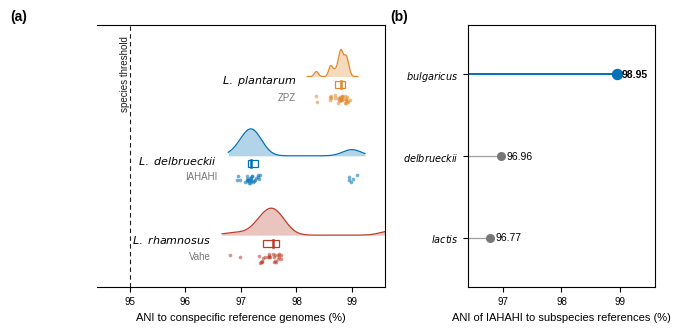

In [32]:
ani = table("ani_focal_vs_reference.csv")
sub = table("IAHAHI_subspecies_ANI.csv")

fig = plt.figure(figsize=(7.2, 3.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1.55, 1], wspace=0.35)
ax = fig.add_subplot(gs[0, 0])
rng = np.random.default_rng(0)

for row, species in enumerate(SPECIES):
    values = ani.loc[ani["species"] == species, "ANI"].dropna().values
    colour = PALETTE[species]
    density = np.linspace(values.min() - 0.15, values.max() + 0.15, 200)
    bandwidth = 0.45 * values.std(ddof=1) * len(values) ** (-1 / 5) or 0.05
    curve = np.exp(-0.5 * ((density[:, None] - values[None, :]) / bandwidth) ** 2).sum(1)
    curve = curve / curve.max() * 0.34
    ax.fill_between(density, row + 0.10, row + 0.10 + curve, color=colour, alpha=0.30, lw=0)
    ax.plot(density, row + 0.10 + curve, color=colour, lw=0.9)
    q1, med, q3 = np.percentile(values, [25, 50, 75])
    ax.add_patch(Rectangle((q1, row - 0.045), q3 - q1, 0.09, facecolor="white",
                           edgecolor=colour, lw=0.9, zorder=3))
    ax.plot([med, med], [row - 0.045, row + 0.045], color=colour, lw=1.8, zorder=4)
    ax.scatter(values, row - 0.19 + rng.uniform(-0.055, 0.055, len(values)),
               s=7, color=colour, alpha=0.55, lw=0, zorder=2)
    ax.text(values.min() - 0.35, row + 0.05, italic(species), ha="right", va="center")
    ax.text(values.min() - 0.35, row - 0.16, STRAIN[species], ha="right", va="center",
            fontsize=7, color=MUTED)

ax.axvline(95, color=INK, ls=(0, (4, 3)), lw=0.8)
ax.text(95, 2.62, "species threshold", rotation=90, va="top", ha="right", fontsize=7, color=INK)
ax.set_xlim(94.4, 99.6); ax.set_ylim(-0.55, 2.75)
ax.set_yticks([]); ax.spines["left"].set_visible(False)
ax.set_xlabel("ANI to conspecific reference genomes (%)")
panel_label(ax, "(a)", dx=-0.30)

ax2 = fig.add_subplot(gs[0, 1])
sub = sub.sort_values("ANI")
label_source = sub["subspecies_reference"] if "subspecies_reference" in sub.columns else sub.iloc[:, 0]
labels = [re.sub(r"\s*\(.*", "", str(x).replace("subsp. ", "")) for x in label_source]
positions = np.arange(len(sub))
best = sub["ANI"].idxmax()
for pos, (_, r) in zip(positions, sub.iterrows()):
    highlight = r.name == best
    colour = PALETTE["L. delbrueckii"] if highlight else MUTED
    ax2.plot([96.4, r["ANI"]], [pos, pos], color=colour, lw=1.4 if highlight else 0.9,
             alpha=1 if highlight else 0.7, zorder=1)
    ax2.scatter(r["ANI"], pos, s=52 if highlight else 30, color=colour, zorder=2)
    ax2.text(r["ANI"] + 0.09, pos, f"{r['ANI']:.2f}", va="center", fontsize=7.5,
             fontweight="bold" if highlight else "normal")
ax2.set_yticks(positions); ax2.set_yticklabels([italic(l) for l in labels])
ax2.set_xlim(96.4, 99.6); ax2.set_xlabel("ANI of IAHAHI to subspecies references (%)")
ax2.set_ylim(-0.6, len(sub) - 0.4)
panel_label(ax2, "(b)", dx=-0.42)
save(fig, "Figure1_ANI_taxonomic_placement"); plt.show()



## Figure 2 — Pangenome architecture

The accumulation panel uses the actual median and 2.5–97.5% curves from 200
genome-order permutations. The companion panels show sensitivity to 99.5% ANI
dereplication and the core/soft-core/shell/cloud composition.


saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure2_pangenome_architecture.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure2_pangenome_architecture.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure2_pangenome_architecture.png


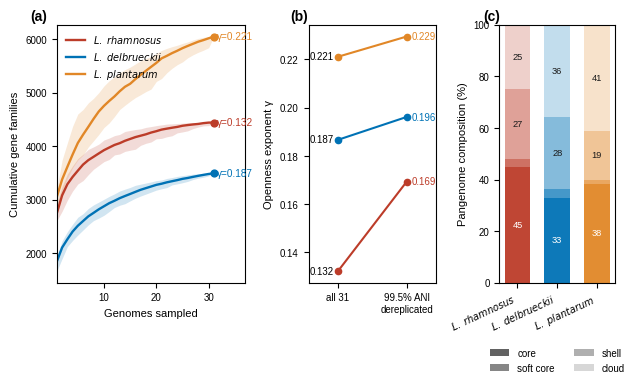

In [33]:
pan = table("pangenome_summary.csv")
rare = table("pangenome_rarefaction.csv")
der = table("derep_gamma.csv")

fig = plt.figure(figsize=(7.2, 3.35))
gs = fig.add_gridspec(1, 3, width_ratios=[1.55, 1.05, 0.95], wspace=0.44)

ax = fig.add_subplot(gs[0, 0])
for species in SPECIES:
    current = rare[rare["species"] == species].sort_values("n_genomes")
    summary = pan[pan["species"] == species].iloc[0]
    colour = PALETTE[species]
    ax.fill_between(
        current["n_genomes"], current["pangenome_low"], current["pangenome_high"],
        color=colour, alpha=0.18, lw=0,
    )
    ax.plot(
        current["n_genomes"], current["pangenome_median"],
        color=colour, lw=1.7, label=italic(species),
    )
    ax.scatter([31], [summary["pangenome"]], color=colour, s=24, zorder=3)
    ax.text(
        31.5, summary["pangenome"],
        f"γ={summary['gamma_median']:.3f}",
        va="center", fontsize=7.2, color=colour,
    )
ax.set_xlabel("Genomes sampled")
ax.set_ylabel("Cumulative gene families")
ax.set_xlim(1, 37)
ax.legend(frameon=False, loc="upper left")
panel_label(ax, "(a)")

ax2 = fig.add_subplot(gs[0, 1])
for species in SPECIES:
    full = pan.loc[pan["species"] == species, "gamma_median"].iloc[0]
    selected = der[der["species"] == species]
    if selected.empty:
        continue
    dereplicated = selected["gamma_derep"].iloc[0]
    ax2.plot(
        [0, 1], [full, dereplicated], color=PALETTE[species],
        lw=1.5, marker="o", ms=4.5,
    )
    ax2.text(-0.07, full, f"{full:.3f}", ha="right", va="center", fontsize=7)
    ax2.text(
        1.07, dereplicated, f"{dereplicated:.3f}",
        ha="left", va="center", fontsize=7, color=PALETTE[species],
    )
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["all 31", "99.5% ANI\ndereplicated"])
ax2.set_xlim(-0.43, 1.43)
ax2.set_ylabel("Openness exponent γ")
panel_label(ax2, "(b)")

ax3 = fig.add_subplot(gs[0, 2])
parts = ["core", "soft_core", "shell", "cloud"]
alphas = [0.95, 0.73, 0.48, 0.24]
for position, species in enumerate(SPECIES):
    row = pan[pan["species"] == species].iloc[0]
    bottom = 0.0
    for part, alpha in zip(parts, alphas):
        value = 100 * row[part] / row["pangenome"]
        ax3.bar(
            position, value, bottom=bottom, width=0.64,
            color=PALETTE[species], alpha=alpha, lw=0,
        )
        if value >= 8:
            ax3.text(
                position, bottom + value / 2, f"{value:.0f}",
                ha="center", va="center", fontsize=6.7,
                color="white" if alpha >= 0.7 else INK,
            )
        bottom += value
ax3.set_xticks(range(3))
ax3.set_xticklabels([italic(species) for species in SPECIES], rotation=25, ha="right")
ax3.set_ylabel("Pangenome composition (%)")
ax3.set_ylim(0, 100)
ax3.legend(
    handles=[
        Patch(facecolor="0.35", alpha=alpha, label=part.replace("_", " "))
        for part, alpha in zip(parts, alphas)
    ],
    loc="upper center", bbox_to_anchor=(0.5, -0.22),
    ncol=2, frameon=False,
)
panel_label(ax3, "(c)")

save(fig, "Figure2_pangenome_architecture")
plt.show()


### Figure 3 — Species-level panel prevalence

Colour is prevalence among 30 non-focal references. Text is `present/30`; the symbol after
the count is the focal-strain call (`●` present, `○` absent). Grey `NE` cells are intentionally
not evaluated and must not be interpreted as absence.


saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure3_strict13_prevalence.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure3_strict13_prevalence.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure3_strict13_prevalence.png


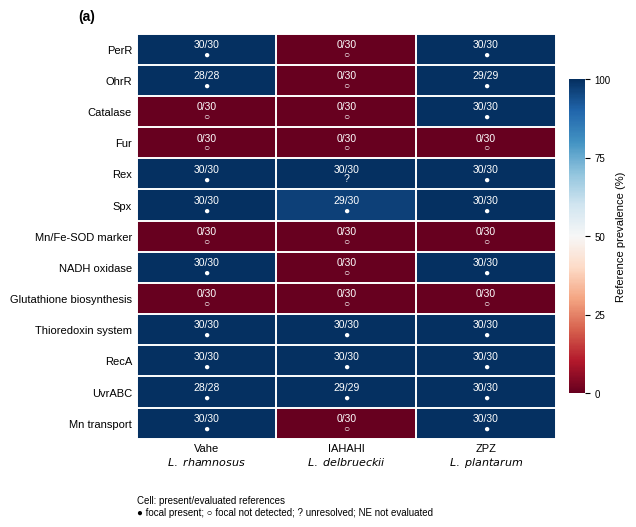

In [34]:
panel_plot = pd.read_csv(cache("Table3_panel_strict13_long.csv"))

TARGET_DISPLAY_LABELS = {
    "PerR": "PerR",
    "OhrR": "OhrR",
    "Catalase": "Catalase",
    "Fur": "Fur",
    "Rex": "Rex",
    "Spx": "Spx",
    "SOD": "Mn/Fe-SOD marker",
    "Nox": "NADH oxidase",
    "Glutathione_system": "Glutathione biosynthesis",
    "Thioredoxin_system": "Thioredoxin system",
    "RecA": "RecA",
    "UvrABC": "UvrABC",
    "Mn_transport": "Mn transport",
    "Mismatch_repair": "Mismatch repair",
    "Base_excision_repair": "Base-excision repair",
}

target_order = list(STRICT13_RULES)
species_order = list(TAG)

# =========================================================
# Build matrix and cell labels
# =========================================================

matrix = np.full(
    (len(target_order), len(species_order)),
    np.nan,
)

labels = [
    ["" for _ in species_order]
    for _ in target_order
]

for i, target in enumerate(target_order):
    for j, species in enumerate(species_order):

        selected = panel_plot[
            (panel_plot["target"] == target)
            & (panel_plot["species"] == species)
        ]

        if selected.empty:
            labels[i][j] = "NE"
            continue

        row = selected.iloc[0]

        evaluated = int(row["reference_evaluated"])
        present = int(row["reference_present"])

        if evaluated > 0:
            matrix[i, j] = float(row["reference_prevalence_pct"])
        else:
            matrix[i, j] = np.nan

        if pd.isna(row["focal_present"]):
            symbol = "?"
        else:
            symbol = "●" if int(row["focal_present"]) == 1 else "○"

        # Two-line label is easier to read than everything in one line
        labels[i][j] = f"{present}/{evaluated}\n{symbol}"


# =========================================================
# Plot
# =========================================================

cmap = mpl.colormaps["RdBu"].copy()
cmap.set_bad("#E6E6E6")   # grey for not evaluated / missing

fig, ax = plt.subplots(figsize=(7.0, 5.4))

image = ax.imshow(
    matrix,
    vmin=0,
    vmax=100,
    cmap=cmap,
    aspect="auto",
    interpolation="none",
)

# Cell labels
for i in range(len(target_order)):
    for j in range(len(species_order)):

        value = matrix[i, j]

        if labels[i][j] == "NE":
            text_colour = "black"
        elif np.isfinite(value):
            # white text on darker colours
            text_colour = "white" if (value <= 20 or value >= 70) else "black"
        else:
            text_colour = "black"

        ax.text(
            j,
            i,
            labels[i][j],
            ha="center",
            va="center",
            color=text_colour,
            fontsize=7.5,
            linespacing=0.95,
        )


# =========================================================
# Axes formatting
# =========================================================

ax.set_xticks(range(len(species_order)))
ax.set_xticklabels(
    [f"{FOCAL[s]}\n{italic(s)}" for s in species_order],
    fontsize=8,
)

ax.set_yticks(range(len(target_order)))
ax.set_yticklabels(
    [TARGET_DISPLAY_LABELS.get(target, target.replace("_", " ")) for target in target_order],
    fontsize=8,
)

# White grid between cells
ax.set_xticks(np.arange(-0.5, len(species_order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(target_order), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.4)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

ax.tick_params(
    axis="both",
    which="major",
    length=0,
    labelsize=8,
)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)


# =========================================================
# Colour bar
# =========================================================

colourbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.035,
    pad=0.03,
)

colourbar.set_label("Reference prevalence (%)")
colourbar.set_ticks([0, 25, 50, 75, 100])
colourbar.outline.set_visible(False)


# =========================================================
# Footnote / explanation
# =========================================================

ax.text(
    0,
    -0.14,
    (
        "Cell: present/evaluated references\n"
        "● focal present; ○ focal not detected; ? unresolved; NE not evaluated"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=7,
)

panel_label(ax, "(a)")

fig.subplots_adjust(
    left=0.26,
    right=0.90,
    top=0.97,
    bottom=0.22,
)

export_figure(
    fig,
    "Figure3_strict13_prevalence",
)

plt.show()


### Figure 4 — Unrooted core-genome phylogeny with the 13-target panel

The three species are exported as separate full-width panels. Branch lengths
are shown; the trees are unrooted and should not be interpreted directionally.


saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure4A_tree_strict13_L_rhamnosus.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure4A_tree_strict13_L_rhamnosus.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure4A_tree_strict13_L_rhamnosus.png


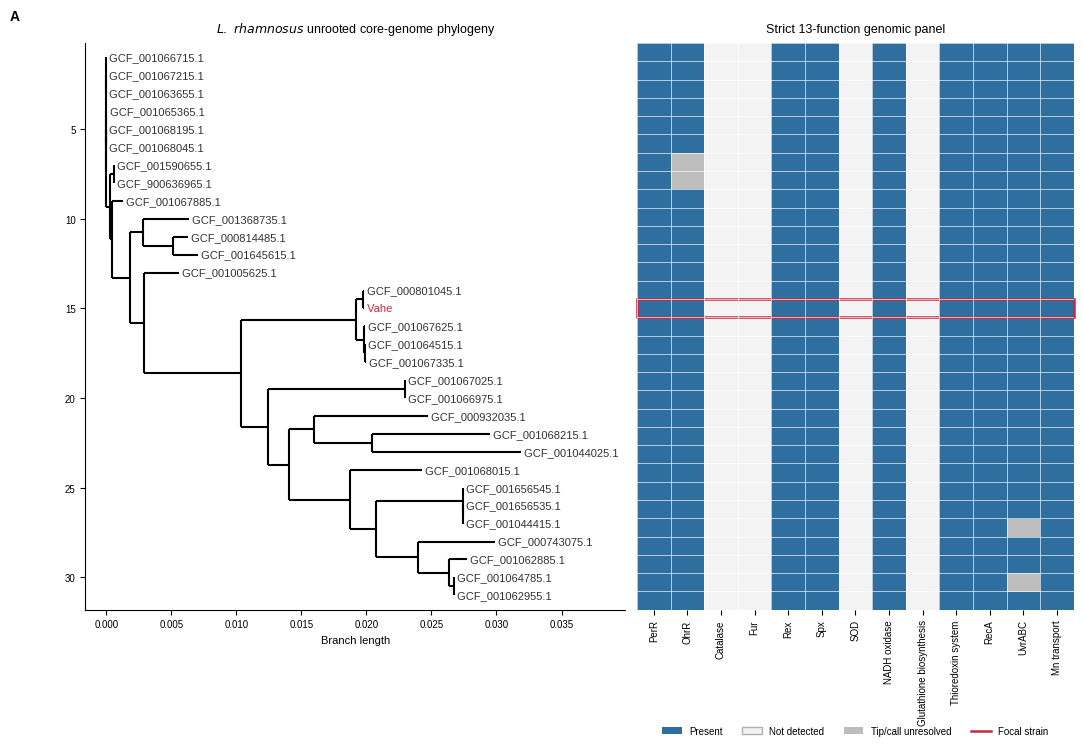

saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure4B_tree_strict13_L_delbrueckii.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure4B_tree_strict13_L_delbrueckii.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure4B_tree_strict13_L_delbrueckii.png


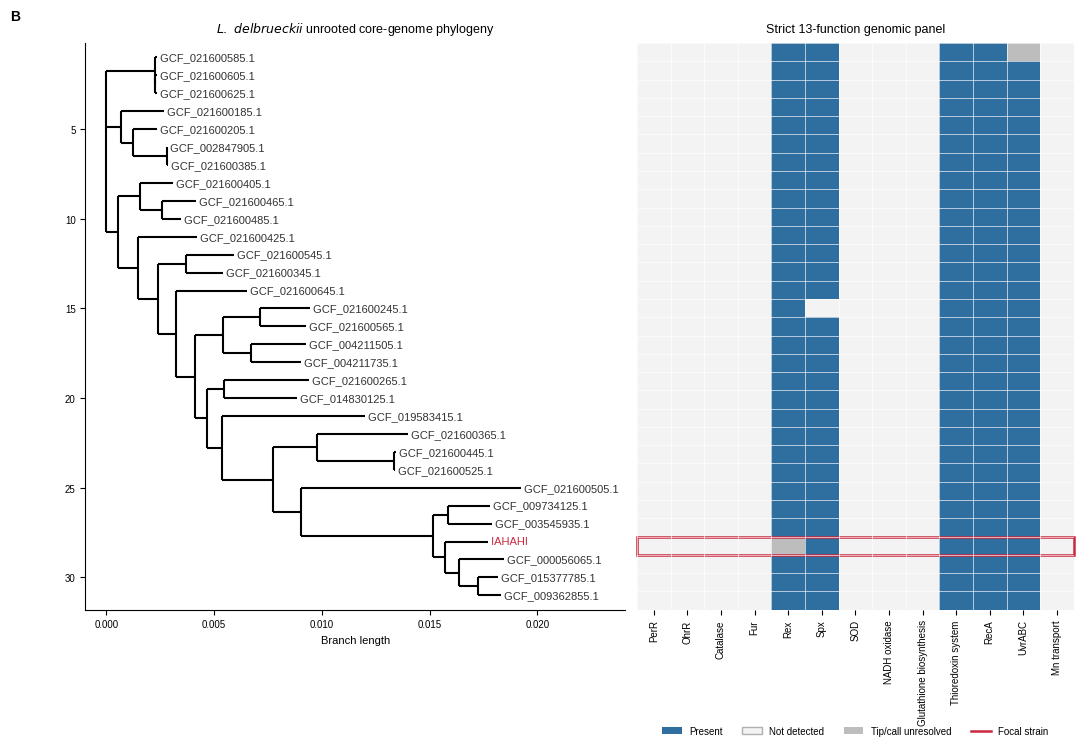

saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure4C_tree_strict13_L_plantarum.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure4C_tree_strict13_L_plantarum.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure4C_tree_strict13_L_plantarum.png


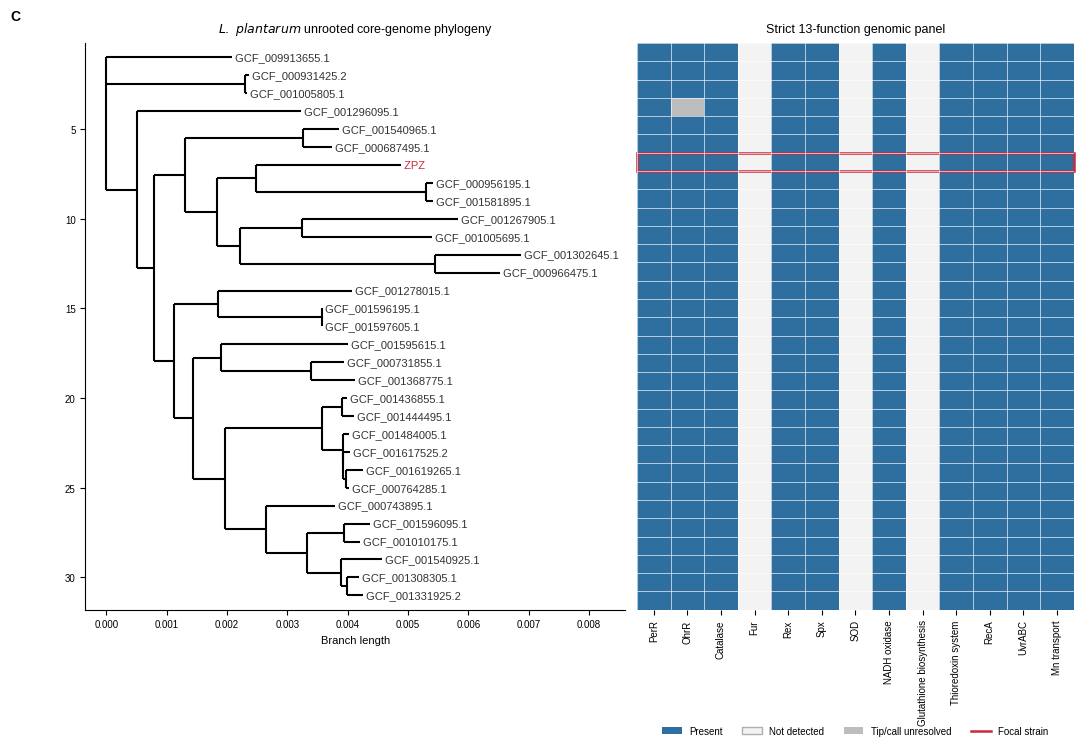

In [35]:
from Bio import Phylo
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle

FASTTREE_ENV = env_with("FastTree")
TREE_TARGETS = list(STRICT13_RULES)
TREE_TARGET_LABELS = {
    "PerR": "PerR",
    "OhrR": "OhrR",
    "Catalase": "Catalase",
    "Fur": "Fur",
    "Rex": "Rex",
    "Spx": "Spx",
    "SOD": "SOD",
    "Nox": "NADH oxidase",
    "Glutathione_system": "Glutathione biosynthesis",
    "Thioredoxin_system": "Thioredoxin system",
    "RecA": "RecA",
    "UvrABC": "UvrABC",
    "Mn_transport": "Mn transport",
}

def target_query_available(target):
    if target in PATHWAY_TARGETS:
        return False
    if target == "UvrABC":
        return all(REF.get(subunit) for subunit in ("uvrA", "uvrB", "uvrC"))
    if target == "Spx":
        return bool(REF.get("Spx") and REF.get("MgsR"))
    return bool(REF.get(target))

def resolve_tree_accession(species, tip_name):
    candidates = [
        accession for sp, accession, _ in ALLDIRS if sp == species
    ]
    tip_name = str(tip_name or "")
    exact = [accession for accession in candidates if accession == tip_name]
    if exact:
        return exact[0]
    compatible = [
        accession
        for accession in candidates
        if accession.endswith(tip_name) or tip_name.endswith(accession)
    ]
    return compatible[0] if len(compatible) == 1 else None

def ensure_core_tree(species):
    tag = TAG[species]
    tree_directory = WORK / "roary" / tag
    tree_path = tree_directory / "core_tree.nwk"
    temporary_tree = tree_directory / "core_tree.nwk.tmp"
    log_path = tree_directory / "FastTree.log"
    if tree_path.exists() and tree_path.stat().st_size:
        return tree_path
    alignment_path = next(
        (
            tree_directory / name
            for name in ("core_gene_alignment_filtered.aln", "core_gene_alignment.aln")
            if (tree_directory / name).exists()
        ),
        None,
    )
    if alignment_path is None:
        raise FileNotFoundError(f"No core alignment found for {species}")
    if FASTTREE_ENV is None:
        raise RuntimeError("FastTree was not found in the configured environments.")
    command = [
        *tool_command("FastTree", FASTTREE_ENV),
        "-nt", "-gtr", str(alignment_path),
    ]
    print(f"Building FastTree for {species}...", flush=True)
    started = time.monotonic()
    with open(temporary_tree, "w") as tree_handle, open(log_path, "w") as log_handle:
        process = subprocess.Popen(
            command, stdout=tree_handle, stderr=log_handle, text=True
        )
        while process.poll() is None:
            elapsed_minutes = int((time.monotonic() - started) // 60)
            print(
                f"{species}: FastTree running ({elapsed_minutes} min elapsed)",
                flush=True,
            )
            time.sleep(60)
    if process.returncode != 0 or not temporary_tree.exists() or not temporary_tree.stat().st_size:
        detail = log_path.read_text(errors="replace")[-3000:] if log_path.exists() else ""
        raise RuntimeError(f"FastTree failed for {species}: {detail.strip()}")
    temporary_tree.replace(tree_path)
    print(f"{species}: FastTree completed and checkpoint saved.", flush=True)
    return tree_path


strict_tree_calls = pd.read_csv(cache("strict13_genome_calls_long.csv"))
strict_tree_calls["call"] = pd.to_numeric(strict_tree_calls["call"], errors="coerce")
STRICT_TREE_LOOKUP = strict_tree_calls.set_index(
    ["species", "accession", "target"]
)["call"].to_dict()

def strict_tree_call(species, accession, target):
    value = STRICT_TREE_LOOKUP.get((species, accession, target), np.nan)
    return float(value) if pd.notna(value) else np.nan

tree_panel_records = []
for species in TAG:
    tree_path = ensure_core_tree(species)
    tree = Phylo.read(tree_path, "newick")
    tree.ladderize()
    tips = [terminal.name for terminal in tree.get_terminals()]
    tip_to_accession = {
        tip_name: resolve_tree_accession(species, tip_name)
        for tip_name in tips
    }
    resolved_accessions = [tip_to_accession[tip_name] for tip_name in tips]
    unresolved = [
        tip for tip, accession in zip(tips, resolved_accessions) if accession is None
    ]
    if unresolved:
        warnings.warn(
            f"{species}: {len(unresolved)} tree tips could not be matched to strict13 calls: "
            + ", ".join(map(str, unresolved[:5]))
        )

    matrix = np.full((len(tips), len(TREE_TARGETS)), np.nan, dtype=float)
    for row_index, accession in enumerate(resolved_accessions):
        for column_index, target in enumerate(TREE_TARGETS):
            if accession is not None:
                matrix[row_index, column_index] = strict_tree_call(
                    species, accession, target
                )
            tree_panel_records.append(
                {
                    "species": species,
                    "tip_name": tips[row_index],
                    "accession": accession,
                    "is_focal": accession == FOCAL[species],
                    "target": target,
                    "present": matrix[row_index, column_index],
                    "panel": "strict13",
                }
            )

    figure_height = max(6.0, 0.205 * len(tips) + 1.2)
    fig = plt.figure(figsize=(10.8, figure_height))
    grid = GridSpec(
        1, 2, width_ratios=[1.42, 1.15], wspace=0.025,
        left=0.07, right=0.985, top=0.94, bottom=0.19,
    )
    tree_axis = fig.add_subplot(grid[0])
    heatmap_axis = fig.add_subplot(grid[1])

    Phylo.draw(
        tree,
        axes=tree_axis,
        do_show=False,
        label_func=lambda clade: clade.name if clade.is_terminal() else "",
        label_colors=lambda label: (
            "#C9283E"
            if tip_to_accession.get(label) == FOCAL[species]
            else "#333333"
        ),
        branch_labels=lambda clade: None,
    )
    tree_axis.set_title(f"{italic(species)} unrooted core-genome phylogeny", pad=8)
    tree_axis.set_ylabel("")
    tree_axis.set_xlabel("Branch length")
    tree_axis.spines["top"].set_visible(False)
    tree_axis.spines["right"].set_visible(False)

    presence_cmap = mpl.colors.ListedColormap(["#F3F3F3", "#2F6F9F"])
    presence_cmap.set_bad("#BDBDBD")
    heatmap_axis.imshow(
        np.ma.masked_invalid(matrix),
        aspect="auto",
        cmap=presence_cmap,
        vmin=0,
        vmax=1,
        interpolation="none",
        extent=[0, len(TREE_TARGETS), len(tips) + 0.5, 0.5],
    )
    heatmap_axis.set_xlim(0, len(TREE_TARGETS))
    heatmap_axis.set_ylim(len(tips) + 0.5, 0.5)
    heatmap_axis.set_xticks(np.arange(len(TREE_TARGETS)) + 0.5)
    heatmap_axis.set_xticklabels(
        [TREE_TARGET_LABELS[target] for target in TREE_TARGETS],
        rotation=90, ha="center", va="top",
    )
    heatmap_axis.set_yticks([])
    heatmap_axis.set_title("Strict 13-function genomic panel", pad=8)
    heatmap_axis.set_xticks(np.arange(0, len(TREE_TARGETS) + 1), minor=True)
    heatmap_axis.set_yticks(np.arange(0.5, len(tips) + 1.5, 1), minor=True)
    heatmap_axis.grid(which="minor", color="white", linewidth=0.45)
    heatmap_axis.tick_params(which="minor", bottom=False, left=False)
    for spine in heatmap_axis.spines.values():
        spine.set_visible(False)

    focal_accession = FOCAL[species]
    if focal_accession in resolved_accessions:
        focal_row = resolved_accessions.index(focal_accession)
        heatmap_axis.add_patch(
            Rectangle(
                (0, focal_row + 0.5), len(TREE_TARGETS), 1,
                fill=False, edgecolor="#C9283E", linewidth=1.8, clip_on=False,
            )
        )

    legend_handles = [
        Patch(facecolor="#2F6F9F", edgecolor="none", label="Present"),
        Patch(facecolor="#F3F3F3", edgecolor="#B0B0B0", label="Not detected"),
        Patch(facecolor="#BDBDBD", edgecolor="none", label="Tip/call unresolved"),
        Line2D([0], [0], color="#C9283E", lw=1.8, label="Focal strain"),
    ]
    heatmap_axis.legend(
        handles=legend_handles, frameon=False, ncol=4,
        loc="upper center", bbox_to_anchor=(0.5, -0.19),
    )

    panel = chr(ord("A") + list(TAG).index(species))
    panel_label(tree_axis, panel)
    export_figure(fig, f"Figure4{panel}_tree_strict13_{TAG[species]}")
    plt.show()

tree_panel_df = pd.DataFrame(tree_panel_records)
tree_panel_df.to_csv(cache("tree_strict13_calls_long.csv"), index=False)


### Figure 5 — Selection on shared high-confidence DNA-repair genes

The primary comparison uses the deterministic set of 10 high-confidence
DNA-repair families represented in all three species. No oxidative-defence
family passed the primary cross-species selection rules. The complete
pre-curation screen remains available as Supplementary Figure S4.


saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure5_dnds_curated.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure5_dnds_curated.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure5_dnds_curated.png


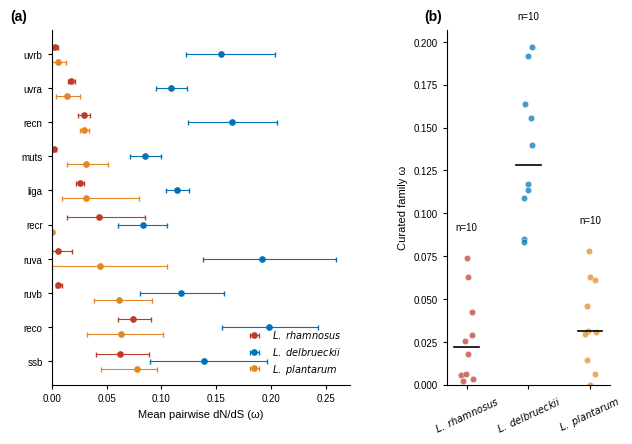

saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S4_dnds_complete.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S4_dnds_complete.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S4_dnds_complete.png


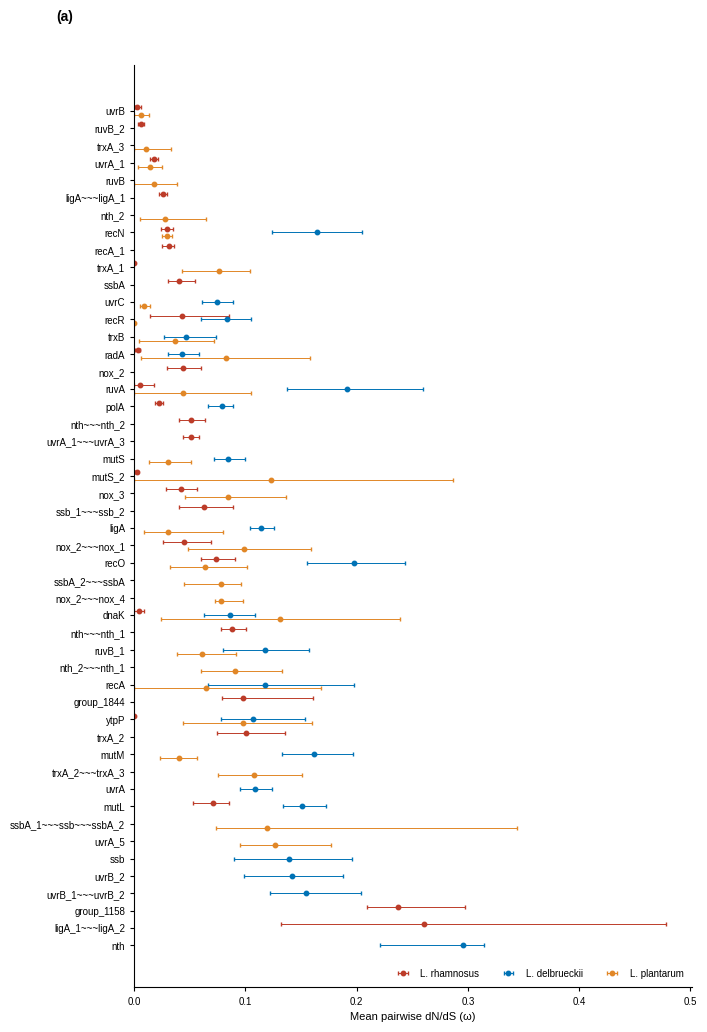

In [36]:
dnds_curated_plot = pd.read_csv(cache("dnds_curated_high_confidence.csv"))
if dnds_curated_plot.empty:
    raise RuntimeError("No shared high-confidence dN/dS genes passed the curated rules.")

gene_order = (
    dnds_curated_plot.groupby("canonical_symbol")["omega"]
    .median().sort_values().index.tolist()
)
gene_to_y = {gene: y for y, gene in enumerate(gene_order)}
offsets = dict(zip(list(TAG), (-0.22, 0.0, 0.22)))

height = min(7.5, max(4.2, 0.30 * len(gene_order) + 1.6))
fig, axes = plt.subplots(
    1, 2, figsize=(7.2, height),
    gridspec_kw={"width_ratios": [1.65, 0.9]},
)
for species in TAG:
    selected = dnds_curated_plot[dnds_curated_plot["species"] == species]
    y = np.array([
        gene_to_y[gene] + offsets[species]
        for gene in selected["canonical_symbol"]
    ])
    x = selected["boot_median"].to_numpy(dtype=float)
    xerr = np.vstack(
        [
            x - selected["ci_lo"].to_numpy(dtype=float),
            selected["ci_hi"].to_numpy(dtype=float) - x,
        ]
    )
    axes[0].errorbar(
        x, y, xerr=xerr, fmt="o", ms=3.8, capsize=1.8,
        color=SPECIES_COLOUR[species], elinewidth=0.8, label=italic(species),
    )

axes[0].set_yticks(range(len(gene_order)))
axes[0].set_yticklabels(gene_order)
axes[0].set_xlabel("Mean pairwise dN/dS (ω)")
axes[0].set_xlim(left=0)
axes[0].invert_yaxis()
axes[0].legend(frameon=False, loc="lower right")
clean_axes(axes[0])
panel_label(axes[0], "(a)")

rng_dnds_plot = np.random.default_rng(RANDOM_SEED)
for x_position, species in enumerate(TAG):
    values = dnds_curated_plot.loc[
        dnds_curated_plot["species"] == species, "omega"
    ].to_numpy(dtype=float)
    jitter = rng_dnds_plot.uniform(-0.10, 0.10, size=len(values))
    axes[1].scatter(
        x_position + jitter, values, s=21,
        color=SPECIES_COLOUR[species], alpha=0.72,
        edgecolor="white", linewidth=0.35,
    )
    median = float(np.median(values))
    axes[1].plot(
        [x_position - 0.20, x_position + 0.20],
        [median, median], color="black", lw=1.2,
    )
    axes[1].text(
        x_position, max(values) + 0.015,
        f"n={len(values)}", ha="center", va="bottom", fontsize=7,
    )
axes[1].set_xticks(range(len(TAG)))
axes[1].set_xticklabels([italic(species) for species in TAG], rotation=25)
axes[1].set_ylabel("Curated family ω")
axes[1].set_ylim(bottom=0)
clean_axes(axes[1])
panel_label(axes[1], "(b)")

fig.subplots_adjust(wspace=0.42)
export_figure(fig, "Figure5_dnds_curated")
plt.show()

# Complete screen retained for transparency, but not used as the primary comparison.
dnds_full_plot = pd.read_csv(cache("dnds_FINAL.csv")).replace(
    [np.inf, -np.inf], np.nan
).dropna(subset=["omega", "ci_lo", "ci_hi"])
full_family_order = (
    dnds_full_plot.groupby("gene_family")["omega"]
    .median().sort_values().index.tolist()
)
full_family_to_y = {
    family: y for y, family in enumerate(full_family_order)
}
full_height = max(8.0, 0.22 * len(full_family_order) + 1.2)
fig_full, ax_full = plt.subplots(figsize=(7.2, full_height))
for species in TAG:
    selected = dnds_full_plot[dnds_full_plot["species"] == species]
    y = np.array([
        full_family_to_y[family] + offsets[species]
        for family in selected["gene_family"]
    ])
    x = selected["boot_median"].to_numpy(dtype=float)
    xerr = np.vstack(
        [
            x - selected["ci_lo"].to_numpy(dtype=float),
            selected["ci_hi"].to_numpy(dtype=float) - x,
        ]
    )
    ax_full.errorbar(
        x, y, xerr=xerr, fmt="o", ms=3.2, capsize=1.5,
        color=SPECIES_COLOUR[species], elinewidth=0.7, label=species,
    )
ax_full.set_yticks(range(len(full_family_order)))
ax_full.set_yticklabels(full_family_order)
ax_full.set_xlabel("Mean pairwise dN/dS (ω)")
ax_full.set_xlim(left=0)
ax_full.invert_yaxis()
ax_full.legend(frameon=False, ncol=3, loc="lower right")
clean_axes(ax_full)
panel_label(ax_full, "(a)")
export_figure(fig_full, "Supplementary_Figure_S4_dnds_complete")
plt.show()


## Supplementary Figure S9 — Species-specific oxidative-defence dN/dS

Points and genome-bootstrap intervals are shown only for combinations passing the prespecified within-species curation. `NE` denotes no evaluable estimate and does not imply a numerical zero.


saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S9_oxidative_dnds_species_specific.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S9_oxidative_dnds_species_specific.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S9_oxidative_dnds_species_specific.png


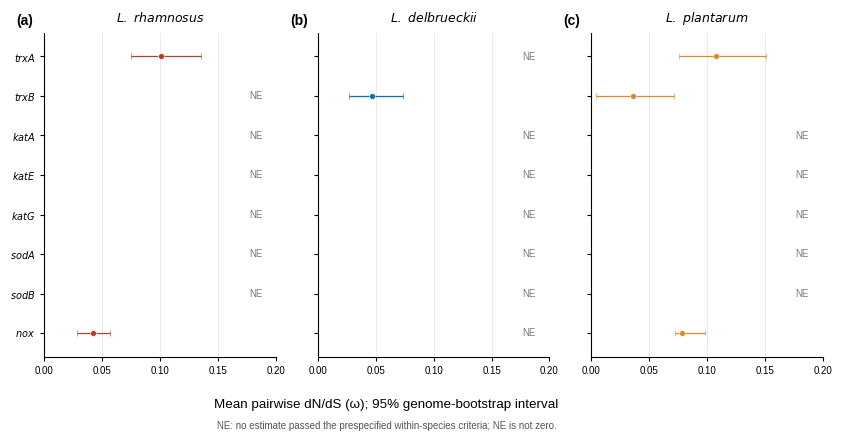

In [37]:
oxidative_plot = pd.read_csv(
    cache("dnds_oxidative_species_specific.csv")
)
oxidative_plot["estimate_status"] = oxidative_plot[
    "estimate_status"
].astype(str)

evaluated_oxidative = oxidative_plot[
    oxidative_plot["estimate_status"].eq("evaluated")
].copy()
max_ci = pd.to_numeric(
    evaluated_oxidative.get("ci_hi", pd.Series(dtype=float)),
    errors="coerce",
).max()
x_max = max(0.20, float(max_ci) * 1.18) if pd.notna(max_ci) else 0.20
x_ne = 0.94 * x_max

symbol_order = list(OXIDATIVE_DNDS_SYMBOLS)
symbol_labels = [
    rf"$\it{{{OXIDATIVE_DNDS_LABELS[symbol]}}}$"
    for symbol in symbol_order
]
y_positions = np.arange(len(symbol_order))

fig_oxidative, axes_oxidative = plt.subplots(
    1, len(TAG), figsize=(9.0, 4.5), sharex=True, sharey=True
)
for panel_index, (axis, species) in enumerate(zip(axes_oxidative, TAG)):
    species_rows = oxidative_plot[
        oxidative_plot["species"] == species
    ].set_index("canonical_symbol")
    for y_position, symbol in zip(y_positions, symbol_order):
        row = species_rows.loc[symbol]
        if row["estimate_status"] == "evaluated":
            center = float(row["boot_median"])
            lower = float(row["ci_lo"])
            upper = float(row["ci_hi"])
            axis.errorbar(
                center,
                y_position,
                xerr=np.array([[max(0.0, center - lower)],
                               [max(0.0, upper - center)]]),
                fmt="o",
                ms=4.2,
                capsize=2.0,
                color=SPECIES_COLOUR[species],
                elinewidth=0.9,
                markeredgecolor="white",
                markeredgewidth=0.4,
                zorder=3,
            )
        else:
            axis.text(
                x_ne, y_position, "NE",
                ha="right", va="center", fontsize=7,
                color="#777777",
            )

    axis.set_xlim(0, x_max)
    axis.set_ylim(-0.6, len(symbol_order) - 0.4)
    axis.set_title(italic(species), pad=8)
    axis.grid(axis="x", color="#E6E6E6", linewidth=0.6, zorder=0)
    clean_axes(axis)
    panel_label(axis, "(" + chr(ord("a") + panel_index) + ")", dx=-0.12)

axes_oxidative[0].set_yticks(y_positions)
axes_oxidative[0].set_yticklabels(symbol_labels)
axes_oxidative[0].invert_yaxis()
fig_oxidative.supxlabel("Mean pairwise dN/dS (ω); 95% genome-bootstrap interval", y=0.06)
fig_oxidative.text(
    0.5, 0.015,
    "NE: no estimate passed the prespecified within-species criteria; NE is not zero.",
    ha="center", va="bottom", fontsize=7, color="#555555",
)
fig_oxidative.subplots_adjust(
    left=0.12, right=0.985, top=0.90, bottom=0.18, wspace=0.18
)
export_figure(
    fig_oxidative,
    "Supplementary_Figure_S9_oxidative_dnds_species_specific",
)
plt.show()


### Figure 6 — Genomic repertoire and documented phenotype status

This descriptive summary does not treat ZPZ as a negative biological control
and does not infer causality from panel size.


In [38]:
def focal_unique_family_count(species):
    isolates = PAN[species]["isolates"]
    matrix = np.asarray(PAN[species]["M"])

    focal = FOCAL[species]
    matches = [
        index
        for index, isolate in enumerate(isolates)
        if isolate == focal
        or isolate.endswith(focal)
        or focal.endswith(isolate)
    ]

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected exactly one focal strain in Panaroo matrix for "
            f"{species}; found {len(matches)}: {matches}"
        )

    focal_index = matches[0]
    family_frequency = matrix.sum(axis=1)

    return int(
        (
            (family_frequency == 1)
            & (matrix[:, focal_index] == 1)
        ).sum()
    )


unique_counts = {
    FOCAL[species]: focal_unique_family_count(species)
    for species in TAG
}

print("Focal-unique families:", unique_counts)

Focal-unique families: {'Vahe': 1, 'IAHAHI': 10, 'ZPZ': 39}


saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure6_genotype_documented_phenotype.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure6_genotype_documented_phenotype.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Figure6_genotype_documented_phenotype.png


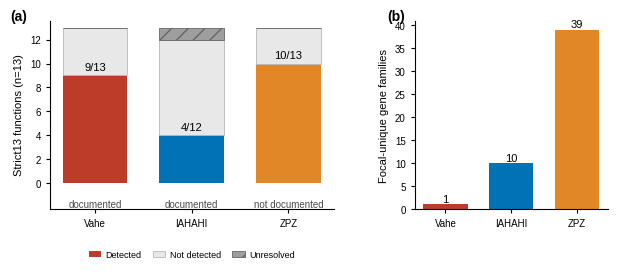

,species,strain,strict13_detected,strict13_evaluated,strict13_unresolved,focal_unique_families,documented_phenotype_status
0,L. rhamnosus,Vahe,9,13,0,1,Host radioprotection documented
1,L. delbrueckii,IAHAHI,4,12,1,10,Host radioprotection documented
2,L. plantarum,ZPZ,10,13,0,39,No host-radioprotection report identified


In [39]:
phenotype_status = {
    "Vahe": "Host radioprotection documented",
    "IAHAHI": "Host radioprotection documented",
    "ZPZ": "No host-radioprotection report identified",
}
strain_order = [FOCAL[species] for species in TAG]
species_for_strain = {FOCAL[species]: species for species in TAG}
phenotype_rows = []
for strain in strain_order:
    species = species_for_strain[strain]
    row = strict13_focal_totals[
        (strict13_focal_totals["species"] == species)
        & (strict13_focal_totals["accession"] == strain)
    ].iloc[0]
    phenotype_rows.append(
        {
            "species": species,
            "strain": strain,
            "strict13_detected": int(row["detected"]),
            "strict13_evaluated": int(row["evaluated"]),
            "strict13_unresolved": int(13 - row["evaluated"]),
            "focal_unique_families": int(unique_counts[strain]),
            "documented_phenotype_status": phenotype_status[strain],
        }
    )
phenotype_summary = pd.DataFrame(phenotype_rows)
phenotype_summary.to_csv(
    cache("genotype_documented_phenotype_summary.csv"), index=False
)
fig, axes = plt.subplots(
    1, 2, figsize=(7.2, 3.25),
    gridspec_kw={"width_ratios": [1.25, 0.85]},
)
x = np.arange(len(strain_order))
colours = [STRAIN_COLOUR[strain] for strain in strain_order]
detected = phenotype_summary["strict13_detected"].to_numpy()
evaluated = phenotype_summary["strict13_evaluated"].to_numpy()
not_detected = evaluated - detected
unresolved = 13 - evaluated
axes[0].bar(
    x, detected, color=colours, width=0.67,
    label="Detected",
)
axes[0].bar(
    x, not_detected, bottom=detected, color="#E8E8E8",
    edgecolor="#B8B8B8", linewidth=0.6, width=0.67, label="Not detected",
)
axes[0].bar(
    x, unresolved, bottom=evaluated, color="#9E9E9E",
    edgecolor="#666666", linewidth=0.6, hatch="//", width=0.67,
    label="Unresolved",
)
for index, row in phenotype_summary.iterrows():
    axes[0].text(
        index, row["strict13_detected"] + 0.25,
        f'{row["strict13_detected"]}/{row["strict13_evaluated"]}',
        ha="center", va="bottom", fontsize=8,
    )
    status = (
        "documented"
        if row["strain"] in ("Vahe", "IAHAHI")
        else "not documented"
    )
    axes[0].text(
        index, -1.35, status,
        ha="center", va="top", fontsize=7, color="#4A4A4A",
    )
axes[0].set_xticks(x)
axes[0].set_xticklabels(strain_order)
axes[0].set_ylim(-2.2, 13.6)
axes[0].set_yticks(range(0, 14, 2))
axes[0].set_ylabel("Strict13 functions (n=13)")
axes[0].legend(
    frameon=False, fontsize=6.5, loc="upper center",
    bbox_to_anchor=(0.5, -0.20), ncol=3,
    handlelength=1.4, columnspacing=1.2, handletextpad=0.5, borderaxespad=0.0,
)
clean_axes(axes[0])
panel_label(axes[0], "(a)")
unique_values = phenotype_summary["focal_unique_families"].to_numpy()
axes[1].bar(x, unique_values, color=colours, width=0.67)
for index, value in enumerate(unique_values):
    axes[1].text(
        index, value, str(value),
        ha="center", va="bottom", fontsize=8,
    )
axes[1].set_xticks(x)
axes[1].set_xticklabels(strain_order)
axes[1].set_ylabel("Focal-unique gene families")
clean_axes(axes[1])
panel_label(axes[1], "(b)")
fig.subplots_adjust(wspace=0.34, bottom=0.30)
export_figure(fig, "Figure6_genotype_documented_phenotype")
plt.show()
display(phenotype_summary)

### Supplementary Figure S1 — assembly QC

This diagnostic plot makes fragmented or size-outlying assemblies visible; it is not a
substitute for completeness/contamination estimates.


saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S1_QC.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S1_QC.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S1_QC.png


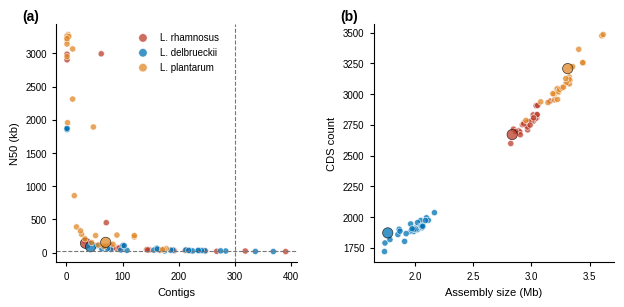

In [40]:
qc_plot = pd.read_csv(cache("QC_all93.csv"))
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.1))

for species in TAG:
    selected = qc_plot[qc_plot["species"] == species]
    axes[0].scatter(
        selected["contigs"], selected["N50"] / 1000,
        s=np.where(selected["is_focal"], 55, 20),
        color=SPECIES_COLOUR[species], alpha=0.75,
        edgecolor=np.where(selected["is_focal"], "black", "white"),
        linewidth=0.5, label=species,
    )
    axes[1].scatter(
        selected["size_bp"] / 1e6, selected["CDS"],
        s=np.where(selected["is_focal"], 55, 20),
        color=SPECIES_COLOUR[species], alpha=0.75,
        edgecolor=np.where(selected["is_focal"], "black", "white"),
        linewidth=0.5,
    )

axes[0].axvline(300, color="#777777", ls="--", lw=0.8)
axes[0].axhline(20, color="#777777", ls="--", lw=0.8)
axes[0].set_xlabel("Contigs")
axes[0].set_ylabel("N50 (kb)")
axes[0].legend(frameon=False)
axes[1].set_xlabel("Assembly size (Mb)")
axes[1].set_ylabel("CDS count")
for label, ax in zip(("(a)", "(b)"), axes):
    clean_axes(ax)
    panel_label(ax, label)
fig.subplots_adjust(wspace=0.32)
export_figure(fig, "Supplementary_Figure_S1_QC")
plt.show()


### Supplementary Figure S2 — Gene-frequency spectra

The log-scaled y-axis preserves the U-shaped pangenome spectrum while keeping intermediate
frequency classes visible.


saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S2_frequency_spectra.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S2_frequency_spectra.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S2_frequency_spectra.png


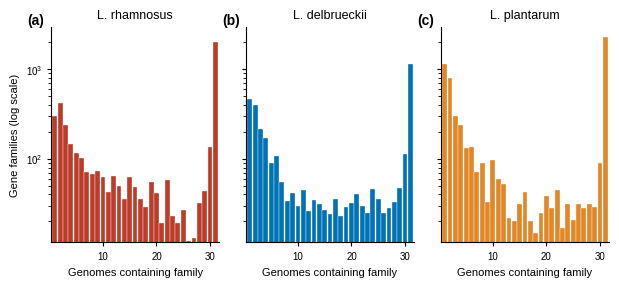

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.8), sharey=True)
for axis, species in zip(axes, TAG):
    matrix = PAN[species]["M"]
    n_genomes = PAN[species]["N"]
    frequency_counts = np.bincount(
        matrix.sum(axis=1).astype(int), minlength=n_genomes + 1
    )[1:n_genomes + 1]
    axis.bar(
        np.arange(1, n_genomes + 1),
        frequency_counts,
        color=SPECIES_COLOUR[species],
        edgecolor="white",
        linewidth=0.25,
        width=0.9,
    )
    axis.set_yscale("log")
    axis.set_title(species)
    axis.set_xlabel("Genomes containing family")
    axis.set_xlim(0.3, n_genomes + 0.7)
    clean_axes(axis)
axes[0].set_ylabel("Gene families (log scale)")
for label, axis in zip(("(a)", "(b)", "(c)"), axes):
    panel_label(axis, label)
fig.subplots_adjust(wspace=0.16)
export_figure(fig, "Supplementary_Figure_S2_frequency_spectra")
plt.show()


### Supplementary Figure S3 — Focal-unique families and GC-compositional screen

Panel A reports focal-unique Panaroo families. Panel B shows the GC z-score of focal-unique CDS;
the dashed lines mark the pre-specified compositional-outlier threshold \(|z|>2\).


saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S3_unique_HGT.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S3_unique_HGT.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S3_unique_HGT.png


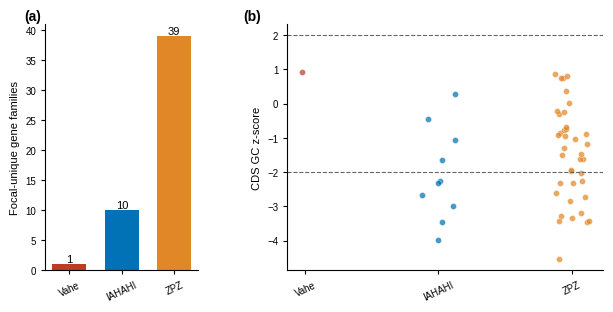

In [42]:
hgt_plot = pd.read_csv(cache("hgt_candidates.csv"))

fig, axes = plt.subplots(
    1, 2, figsize=(7.2, 3.2), gridspec_kw={"width_ratios": [0.75, 1.55]}
)
strain_order = [FOCAL[species] for species in TAG]
bar_colours = [STRAIN_COLOUR[strain] for strain in strain_order]
bar_values = [unique_counts[strain] for strain in strain_order]
axes[0].bar(strain_order, bar_values, color=bar_colours, width=0.65)
for x_position, value in enumerate(bar_values):
    axes[0].text(x_position, value, str(value), ha="center", va="bottom")
axes[0].set_ylabel("Focal-unique gene families")
axes[0].tick_params(axis="x", rotation=25)
clean_axes(axes[0])
panel_label(axes[0], "(a)")

rng_hgt = np.random.default_rng(RANDOM_SEED)
for x_position, strain in enumerate(strain_order):
    selected = hgt_plot[hgt_plot["strain"] == strain]
    jitter = rng_hgt.uniform(-0.13, 0.13, size=len(selected))
    axes[1].scatter(
        x_position + jitter,
        selected["z"],
        s=19,
        color=STRAIN_COLOUR[strain],
        alpha=0.72,
        edgecolor="white",
        linewidth=0.3,
    )
axes[1].axhline(2, color="#666666", linestyle="--", linewidth=0.8)
axes[1].axhline(-2, color="#666666", linestyle="--", linewidth=0.8)
axes[1].set_xticks(range(len(strain_order)))
axes[1].set_xticklabels(strain_order, rotation=25)
axes[1].set_ylabel("CDS GC z-score")
clean_axes(axes[1])
panel_label(axes[1], "(b)")

fig.subplots_adjust(wspace=0.38)
export_figure(fig, "Supplementary_Figure_S3_unique_HGT")
plt.show()


### Supplementary Figure S5 — all-genome SOD sequence screen


saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S5_SOD_validation.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S5_SOD_validation.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S5_SOD_validation.png


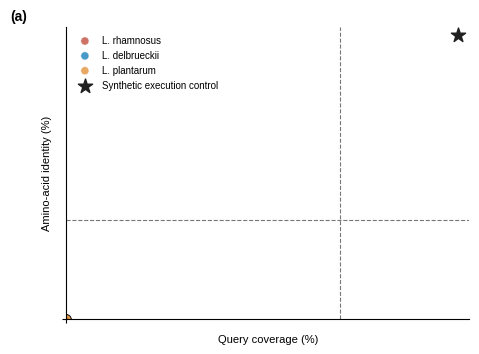

In [43]:
sod_hits = df[df["target"] == "SOD"].copy()
sod_hits.to_csv(cache("sod_tblastn_all93.csv"), index=False)

fig, ax = plt.subplots(figsize=(5.2, 3.8))
for species in TAG:
    selected = sod_hits[sod_hits["species"] == species]
    ax.scatter(
        selected["coverage"], selected["pident"],
        s=np.where(selected["is_focal"].astype(bool), 48, 21),
        color=SPECIES_COLOUR[species], alpha=0.72,
        edgecolor=np.where(
            selected["is_focal"].astype(bool), "black", "white"
        ),
        linewidth=0.5, label=species,
    )
ax.scatter(
    [float(sod_control_df["coverage"].iloc[0])],
    [float(sod_control_df["pident"].iloc[0])],
    marker="*", s=115, color="#202020",
    label="Synthetic execution control", zorder=5,
)
ax.axvline(70, color="#777777", linestyle="--", linewidth=0.8)
ax.axhline(35, color="#777777", linestyle="--", linewidth=0.8)
ax.set_xlabel("Query coverage (%)")
ax.set_ylabel("Amino-acid identity (%)")
ax.set_xlim(0, 103)
ax.set_ylim(0, 103)
ax.legend(frameon=False, fontsize=7)
clean_axes(ax)
panel_label(ax, "(a)")
export_figure(fig, "Supplementary_Figure_S5_SOD_validation")
plt.show()


### Supplementary Figure S6 — recommended module14 prevalence


saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S6_module14.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S6_module14.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S6_module14.png


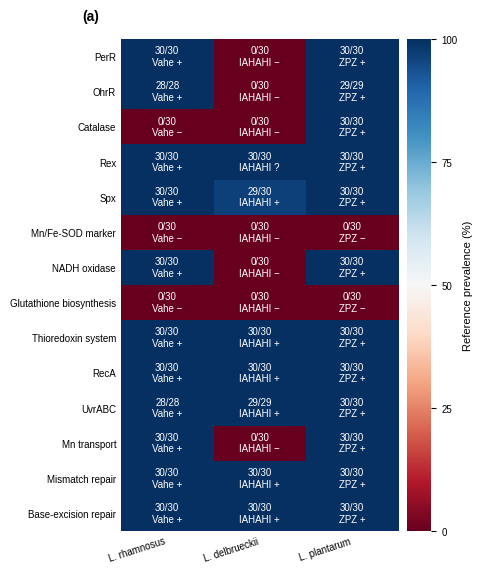

In [44]:
module_plot = pd.read_csv(cache("recommended_module14_summary.csv"))

module_order = list(MODULE14_RULES)
species_order = list(TAG)

module_matrix = np.full(
    (len(module_order), len(species_order)),
    np.nan,
)

module_labels = [
    ["" for _ in species_order]
    for _ in module_order
]

for row_index, target in enumerate(module_order):
    for column_index, species in enumerate(species_order):

        selected = module_plot[
            (module_plot["target"] == target)
            & (module_plot["species"] == species)
        ].iloc[0]

        module_matrix[row_index, column_index] = (
            selected["reference_prevalence_pct"]
        )

        focal_symbol = (
            "?"
            if pd.isna(selected["focal_present"])
            else ("+" if int(selected["focal_present"]) else "−")
        )

        module_labels[row_index][column_index] = (
            f'{int(selected["reference_present"])}/'
            f'{int(selected["reference_evaluated"])}\n'
            f'{selected["strain"]} {focal_symbol}'
        )


# =========================================================
# Plot
# =========================================================

fig, ax = plt.subplots(figsize=(5.9, 6.0))

# Red = low prevalence
# White = intermediate prevalence
# Blue = high prevalence
image = ax.imshow(
    module_matrix,
    cmap="RdBu",
    vmin=0,
    vmax=100,
    aspect="auto",
    interpolation="none",
)

# Add labels inside heatmap cells
for row_index in range(len(module_order)):
    for column_index in range(len(species_order)):

        value = module_matrix[row_index, column_index]

        # White text on dark red/blue backgrounds,
        # black text around the light midpoint
        if np.isfinite(value):
            text_colour = (
                "white"
                if value <= 25 or value >= 75
                else "black"
            )
        else:
            text_colour = "black"

        ax.text(
            column_index,
            row_index,
            module_labels[row_index][column_index],
            ha="center",
            va="center",
            fontsize=7,
            color=text_colour,
        )


# =========================================================
# Axes formatting
# =========================================================

ax.set_xticks(range(len(species_order)))
ax.set_xticklabels(
    species_order,
    rotation=18,
    ha="right",
)

ax.set_yticks(range(len(module_order)))
ax.set_yticklabels([TARGET_DISPLAY_LABELS.get(target, target.replace("_", " ")) for target in module_order])

ax.tick_params(
    axis="both",
    which="both",
    length=0,
)

# Remove outer borders
for spine in ax.spines.values():
    spine.set_visible(False)


# =========================================================
# Colour bar
# =========================================================

colourbar = fig.colorbar(
    image,
    ax=ax,
    pad=0.025,
)

colourbar.set_label("Reference prevalence (%)")

colourbar.set_ticks([0, 25, 50, 75, 100])
colourbar.outline.set_visible(False)


# =========================================================
# Panel label and layout
# =========================================================

panel_label(ax, "(a)")

fig.subplots_adjust(
    left=0.31,
    bottom=0.15,
    right=0.88,
    top=0.97,
)

export_figure(
    fig,
    "Supplementary_Figure_S6_module14",
)

plt.show()


### Supplementary Figure S7 — Cohort redundancy

Each square is one genome, grouped by the prespecified 99.5% ANI clustering.


saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S7_cohort_redundancy.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S7_cohort_redundancy.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S7_cohort_redundancy.png


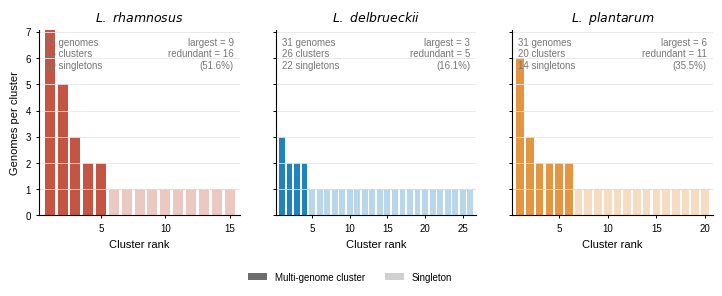

In [45]:
lin = table("derep_lineages.csv")

group_col = "lineage" if "lineage" in lin.columns else "cluster"

fig, axes = plt.subplots(
    1,
    3,
    figsize=(7.4, 2.9),
    sharey=True,
)

for panel_index, (ax, species) in enumerate(zip(axes, SPECIES)):

    part = lin.loc[
        lin["species"] == species
    ].copy()

    sizes = (
        part.groupby(group_col)
        .size()
        .sort_values(ascending=False)
    )

    cluster_count = len(sizes)
    genome_count = len(part)
    singleton_count = int((sizes == 1).sum())
    multi_cluster_count = int((sizes > 1).sum())
    largest_cluster = int(sizes.max()) if not sizes.empty else 0

    # Number of genomes removed if one representative
    # is retained from every cluster
    redundant_genomes = genome_count - cluster_count
    redundancy_pct = (
        100 * redundant_genomes / genome_count
        if genome_count > 0
        else np.nan
    )

    x = np.arange(1, cluster_count + 1)

    species_colour = PALETTE[species]

    # Multi-genome clusters
    multi_mask = sizes.values > 1

    ax.bar(
        x[multi_mask],
        sizes.values[multi_mask],
        width=0.78,
        color=species_colour,
        alpha=0.88,
        linewidth=0,
        label="Multi-genome cluster",
    )

    # Singletons
    ax.bar(
        x[~multi_mask],
        sizes.values[~multi_mask],
        width=0.78,
        color=species_colour,
        alpha=0.28,
        linewidth=0,
        label="Singleton",
    )

    # Singleton reference line
    ax.axhline(
        1,
        color="0.65",
        linewidth=0.8,
        linestyle="--",
        zorder=0,
    )

    ax.set_title(
        italic(species),
        fontsize=9,
        pad=6,
    )

    ax.text(
        0.03,
        0.96,
        (
            f"{genome_count} genomes\n"
            f"{cluster_count} clusters\n"
            f"{singleton_count} singletons"
        ),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=7,
        color=MUTED,
    )

    ax.text(
        0.97,
        0.96,
        (
            f"largest = {largest_cluster}\n"
            f"redundant = {redundant_genomes}\n"
            f"({redundancy_pct:.1f}%)"
        ),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=7,
        color=MUTED,
    )

    ax.set_xlabel(
        "Cluster rank",
        fontsize=8,
    )

    ax.set_xlim(
        0.2,
        cluster_count + 0.8,
    )

    ax.set_ylim(
        0,
        max(2, largest_cluster * 1.18),
    )

    ax.tick_params(
        axis="both",
        labelsize=7,
        length=2.5,
        width=0.7,
    )

    ax.grid(
        axis="y",
        color="0.90",
        linewidth=0.6,
        zorder=0,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if panel_index == 0:
        ax.set_ylabel(
            "Genomes per cluster",
            fontsize=8,
        )

# Shared legend
legend_handles = [
    Patch(
        facecolor="0.35",
        alpha=0.88,
        linewidth=0,
        label="Multi-genome cluster",
    ),
    Patch(
        facecolor="0.35",
        alpha=0.28,
        linewidth=0,
        label="Singleton",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=7,
    bbox_to_anchor=(0.5, -0.02),
)

fig.subplots_adjust(
    left=0.08,
    right=0.99,
    top=0.88,
    bottom=0.24,
    wspace=0.18,
)

save(
    fig,
    "Supplementary_Figure_S7_cohort_redundancy",
)

plt.show()

### Supplementary Figure S8 — Pangenome category transitions after 99.5% ANI sensitivity filtering

Alluvial ribbons show how full-cohort core, soft-core, shell, and cloud
families are classified after the prespecified single-linkage ANI sensitivity
analysis. This is supplementary architecture context, not a replacement for
the core-genome phylogeny.


,species,full_category,dereplicated_category,families,n_genomes_full,n_genomes_dereplicated
0,L. rhamnosus,Core,Core,2000,31,15
1,L. rhamnosus,Shell,Shell,1025,31,15
2,L. rhamnosus,Cloud,Cloud,951,31,15
3,L. rhamnosus,Shell,Cloud,146,31,15
4,L. rhamnosus,Soft-core,Shell,103,31,15
5,L. rhamnosus,Cloud,Not retained,85,31,15
6,L. rhamnosus,Cloud,Shell,65,31,15
7,L. rhamnosus,Soft-core,Core,32,31,15
8,L. rhamnosus,Shell,Not retained,31,31,15
9,L. rhamnosus,Shell,Core,2,31,15


saved: /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S8_pangenome_dereplication_sankey.pdf, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S8_pangenome_dereplication_sankey.svg, /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/figures/Supplementary_Figure_S8_pangenome_dereplication_sankey.png


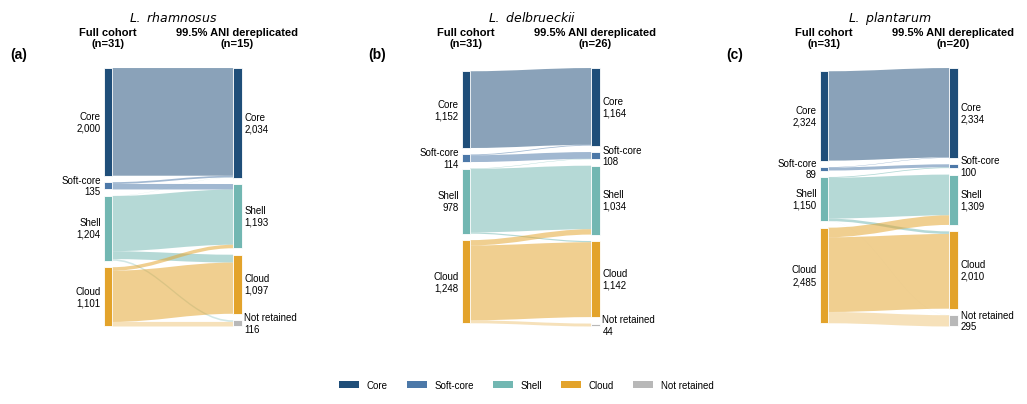

In [46]:
# ============================================================
# Supplementary Figure S8
# Pangenome-category transitions after 99.5% ANI dereplication
# ============================================================

from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch, Rectangle, Patch
import matplotlib.colors as mcolors

LEFT_ORDER = ["Core", "Soft-core", "Shell", "Cloud"]
RIGHT_ORDER = ["Core", "Soft-core", "Shell", "Cloud", "Not retained"]

CATEGORY_COLOUR = {
    "Core": "#1F4E79",
    "Soft-core": "#4C78A8",
    "Shell": "#72B7B2",
    "Cloud": "#E3A32B",
    "Not retained": "#B8B8B8",
}


def prevalence_category(frequency, n_genomes, include_not_retained=False):
    """Assign Panaroo families using the thresholds applied in the main analysis."""

    frequency = np.asarray(frequency)
    categories = np.full(len(frequency), "Cloud", dtype=object)

    categories[frequency >= 0.15 * n_genomes] = "Shell"
    categories[frequency >= 0.95 * n_genomes] = "Soft-core"
    categories[frequency >= 0.99 * n_genomes] = "Core"

    if include_not_retained:
        categories[frequency == 0] = "Not retained"

    return categories


def accession_matches(isolate_name, accession):
    isolate_name = str(isolate_name)
    accession = str(accession)

    return (
        isolate_name == accession
        or isolate_name.endswith(accession)
        or accession.endswith(isolate_name)
    )


# Load the ANI-cluster assignments saved by M8.1.
derep_lineages = pd.read_csv(cache("derep_lineages.csv"))

if "representative" not in derep_lineages.columns:
    raise RuntimeError(
        "derep_lineages.csv does not contain the 'representative' column."
    )


transition_tables = []
derep_sizes = {}

for species in TAG:
    isolates = list(PAN[species]["isolates"])
    matrix = np.asarray(PAN[species]["M"], dtype=np.uint8)
    n_full = int(PAN[species]["N"])

    selected_lineages = derep_lineages[
        derep_lineages["species"] == species
    ].copy()

    representatives = sorted(
        selected_lineages["representative"].dropna().astype(str).unique()
    )

    keep_indices = [
        index
        for index, isolate in enumerate(isolates)
        if any(
            accession_matches(isolate, representative)
            for representative in representatives
        )
    ]

    if len(keep_indices) != len(representatives):
        raise RuntimeError(
            f"{species}: matched {len(keep_indices)} Panaroo columns "
            f"for {len(representatives)} ANI representatives."
        )

    if len(keep_indices) < 3:
        raise RuntimeError(
            f"{species}: only {len(keep_indices)} dereplicated genomes."
        )

    derep_sizes[species] = len(keep_indices)

    full_frequency = matrix.sum(axis=1)
    derep_frequency = matrix[:, keep_indices].sum(axis=1)

    full_category = prevalence_category(
        full_frequency,
        n_full,
        include_not_retained=False,
    )

    derep_category = prevalence_category(
        derep_frequency,
        len(keep_indices),
        include_not_retained=True,
    )

    species_transitions = (
        pd.DataFrame(
            {
                "full_category": full_category,
                "dereplicated_category": derep_category,
            }
        )
        .value_counts()
        .rename("families")
        .reset_index()
    )

    species_transitions.insert(0, "species", species)
    species_transitions["n_genomes_full"] = n_full
    species_transitions["n_genomes_dereplicated"] = len(keep_indices)

    transition_tables.append(species_transitions)


pangenome_transitions = pd.concat(
    transition_tables,
    ignore_index=True,
)

pangenome_transitions.to_csv(
    cache("pangenome_dereplication_transitions.csv"),
    index=False,
)

display(pangenome_transitions)


def node_spans(totals, order, scale, gap):
    """Calculate vertically centred node positions."""

    active_order = [
        category for category in order
        if totals.get(category, 0) > 0
    ]

    total_height = (
        sum(totals[category] * scale for category in active_order)
        + gap * max(0, len(active_order) - 1)
    )

    cursor = (1.0 + total_height) / 2.0
    spans = {}

    for category in active_order:
        height = totals[category] * scale
        top = cursor
        bottom = top - height
        spans[category] = (bottom, top)
        cursor = bottom - gap

    return spans, active_order


def ribbon_path(x0, y0_bottom, y0_top, x1, y1_bottom, y1_top):
    """Create a smooth alluvial ribbon."""

    curve = 0.38 * (x1 - x0)

    vertices = [
        (x0, y0_bottom),
        (x0 + curve, y0_bottom),
        (x1 - curve, y1_bottom),
        (x1, y1_bottom),

        (x1, y1_top),

        (x1 - curve, y1_top),
        (x0 + curve, y0_top),
        (x0, y0_top),

        (x0, y0_bottom),
    ]

    codes = [
        MplPath.MOVETO,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CURVE4,

        MplPath.LINETO,

        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CURVE4,

        MplPath.CLOSEPOLY,
    ]

    return MplPath(vertices, codes)


def draw_pangenome_alluvial(ax, transition_df, species, panel):
    counts = {
        (row.full_category, row.dereplicated_category): int(row.families)
        for row in transition_df.itertuples(index=False)
    }

    left_totals = {
        category: sum(
            value
            for (left, right), value in counts.items()
            if left == category
        )
        for category in LEFT_ORDER
    }

    right_totals = {
        category: sum(
            value
            for (left, right), value in counts.items()
            if right == category
        )
        for category in RIGHT_ORDER
    }

    total_families = sum(left_totals.values())

    active_left = [
        category for category in LEFT_ORDER
        if left_totals[category] > 0
    ]

    active_right = [
        category for category in RIGHT_ORDER
        if right_totals[category] > 0
    ]

    gap = 0.025

    available_left = (
        1.0 - gap * max(0, len(active_left) - 1)
    ) / total_families

    available_right = (
        1.0 - gap * max(0, len(active_right) - 1)
    ) / total_families

    scale = min(available_left, available_right)

    left_spans, active_left = node_spans(
        left_totals, LEFT_ORDER, scale, gap
    )

    right_spans, active_right = node_spans(
        right_totals, RIGHT_ORDER, scale, gap
    )

    x_left = 0.05
    x_right = 0.88
    node_width = 0.055

    # Determine ribbon positions independently at both ends.
    left_positions = {}

    for left_category in active_left:
        cursor = left_spans[left_category][0]

        # Bottom-to-top order follows the right-side node positions.
        for right_category in reversed(active_right):
            value = counts.get((left_category, right_category), 0)

            if value <= 0:
                continue

            thickness = value * scale
            left_positions[(left_category, right_category)] = (
                cursor,
                cursor + thickness,
            )
            cursor += thickness

    right_positions = {}

    for right_category in active_right:
        cursor = right_spans[right_category][0]

        # Bottom-to-top order follows the left-side node positions.
        for left_category in reversed(active_left):
            value = counts.get((left_category, right_category), 0)

            if value <= 0:
                continue

            thickness = value * scale
            right_positions[(left_category, right_category)] = (
                cursor,
                cursor + thickness,
            )
            cursor += thickness

    # Ribbons.
    for left_category in LEFT_ORDER:
        for right_category in RIGHT_ORDER:
            value = counts.get((left_category, right_category), 0)

            if value <= 0:
                continue

            y0_bottom, y0_top = left_positions[
                (left_category, right_category)
            ]

            y1_bottom, y1_top = right_positions[
                (left_category, right_category)
            ]

            path = ribbon_path(
                x_left + node_width,
                y0_bottom,
                y0_top,
                x_right,
                y1_bottom,
                y1_top,
            )

            colour = CATEGORY_COLOUR[left_category]
            alpha = 0.52

            if right_category == "Not retained":
                alpha = 0.32

            ax.add_patch(
                PathPatch(
                    path,
                    facecolor=mcolors.to_rgba(colour, alpha),
                    edgecolor="none",
                    zorder=1,
                )
            )

    # Left nodes and labels.
    for category in active_left:
        bottom, top = left_spans[category]
        count = left_totals[category]

        ax.add_patch(
            Rectangle(
                (x_left, bottom),
                node_width,
                top - bottom,
                facecolor=CATEGORY_COLOUR[category],
                edgecolor="white",
                linewidth=0.6,
                zorder=3,
            )
        )

        ax.text(
            x_left - 0.018,
            (bottom + top) / 2,
            f"{category}\n{count:,}",
            ha="right",
            va="center",
            fontsize=7,
        )

    # Right nodes and labels.
    for category in active_right:
        bottom, top = right_spans[category]
        count = right_totals[category]

        ax.add_patch(
            Rectangle(
                (x_right, bottom),
                node_width,
                top - bottom,
                facecolor=CATEGORY_COLOUR[category],
                edgecolor="white",
                linewidth=0.6,
                zorder=3,
            )
        )

        ax.text(
            x_right + node_width + 0.018,
            (bottom + top) / 2,
            f"{category}\n{count:,}",
            ha="left",
            va="center",
            fontsize=7,
        )

    ax.text(
        x_left + node_width / 2,
        1.075,
        "Full cohort\n(n=31)",
        ha="center",
        va="bottom",
        fontsize=8,
        weight="bold",
    )

    ax.text(
        x_right + node_width / 2,
        1.075,
        f"99.5% ANI dereplicated\n(n={derep_sizes[species]})",
        ha="center",
        va="bottom",
        fontsize=8,
        weight="bold",
    )

    ax.set_title(italic(species), fontsize=9, pad=30)
    ax.set_xlim(-0.32, 1.32)
    ax.set_ylim(-0.02, 1.02)
    ax.axis("off")
    panel_label(ax, panel)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(10.8, 4.2),
)

for panel, axis, species in zip(
    ("(a)", "(b)", "(c)"),
    axes,
    TAG,
):
    selected = pangenome_transitions[
        pangenome_transitions["species"] == species
    ]

    draw_pangenome_alluvial(
        axis,
        selected,
        species,
        panel,
    )


legend_handles = [
    Patch(
        facecolor=CATEGORY_COLOUR[category],
        edgecolor="none",
        label=category,
    )
    for category in RIGHT_ORDER
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01),
)

fig.subplots_adjust(
    left=0.055,
    right=0.955,
    top=0.81,
    bottom=0.17,
    wspace=0.40,
)

export_figure(
    fig,
    "Supplementary_Figure_S8_pangenome_dereplication_sankey",
)

plt.show()


## M8.6 — Dereplicated dN/dS sensitivity and cohort subspecies composition → Tables S18–S22

Two robustness analyses requested during review.

The first repeats the curated dN/dS analysis on one representative per
99.5% ANI cluster, chosen by a prespecified quality ranking (CheckM2
completeness descending, contamination ascending, N50 descending, contig
count ascending, accession as final tie-breaker), and re-runs the paired
Wilcoxon tests on the dereplicated estimates. This tests whether the
species difference in omega is an artefact of unequal sampling density.

The second describes the composition of the *L. delbrueckii* cohort by
nearest fixed subspecies reference. Both are descriptive robustness
analyses and neither replaces the primary result.


In [47]:
from pathlib import Path
import hashlib, itertools, os, zlib
import numpy as np
import pandas as pd
from scipy import stats as sps

FORCE_DEREP_DNDS = False
RUN_SUBSPECIES_COMPOSITION = True
FORCE_SUBSPECIES_COMPOSITION = False
SENSITIVITY_BOOTSTRAPS = 2000
SENSITIVITY_VERSION = DND_METHOD_VERSION + "__ANI995_QCrep_v1"

def _atomic_csv(frame, path):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(tmp, index=False)
    os.replace(tmp, path)

def _match_accession(name, accession):
    name, accession = str(name), str(accession)
    return name == accession or name.endswith(accession) or accession.endswith(name)

def _sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

# ---------------------------------------------------------------------
# A. dN/dS using one QC-ranked representative per 99.5%-ANI cluster
# ---------------------------------------------------------------------
lineages = pd.read_csv(cache("derep_lineages.csv"))
curated = pd.read_csv(cache("dnds_curated_high_confidence.csv"))

required_lineage = {"species", "cluster", "accession", "representative"}
required_curated = {"species", "canonical_symbol", "gene_family", "omega"}
if not required_lineage.issubset(lineages.columns):
    raise RuntimeError("derep_lineages.csv is incomplete")
if not required_curated.issubset(curated.columns):
    raise RuntimeError("dnds_curated_high_confidence.csv is incomplete")
if set(lineages.accession.astype(str)) != {str(a) for _, a, _ in ALLDIRS}:
    raise RuntimeError("ANI clusters do not match the current 93-genome cohort")

rep_table = (
    lineages[["species", "cluster", "representative"]]
    .drop_duplicates()
    .sort_values(["species", "cluster", "representative"])
)
rep_hash = {
    species: hashlib.sha256(
        rep_table[rep_table.species == species].to_csv(index=False).encode()
    ).hexdigest()
    for species in TAG
}

print("99.5%-ANI representatives:")
print(rep_table.groupby("species").representative.nunique().to_string())

out_path = Path(cache("dnds_dereplicated_sensitivity.csv"))
columns = [
    "species", "canonical_symbol", "gene_family", "n_clusters",
    "n_sequences", "omega_full", "omega_derep", "omega_delta",
    "boot_median", "ci_lo", "ci_hi", "n_pairs", "n_dS0", "n_valid",
    "valid_pair_fraction", "representatives_with_sequence",
    "species_input_sha256", "representative_set_sha256", "method_version",
]
records = []
if out_path.exists() and not FORCE_DEREP_DNDS:
    old = pd.read_csv(out_path)
    if set(columns).issubset(old.columns):
        old = old[
            old.method_version.eq(SENSITIVITY_VERSION)
            & old.apply(
                lambda r: (
                    str(r.species_input_sha256)
                    == str(SPECIES_INPUT_SHA256.get(str(r.species), ""))
                    and str(r.representative_set_sha256)
                    == rep_hash.get(str(r.species), "")
                ), axis=1,
            )
        ]
        records = old[columns].to_dict("records")
        print(f"Reusing {len(records)} validated checkpoints")

completed = {(r["species"], r["gene_family"]) for r in records}

for species, tag in TAG.items():
    representatives = sorted(
        rep_table.loc[rep_table.species == species, "representative"]
        .astype(str).unique()
    )
    families = family_map(tag)
    gene_data = load_gene_data(tag)
    selected_rows = curated[curated.species == species]
    print(f"\n{species}: {len(representatives)} representatives")

    for _, row in selected_rows.iterrows():
        family_name = str(row.gene_family)
        symbol = str(row.canonical_symbol)
        if (species, family_name) in completed:
            print(f"  cached {symbol}")
            continue

        family = families.get(family_name)
        if family is None:
            raise RuntimeError(f"{species} {family_name}: family missing")

        isolates = list(family["isolates"])
        ids_by_isolate = family["identifiers_by_isolate"]
        sequences, used_representatives = [], []

        for representative in representatives:
            matches = [
                i for i, isolate in enumerate(isolates)
                if _match_accession(isolate, representative)
            ]
            if len(matches) != 1:
                raise RuntimeError(
                    f"{species} {family_name} {representative}: "
                    f"matched {len(matches)} Panaroo columns"
                )
            identifiers = ids_by_isolate[matches[0]]
            if len(identifiers) > 1:
                raise RuntimeError(
                    f"{species} {family_name} {representative}: multicopy"
                )
            if len(identifiers) == 1:
                sequence = gene_data.get(identifiers[0])
                if sequence is not None and len(sequence) >= 90:
                    sequences.append(sequence)
                    used_representatives.append(representative)

        if len(sequences) < 4:
            raise RuntimeError(
                f"{species} {family_name}: only {len(sequences)} sequences"
            )

        codon_alignment = mafft_codon(sequences)
        if len(codon_alignment) != len(sequences):
            raise RuntimeError(
                f"{species} {family_name}: alignment lost sequences"
            )

        omega, n_pairs, n_ds0, n_valid, dn_matrix, ds_matrix = (
            precompute_pairwise_ng86(codon_alignment)
        )
        if not np.isfinite(omega):
            raise RuntimeError(f"{species} {family_name}: omega is not finite")

        seed = int(RANDOM_SEED) + zlib.crc32(
            f"derep|{species}|{family_name}".encode()
        )
        boot_median, ci_lo, ci_hi = bootstrap_from_pairwise(
            dn_matrix, ds_matrix,
            n_bootstraps=SENSITIVITY_BOOTSTRAPS,
            seed=seed,
        )
        possible_pairs = len(codon_alignment) * (len(codon_alignment) - 1) // 2

        records.append({
            "species": species,
            "canonical_symbol": symbol,
            "gene_family": family_name,
            "n_clusters": len(representatives),
            "n_sequences": len(codon_alignment),
            "omega_full": float(row.omega),
            "omega_derep": float(omega),
            "omega_delta": float(omega) - float(row.omega),
            "boot_median": float(boot_median),
            "ci_lo": float(ci_lo),
            "ci_hi": float(ci_hi),
            "n_pairs": int(n_pairs),
            "n_dS0": int(n_ds0),
            "n_valid": int(n_valid),
            "valid_pair_fraction": n_valid / possible_pairs,
            "representatives_with_sequence": ";".join(used_representatives),
            "species_input_sha256": SPECIES_INPUT_SHA256[species],
            "representative_set_sha256": rep_hash[species],
            "method_version": SENSITIVITY_VERSION,
        })
        completed.add((species, family_name))
        _atomic_csv(pd.DataFrame(records, columns=columns), out_path)
        print(
            f"  {symbol}: full={float(row.omega):.4f}; "
            f"derep={omega:.4f}; checkpoint saved",
            flush=True,
        )

sens = pd.DataFrame(records, columns=columns).sort_values(
    ["canonical_symbol", "species"]
).reset_index(drop=True)
_atomic_csv(sens, out_path)

expected_rows = len(TAG) * curated.canonical_symbol.nunique()
if len(sens) != expected_rows:
    raise RuntimeError(
        f"Sensitivity table incomplete: {len(sens)}/{expected_rows} rows"
    )

summary = (
    sens.groupby("species")
    .agg(
        n_genes=("canonical_symbol", "nunique"),
        n_clusters=("n_clusters", "max"),
        median_omega_full=("omega_full", "median"),
        median_omega_derep=("omega_derep", "median"),
        median_abs_delta=("omega_delta", lambda x: np.median(np.abs(x))),
        maximum_abs_delta=("omega_delta", lambda x: np.max(np.abs(x))),
    )
    .reset_index()
)
summary.to_csv(cache("dnds_dereplicated_species_summary.csv"), index=False)

# Same paired Wilcoxon tests and Holm correction as in the primary analysis.
wide = sens.pivot(index="canonical_symbol", columns="species", values="omega_derep")
test_rows = []
for a, b in itertools.combinations(sorted(wide.columns), 2):
    paired = wide[[a, b]].dropna()
    statistic, p_value = sps.wilcoxon(paired[a], paired[b])
    difference = paired[a] - paired[b]
    test_rows.append({
        "species_a": a, "species_b": b,
        "n_genes": len(paired),
        "median_a": paired[a].median(),
        "median_b": paired[b].median(),
        "a_higher": int((difference > 0).sum()),
        "b_higher": int((difference < 0).sum()),
        "equal": int((difference == 0).sum()),
        "wilcoxon_W": float(statistic),
        "p_value": float(p_value),
    })

tests = pd.DataFrame(test_rows)
order = np.argsort(tests.p_value.to_numpy())
holm = np.empty(len(tests))
running = 0.0
for rank, index in enumerate(order):
    running = max(
        running,
        min(1.0, (len(tests) - rank) * tests.iloc[index].p_value),
    )
    holm[index] = running
tests["p_value_holm"] = holm
tests["significant_holm_005"] = tests.p_value_holm < 0.05
tests.to_csv(cache("stats_omega_dereplicated_paired_tests.csv"), index=False)

audit_rows = []
for other in [s for s in TAG if s != "L. delbrueckii"]:
    paired = wide[["L. delbrueckii", other]].dropna()
    test = tests[
        ((tests.species_a == "L. delbrueckii") & (tests.species_b == other))
        | ((tests.species_b == "L. delbrueckii") & (tests.species_a == other))
    ].iloc[0]
    n_higher = int((paired["L. delbrueckii"] > paired[other]).sum())
    audit_rows.append({
        "comparison": f"L. delbrueckii vs {other}",
        "n_genes": len(paired),
        "n_delbrueckii_higher": n_higher,
        "all_genes_same_direction": n_higher == len(paired),
        "holm_p": float(test.p_value_holm),
        "significant_holm_005": bool(test.significant_holm_005),
    })
audit = pd.DataFrame(audit_rows)
audit["strong_robustness_support"] = (
    audit.all_genes_same_direction & audit.significant_holm_005
)
audit.to_csv(cache("dnds_dereplicated_robustness_audit.csv"), index=False)

print("\nDereplicated dN/dS summary:")
display(summary)
print("Paired tests after dereplication:")
display(tests)
print("Central-result audit:")
display(audit)
print(
    "RESULT:",
    "STRONG redundancy-robustness support"
    if audit.strong_robustness_support.all()
    else "strict robustness criterion NOT fully met; inspect the tables",
)

# ---------------------------------------------------------------------
# B. L. delbrueckii cohort composition by nearest of three fixed refs
#    This is descriptive, not a universal formal subspecies assignment.
# ---------------------------------------------------------------------
if RUN_SUBSPECIES_COMPOSITION:
    for name in ["TYPE_STRAINS", "fixed_reference_fna", "run_fastani", "genome_fasta"]:
        if name not in globals():
            raise RuntimeError(f"Missing notebook object required for subspecies analysis: {name}")

    ani_path = Path(cache("L_delbrueckii_subspecies_composition.csv"))
    references = {
        label: (accession, Path(fixed_reference_fna(accession)))
        for label, accession in TYPE_STRAINS.items()
    }
    ldel = [
        (str(accession), Path(genome_fasta(directory)))
        for species, accession, directory in ALLDIRS
        if species == "L. delbrueckii"
    ]
    if len(ldel) != 31:
        raise RuntimeError(f"Expected 31 L. delbrueckii genomes, found {len(ldel)}")
    query_paths = dict(ldel)
    reference_paths = {
        accession: path for _, (accession, path) in references.items()
    }
    query_hashes = {accession: _sha256_file(path) for accession, path in ldel}
    reference_hashes = {
        accession: _sha256_file(path) for accession, path in reference_paths.items()
    }
    previous = pd.DataFrame()
    if ani_path.exists() and not FORCE_SUBSPECIES_COMPOSITION:
        previous = pd.read_csv(ani_path)

    ani_records = []
    for _, old in previous.iterrows():
        query_accession = str(old.get("query_accession", ""))
        reference_accession = str(old.get("reference_accession", ""))
        if (
            old.get("method_version") == "nearest_three_fixed_refs_v1"
            and query_accession in query_paths
            and reference_accession in reference_paths
            and str(old.get("query_fna_sha256", ""))
            == query_hashes[query_accession]
            and str(old.get("reference_fna_sha256", ""))
            == reference_hashes[reference_accession]
            and pd.notna(old.get("ANI"))
        ):
            ani_records.append(old.to_dict())
    completed_ani = {
        (str(r["query_accession"]), str(r["reference_accession"]))
        for r in ani_records
    }

    for number, (query_accession, query_fna) in enumerate(ldel, 1):
        for label, (reference_accession, reference_fna) in references.items():
            key = (query_accession, reference_accession)
            if key in completed_ani:
                continue
            ani, matched, total = run_fastani(query_fna, reference_fna)
            ani_records.append({
                "species": "L. delbrueckii",
                "query_accession": query_accession,
                "reference_group": label,
                "reference_accession": reference_accession,
                "ANI": ani,
                "matched_fragments": matched,
                "total_fragments": total,
                "query_fna_sha256": query_hashes[query_accession],
                "reference_fna_sha256": reference_hashes[reference_accession],
                "method_version": "nearest_three_fixed_refs_v1",
            })
            completed_ani.add(key)
            _atomic_csv(pd.DataFrame(ani_records), ani_path)
        print(f"  subspecies references {number}/31: {query_accession}", flush=True)

    ani_long = pd.DataFrame(ani_records)
    if len(ani_long) != 93:
        raise RuntimeError(f"Expected 93 subspecies-reference comparisons, found {len(ani_long)}")

    nearest = []
    for accession, group in ani_long.groupby("query_accession"):
        ranked = group.sort_values("ANI", ascending=False).reset_index(drop=True)
        best, second = ranked.iloc[0], ranked.iloc[1]
        nearest.append({
            "species": "L. delbrueckii",
            "accession": accession,
            "nearest_fixed_reference_group": best.reference_group,
            "nearest_fixed_reference_accession": best.reference_accession,
            "best_ANI": float(best.ANI),
            "second_fixed_reference_group": second.reference_group,
            "second_ANI": float(second.ANI),
            "ANI_margin_pp": float(best.ANI - second.ANI),
            "interpretation": (
                "nearest of three fixed references; descriptive, "
                "not a universal formal subspecies threshold"
            ),
        })

    nearest = pd.DataFrame(nearest).merge(
        lineages[lineages.species == "L. delbrueckii"]
        [["accession", "cluster", "representative"]].drop_duplicates(),
        on="accession", how="left",
    )
    nearest["is_ANI_cluster_representative"] = (
        nearest.accession.astype(str) == nearest.representative.astype(str)
    )
    nearest.to_csv(cache("L_delbrueckii_nearest_subspecies_reference.csv"), index=False)

    composition = (
        nearest.groupby("nearest_fixed_reference_group")
        .agg(
            n_genomes=("accession", "nunique"),
            n_ANI_clusters=("cluster", "nunique"),
            median_best_ANI=("best_ANI", "median"),
            minimum_margin_pp=("ANI_margin_pp", "min"),
            median_margin_pp=("ANI_margin_pp", "median"),
        )
        .reset_index()
        .sort_values("n_genomes", ascending=False)
    )
    composition.to_csv(
        cache("L_delbrueckii_subspecies_composition_summary.csv"), index=False
    )
    print("\nL. delbrueckii nearest-reference composition:")
    display(composition)
    print("Nearest-reference labels are descriptive, not formal subspecies assignments.")

print("\nSaved:")
for filename in [
    "dnds_dereplicated_sensitivity.csv",
    "dnds_dereplicated_species_summary.csv",
    "stats_omega_dereplicated_paired_tests.csv",
    "dnds_dereplicated_robustness_audit.csv",
    "L_delbrueckii_nearest_subspecies_reference.csv",
    "L_delbrueckii_subspecies_composition_summary.csv",
]:
    path = Path(cache(filename))
    print(f"  {'OK' if path.exists() else 'MISS'}  {path}")

99.5%-ANI representatives:
species
L. delbrueckii    26
L. plantarum      20
L. rhamnosus      15
Reusing 30 validated checkpoints

L. rhamnosus: 15 representatives
  cached liga
  cached muts
  cached recn
  cached reco
  cached recr
  cached ruva
  cached ruvb
  cached ssb
  cached uvra
  cached uvrb

L. delbrueckii: 26 representatives
  cached liga
  cached muts
  cached recn
  cached reco
  cached recr
  cached ruva
  cached ruvb
  cached ssb
  cached uvra
  cached uvrb

L. plantarum: 20 representatives
  cached liga
  cached muts
  cached recn
  cached reco
  cached recr
  cached ruva
  cached ruvb
  cached ssb
  cached uvra
  cached uvrb

Dereplicated dN/dS summary:


,species,n_genes,n_clusters,median_omega_full,median_omega_derep,median_abs_delta,maximum_abs_delta
0,L. delbrueckii,10,26,0.12835,0.130056,0.004741,0.008870
1,L. plantarum,10,20,0.03110,0.035176,0.002666,0.024855
2,L. rhamnosus,10,15,0.02175,0.015672,0.001746,0.026741


Paired tests after dereplication:


,species_a,species_b,n_genes,median_a,median_b,a_higher,b_higher,equal,wilcoxon_W,p_value,p_value_holm,significant_holm_005
0,L. delbrueckii,L. plantarum,10,0.130056,0.035176,10,0,0,0.0,0.001953,0.005859,True
1,L. delbrueckii,L. rhamnosus,10,0.130056,0.015672,10,0,0,0.0,0.001953,0.005859,True
2,L. plantarum,L. rhamnosus,10,0.035176,0.015672,6,4,0,15.0,0.232422,0.232422,False


Central-result audit:


,comparison,n_genes,n_delbrueckii_higher,all_genes_same_direction,holm_p,significant_holm_005,strong_robustness_support
0,L. delbrueckii vs L. rhamnosus,10,10,True,0.005859,True,True
1,L. delbrueckii vs L. plantarum,10,10,True,0.005859,True,True


RESULT: STRONG redundancy-robustness support
  subspecies references 1/31: GCF_000056065.1
  subspecies references 2/31: GCF_002847905.1
  subspecies references 3/31: GCF_003545935.1
  subspecies references 4/31: GCF_004211505.1
  subspecies references 5/31: GCF_004211735.1
  subspecies references 6/31: GCF_009362855.1
  subspecies references 7/31: GCF_009734125.1
  subspecies references 8/31: GCF_014830125.1
  subspecies references 9/31: GCF_015377785.1
  subspecies references 10/31: GCF_019583415.1
  subspecies references 11/31: GCF_021600185.1
  subspecies references 12/31: GCF_021600205.1
  subspecies references 13/31: GCF_021600245.1
  subspecies references 14/31: GCF_021600265.1
  subspecies references 15/31: GCF_021600345.1
  subspecies references 16/31: GCF_021600365.1
  subspecies references 17/31: GCF_021600385.1
  subspecies references 18/31: GCF_021600405.1
  subspecies references 19/31: GCF_021600425.1
  subspecies references 20/31: GCF_021600445.1
  subspecies references 

,nearest_fixed_reference_group,n_genomes,n_ANI_clusters,median_best_ANI,minimum_margin_pp,median_margin_pp
2,subsp. lactis (DSM 20072 lineage),18,15,97.9303,0.0083,0.18855
0,"subsp. bulgaricus (ATCC 11842, type)",7,6,98.9455,0.0623,1.98200
1,subsp. delbrueckii (DSM 20074 lineage),6,6,97.6962,0.0034,0.30610


Nearest-reference labels are descriptive, not formal subspecies assignments.

Saved:
  OK  /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/dnds_dereplicated_sensitivity.csv
  OK  /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/dnds_dereplicated_species_summary.csv
  OK  /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/stats_omega_dereplicated_paired_tests.csv
  OK  /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/dnds_dereplicated_robustness_audit.csv
  OK  /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/L_delbrueckii_nearest_subspecies_reference.csv
  OK  /home/jovyan/bacterial_genome_article/paper1_results/paper1_publication_final/L_delbrueckii_subspecies_composition_summary.csv


## M8.7 — Supplementary table index

In [48]:
index = [
    ("S1",  "input_manifest_all93.csv",                   "Input manifest and assembly metrics, 93 genomes"),
    ("S2",  "QC_all93.csv",                               "Assembly QC and uniform CheckM2 metrics"),
    ("S3",  "analysis_cohort_qc.csv",                     "Prespecified cohort decisions and sensitivity flags"),
    ("S4",  "hgt_candidates.csv",                         "GC-compositional outliers among focal-unique genes"),
    ("S5",  "curated_regulator_query_manifest.csv",       "Curated query proteins, sources, accessions, thresholds"),
    ("S6",  "panel_definition.csv",                       "Operational panel definitions and component logic"),
    ("S7",  "regulator_resolution_all93.csv",             "Competitive regulator orthology assignment"),
    ("S8",  "derep_gamma.csv",                            "99.5% ANI single-linkage sensitivity and refitted openness"),
    ("S9",  "stats_focal_vs_conspecific_descriptive.csv", "Descriptive focal/background panel comparison"),
    ("S10", "stats_omega_paired_tests.csv",               "Paired Wilcoxon tests of omega with Holm correction"),
    ("S11", "stats_rex_contig_position.csv",              "IAHAHI Rex loci relative to contig ends"),
    ("S12", "stats_rex_split_locus_hits.csv",             "Fragment-level reviewed-Rex BLASTP hits in IAHAHI"),
    ("S13", "stats_rex_split_locus_pairs.csv",            "Adjacent complementary IAHAHI Rex hit pairs and frames"),
    ("S14", "stats_pseudogene_control_rawCDS.csv",        "ORF-integrity screen of Prokka CDS bearing curated symbols"),
    ("S15", "dnds_dS_diagnostics.csv",                    "Pairwise dS diagnostics for the curated DNA-repair families"),
    ("S16", "stats_omega_dS_spearman.csv",                "Descriptive omega versus mean-dS sensitivity diagnostic"),
    ("S17", "dnds_oxidative_species_specific.csv",         "Within-species oxidative-defence dN/dS estimates and NE combinations"),
    ("S18", "dnds_dereplicated_sensitivity.csv",           "Per-gene dN/dS on 99.5% ANI representatives with change versus the full cohort"),
    ("S19", "stats_omega_dereplicated_paired_tests.csv",   "Paired Wilcoxon tests of omega after dereplication"),
    ("S20", "dnds_dereplicated_robustness_audit.csv",      "Robustness audit of the central selection result"),
    ("S21", "L_delbrueckii_nearest_subspecies_reference.csv", "Nearest fixed subspecies reference for all 31 L. delbrueckii genomes"),
    ("S22", "L_delbrueckii_subspecies_composition_summary.csv", "Subspecies composition of the L. delbrueckii cohort"),
]
rows = []
for number, filename, description in index:
    exists = os.path.exists(cache(filename))
    rows.append({
        "table": number,
        "file": filename,
        "description": description,
        "present": exists,
    })
    print(f"  {'OK  ' if exists else 'MISS'} {number:4} {filename}")
idx = pd.DataFrame(rows)
idx.to_csv(cache("SUPPLEMENTARY_TABLES_INDEX.csv"), index=False)

if len(summary_rows):
    pd.DataFrame(summary_rows).to_csv(cache("stats_summary.csv"), index=False)

missing = idx.loc[~idx["present"], "table"].tolist()
print(f"\nwrote {cache('SUPPLEMENTARY_TABLES_INDEX.csv')}")
if missing:
    warnings.warn(
        "Supplementary table generation is incomplete: " + ", ".join(missing)
        + ". Continuing so the final publication audit reports every check."
    )
else:
    print("All supplementary tables S1-S22 are present.")


  OK   S1   input_manifest_all93.csv
  OK   S2   QC_all93.csv
  OK   S3   analysis_cohort_qc.csv
  OK   S4   hgt_candidates.csv
  OK   S5   curated_regulator_query_manifest.csv
  OK   S6   panel_definition.csv
  OK   S7   regulator_resolution_all93.csv
  OK   S8   derep_gamma.csv
  OK   S9   stats_focal_vs_conspecific_descriptive.csv
  OK   S10  stats_omega_paired_tests.csv
  OK   S11  stats_rex_contig_position.csv
  OK   S12  stats_rex_split_locus_hits.csv
  OK   S13  stats_rex_split_locus_pairs.csv
  OK   S14  stats_pseudogene_control_rawCDS.csv
  OK   S15  dnds_dS_diagnostics.csv
  OK   S16  stats_omega_dS_spearman.csv
  OK   S17  dnds_oxidative_species_specific.csv
  OK   S18  dnds_dereplicated_sensitivity.csv
  OK   S19  stats_omega_dereplicated_paired_tests.csv
  OK   S20  dnds_dereplicated_robustness_audit.csv
  OK   S21  L_delbrueckii_nearest_subspecies_reference.csv
  OK   S22  L_delbrueckii_subspecies_composition_summary.csv

wrote /home/jovyan/bacterial_genome_article/paper1